In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

# import tqdm
from tqdm import tqdm
import pickle


## Read in each data file

## Plot verification of the K(phi) solutions

## Extracting vertex data

## Turn into ML-ready datasets

### Block parameters are listed as:
- height factor
- thickness
- radius
- W/r
- crack number
- ndom
- a/c
- a/t
- r/t
- b/t
- c

In [2]:
# Define full ML dataset indices for easier readability and slicing
height_factor_idx = 0  # Remove, variance=0
thickness_idx = 1
radius_idx = 2  # Remove, variance=0
w_over_r_idx = 3
crack_number_idx = 4
ndom_idx = 5
a_over_c_idx = 6
a_over_t_idx = 7
R_over_t_idx = 8
b_over_t_idx = 9  # Remove, variance=0
c_idx = 10
Ktension_c_idx = 11
Kbending_c_idx = 12
Kbearing_c_idx = 13
Ktension_a_idx = 14
Kbending_a_idx = 15
Kbearing_a_idx = 16
index_feature_name_map = ["height_factor", "thickness", "radius", "w_over_r", "crack_number",
                          "ndom", "a_over_c", "a_over_t", "r_over_t", "b_over_t", "c",
                          "Ktension_c", "Kbending_c", "Kbearing_c", "Ktension_a", "Kbending_a",
                          "Kbearing_a", "index"]

(92149, 17)
(92149, 18)
Unique a/c values: [ 0.1         0.111       0.125       0.1428      0.16670001  0.2
  0.25        0.333       0.5         0.667       0.75        0.80000001
  1.          1.25        1.33299994  1.5         2.          3.
  4.          5.          6.          7.          8.          9.
 10.        ]
Unique a/t values: [0.1        0.2        0.30000001 0.40000001 0.5        0.60000002
 0.69999999 0.80000001 0.89999998 0.94999999]
Unique R/t values: [ 0.1         0.125       0.1428      0.16670001  0.2         0.25
  0.333       0.40000001  0.44440001  0.5         0.57139999  0.667
  0.80000001  1.          1.25        1.5         1.75        2.
  2.25        2.5         3.          4.          5.          6.
  7.          8.         10.        ]
Data filtered for fixed parameters excluding w_over_r: (12, 18)
Unique w_over_r values in filtered data: [  3.20000005   3.5999999    4.           4.5999999    5.19999981
   5.80000019   6.4000001    7.          10.     

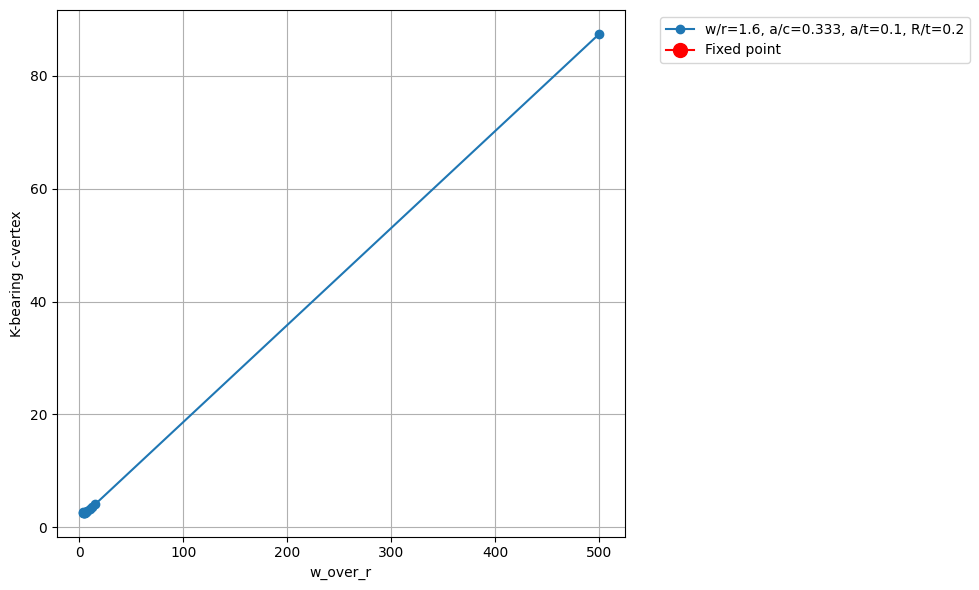

Data filtered for fixed parameters excluding a_over_c: (9, 18)
Unique a_over_c values in filtered data: [ 2.  3.  4.  5.  6.  7.  8.  9. 10.]
Data [w/r, a/c, a/t, R/t, Kbearing_c], index:
  [1.60, 2.00, 0.10, 0.200, 8.2110, 85611]
  [1.60, 3.00, 0.10, 0.200, 8.2070, 85733]
  [1.60, 4.00, 0.10, 0.200, 7.9270, 85872]
  [1.60, 5.00, 0.10, 0.200, 7.5960, 86024]
  [1.60, 6.00, 0.10, 0.200, 7.2690, 86180]
  [1.60, 7.00, 0.10, 0.200, 6.9670, 86341]
  [1.60, 8.00, 0.10, 0.200, 6.6900, 86508]
  [1.60, 9.00, 0.10, 0.200, 6.4400, 86680]
  [1.60, 10.00, 0.10, 0.200, 6.2120, 86851]
Data point indices: [85611 85733 85872 86024 86180 86341 86508 86680 86851]


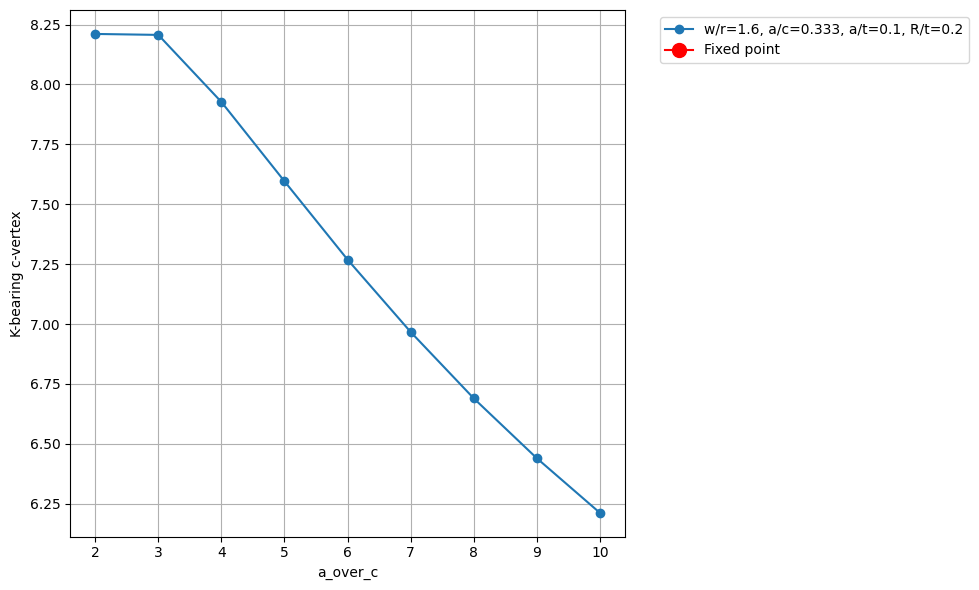

Data filtered for fixed parameters excluding a_over_t: (0, 18)
Unique a_over_t values in filtered data: []
Data [w/r, a/c, a/t, R/t, Kbearing_c], index:
Data point indices: []


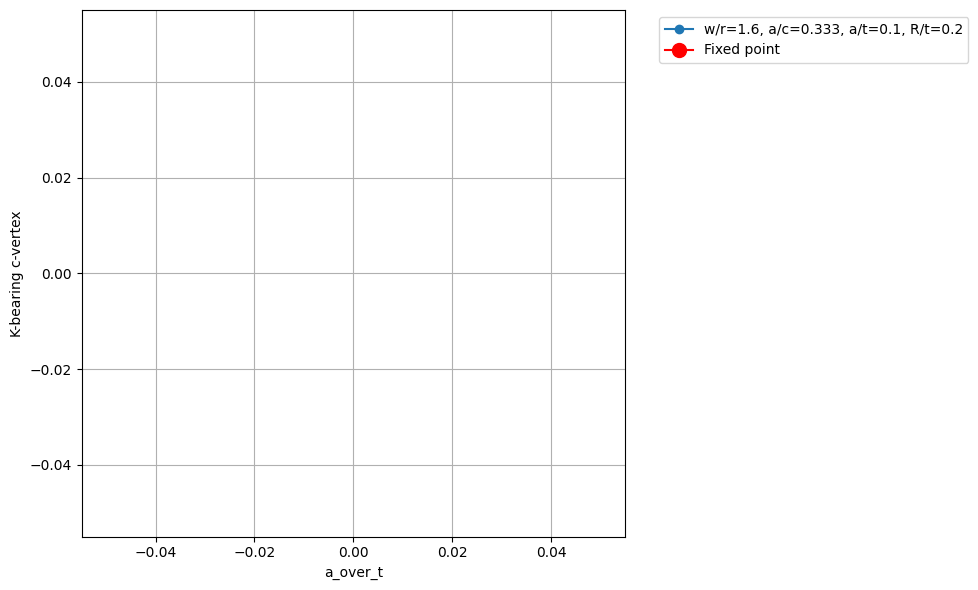

Data filtered for fixed parameters excluding R_over_t: (15, 18)
Unique R_over_t values in filtered data: [ 0.80000001  1.          1.25        1.5         1.75        2.
  2.25        2.5         3.          4.          5.          6.
  7.          8.         10.        ]
Data [w/r, a/c, a/t, R/t, Kbearing_c], index:
  [1.60, 0.33, 0.10, 0.800, 3.0250, 15893]
  [1.60, 0.33, 0.10, 1.000, 11.1600, 19462]
  [1.60, 0.33, 0.10, 1.250, 3.1680, 23211]
  [1.60, 0.33, 0.10, 1.500, 3.1640, 28642]
  [1.60, 0.33, 0.10, 1.750, 3.1360, 32667]
  [1.60, 0.33, 0.10, 2.000, 9.1620, 36796]
  [1.60, 0.33, 0.10, 2.250, 3.0430, 41005]
  [1.60, 0.33, 0.10, 2.500, 8.5070, 45261]
  [1.60, 0.33, 0.10, 3.000, 2.8800, 49574]
  [1.60, 0.33, 0.10, 4.000, 2.6720, 54031]
  [1.60, 0.33, 0.10, 5.000, 2.4940, 58512]
  [1.60, 0.33, 0.10, 6.000, 2.3430, 63098]
  [1.60, 0.33, 0.10, 7.000, 2.2140, 67566]
  [1.60, 0.33, 0.10, 8.000, 2.1040, 72021]
  [1.60, 0.33, 0.10, 10.000, 1.9240, 76380]
Data point indices: [15893 19462 2

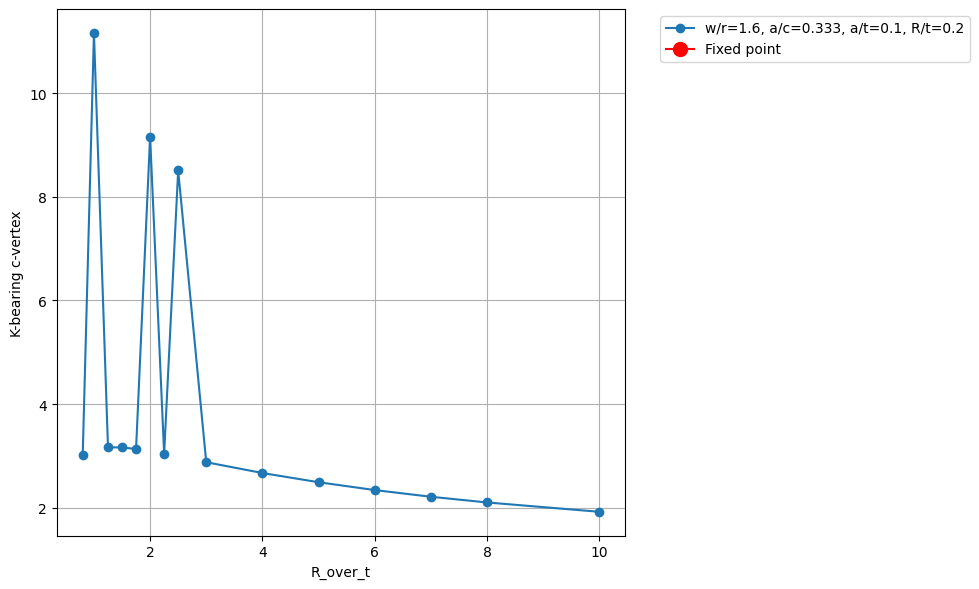

In [5]:
all_params_all_Ks = np.load('all_params_all_Ks.npy')
# Add an index column for easier reference
print(all_params_all_Ks.shape)
all_params_all_Ks_with_reference = np.column_stack([all_params_all_Ks, np.arange(len(all_params_all_Ks))])
print(all_params_all_Ks_with_reference.shape)
# Find all the unique values for each parameter
unique_w_over_r = np.unique(all_params_all_Ks_with_reference[:, w_over_r_idx])
unique_a_over_c = np.unique(all_params_all_Ks_with_reference[:, a_over_c_idx])
unique_a_over_t = np.unique(all_params_all_Ks_with_reference[:, a_over_t_idx])
unique_R_over_t = np.unique(all_params_all_Ks_with_reference[:, R_over_t_idx])
# unique_c = np.unique(all_params_all_Ks_with_reference[:, c_idx])

print("Unique a/c values:", unique_a_over_c)
print("Unique a/t values:", unique_a_over_t)
print("Unique R/t values:", unique_R_over_t)
# print("Unique c values:", unique_c)
feature_names = ['w_over_r', 'a_over_c', 'a_over_t', 'R_over_t']
feature_indices = [w_over_r_idx, a_over_c_idx, a_over_t_idx, R_over_t_idx]

# Example: Filter data for specific R/t value
fixed_w_over_r = 1.6 #1.6 # 8.0  #15.0
fixed_a_over_c = 0.333   #0.5 # 0.2  #0.1
fixed_a_over_t = 0.1  #0.2
fixed_R_over_t = 0.2  #2.0
fixed_all = [fixed_w_over_r, fixed_a_over_c, fixed_a_over_t, fixed_R_over_t]

mask_w_over_r = np.isclose(all_params_all_Ks_with_reference[:, w_over_r_idx], fixed_w_over_r)
mask_a_over_c = np.isclose(all_params_all_Ks_with_reference[:, a_over_c_idx], fixed_a_over_c)
mask_a_over_t = np.isclose(all_params_all_Ks_with_reference[:, a_over_t_idx], fixed_a_over_t)
mask_R_over_t = np.isclose(all_params_all_Ks_with_reference[:, R_over_t_idx], fixed_R_over_t)
mask_list = [mask_w_over_r, mask_a_over_c, mask_a_over_t, mask_R_over_t]

# print(f"Data filtered for w/r={fixed_w_over_r}, a/c={fixed_a_over_c}, a/t={fixed_a_over_t}, R/t={fixed_R_over_t}: {filtered_data_fixed_params.shape}")

# Create a combined mask of the other three fixed parameters, for each parameter free case
for i in range(len(feature_names)): 
    masks_to_combine = [mask_list[j] for j in range(len(feature_names)) if j != i]
    combined_mask = np.logical_and.reduce(masks_to_combine)
    filtered_data_fixed_params = all_params_all_Ks_with_reference[combined_mask]
    print(f"Data filtered for fixed parameters excluding {feature_names[i]}: {filtered_data_fixed_params.shape}")
    print(f"Unique {feature_names[i]} values in filtered data: {np.unique(filtered_data_fixed_params[:, feature_indices[i]])}")

    # Print array with reduced significant figures, one row per line
    selected_data = filtered_data_fixed_params[:, [w_over_r_idx, a_over_c_idx, a_over_t_idx, R_over_t_idx, Kbearing_c_idx, -1]]
    print("Data [w/r, a/c, a/t, R/t, Kbearing_c], index:")
    for row in selected_data:
        print(f"  [{row[0]:.2f}, {row[1]:.2f}, {row[2]:.2f}, {row[3]:.3f}, {row[4]:.4f}, {row[5]:.0f}]")
    print(f"Data point indices: {filtered_data_fixed_params[:, -1].astype(int)}")
    # Plot the free parameter vs Kbearing_c
    plt.figure(figsize=(10, 6))
    plt.plot(filtered_data_fixed_params[:, feature_indices[i]], filtered_data_fixed_params[:, Kbearing_c_idx], marker='o', label=f'w/r={fixed_w_over_r}, a/c={fixed_a_over_c}, a/t={fixed_a_over_t}, R/t={fixed_R_over_t}')
    # Make the point with free_feature = fixed_all[i] a different color
    free_feature_value = fixed_all[i]
    mask_fixed_point = np.isclose(filtered_data_fixed_params[:, feature_indices[i]], free_feature_value)
    plt.plot(filtered_data_fixed_params[mask_fixed_point, feature_indices[i]], filtered_data_fixed_params[mask_fixed_point, Kbearing_c_idx], marker='o', color='red', markersize=10, label='Fixed point')

    plt.xlabel(feature_names[i])
    plt.ylabel('K-bearing c-vertex')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid()
    plt.tight_layout()
    plt.show()


In [28]:
all_params_all_Ks = np.load('all_params_all_Ks.npy')
all_params_all_Ks = np.load('all_params_all_Ks_vertex_flagged.npy')

# Add an index column for easier reference
print(all_params_all_Ks.shape)
all_params_all_Ks_with_reference = np.column_stack([all_params_all_Ks, np.arange(len(all_params_all_Ks))])
print(all_params_all_Ks_with_reference.shape)
# Find all the unique values for each parameter
unique_w_over_r = np.unique(all_params_all_Ks_with_reference[:, w_over_r_idx])
unique_a_over_c = np.unique(all_params_all_Ks_with_reference[:, a_over_c_idx])
unique_a_over_t = np.unique(all_params_all_Ks_with_reference[:, a_over_t_idx])
unique_R_over_t = np.unique(all_params_all_Ks_with_reference[:, R_over_t_idx])
# unique_c = np.unique(all_params_all_Ks_with_reference[:, c_idx])

print("Unique w/r values:", unique_w_over_r)
print("Unique a/c values:", unique_a_over_c)
print("Unique a/t values:", unique_a_over_t)
print("Unique R/t values:", unique_R_over_t)
# print("Unique c values:", unique_c)
feature_names = ['w_over_r', 'a_over_c', 'a_over_t', 'R_over_t']
feature_indices = [w_over_r_idx, a_over_c_idx, a_over_t_idx, R_over_t_idx]
feature_unique_values = [unique_w_over_r, unique_a_over_c, unique_a_over_t, unique_R_over_t]


num_reductions = 0
num_combinations = 0
# reductions = []
reduction_dicts = []

for i in range(len(feature_names)):
    remaining_feature_names = [feature_names[j] for j in range(len(feature_names)) if j != i]
    remaining_feature_indices = [feature_indices[j] for j in range(len(feature_names)) if j != i]
    remaining_feature_unique_values = [feature_unique_values[j] for j in range(len(feature_names)) if j != i]
    
    combined_mask = []
    for fixed_feature_0 in tqdm(remaining_feature_unique_values[0]):
        for fixed_feature_1 in remaining_feature_unique_values[1]:
            for fixed_feature_2 in remaining_feature_unique_values[2]:
                mask_feature_0 = np.isclose(all_params_all_Ks_with_reference[:, remaining_feature_indices[0]], fixed_feature_0)
                mask_feature_1 = np.isclose(all_params_all_Ks_with_reference[:, remaining_feature_indices[1]], fixed_feature_1)
                mask_feature_2 = np.isclose(all_params_all_Ks_with_reference[:, remaining_feature_indices[2]], fixed_feature_2)
                mask_list = [mask_feature_0, mask_feature_1, mask_feature_2]
                
                combined_mask = np.logical_and.reduce(mask_list)
                filtered_data_fixed_params = all_params_all_Ks_with_reference[combined_mask]
                if filtered_data_fixed_params.shape[0] == 0:
                    continue
                # print(f"Data filtered for fixed parameters excluding {feature_names[i]}: {filtered_data_fixed_params.shape}")
                # print(f"Unique {feature_names[i]} values in filtered data: {np.unique(filtered_data_fixed_params[:, feature_indices[i]])}")
                # print(f"Unique {feature_names[i]} values in filtered data: {np.unique(filtered_data_fixed_params[:, feature_indices[i]])}")

                # Build data dictionary
                data_dict = {
                    "data_index": filtered_data_fixed_params[:, -1].astype(int),
                    "free_param_name": feature_names[i],
                    remaining_feature_names[0]: fixed_feature_0,
                    remaining_feature_names[1]: fixed_feature_1,
                    remaining_feature_names[2]: fixed_feature_2,
                    "data": {
                        "free_param_data": filtered_data_fixed_params[:, feature_indices[i]],
                        "Ktension_c_data": filtered_data_fixed_params[:, Ktension_c_idx],
                        "Kbending_c_data": filtered_data_fixed_params[:, Kbending_c_idx],
                        "Kbearing_c_data": filtered_data_fixed_params[:, Kbearing_c_idx],
                        "Ktension_a_data": filtered_data_fixed_params[:, Ktension_a_idx],
                        "Kbending_a_data": filtered_data_fixed_params[:, Kbending_a_idx],
                        "Kbearing_a_data": filtered_data_fixed_params[:, Kbearing_a_idx],
                        "Ktension_c_vertex_flag": filtered_data_fixed_params[:, Ktension_c_idx + 6],
                        "Kbending_c_vertex_flag": filtered_data_fixed_params[:, Kbending_c_idx + 6],
                        "Kbearing_c_vertex_flag": filtered_data_fixed_params[:, Kbearing_c_idx + 6],
                        "Ktension_a_vertex_flag": filtered_data_fixed_params[:, Ktension_a_idx + 6],
                        "Kbending_a_vertex_flag": filtered_data_fixed_params[:, Kbending_a_idx + 6],
                        "Kbearing_a_vertex_flag": filtered_data_fixed_params[:, Kbearing_a_idx + 6],
                    },
                    # "data_array": filtered_data_fixed_params,
                    
                }

                reduction_dicts.append(data_dict)


(92149, 23)
(92149, 24)
Unique w/r values: [   1.60000002    1.79999995    2.            2.20000005    2.4000001
    2.79999995    3.20000005    3.5999999     4.            4.5999999
    5.19999981    5.80000019    6.4000001     7.            8.
   10.           12.           12.5          14.30000019   15.
   16.70000076   20.           25.           33.29999924   40.
   44.40000153   50.           57.09999847   66.69999695   80.
  100.          125.          149.8999939   175.          200.
  225.          250.          300.29998779  400.          500.
  599.90002441  700.29998779  800.         1000.        ]
Unique a/c values: [ 0.1         0.111       0.125       0.1428      0.16670001  0.2
  0.25        0.333       0.5         0.667       0.75        0.80000001
  1.          1.25        1.33299994  1.5         2.          3.
  4.          5.          6.          7.          8.          9.
 10.        ]
Unique a/t values: [0.1        0.2        0.30000001 0.40000001 0.5        0.60

100%|██████████| 44/44 [00:29<00:00,  1.49it/s]


In [29]:
print(len(reduction_dicts))

with open("reduction_dicts.pkl", "wb") as f:
    pickle.dump(reduction_dicts, f)
# convert reductions to numpy arrays and print their shapes


34123


In [43]:
# Load reduction_dicts from pickle file
with open("reduction_dicts.pkl", "rb") as f:
    reduction_dicts = pickle.load(f)


{'data_index': array([87024, 87025, 87026, 87027, 87028, 87029, 87030]), 'free_param_name': 'w_over_r', 'a_over_c': np.float64(0.10000000149011612), 'a_over_t': np.float64(0.10000000149011612), 'R_over_t': np.float64(0.25), 'data': {'free_param_data': array([  6.4000001,   7.       ,   8.       ,  10.       ,  12.       ,
        15.       , 400.       ]), 'Ktension_c_data': array([1.49600005, 1.49100006, 1.48300004, 1.47300005, 1.48399997,
       1.46200001, 1.454     ]), 'Kbending_c_data': array([1.55599999, 1.53699994, 1.51800001, 1.49899995, 1.49000001,
       1.48199999, 1.48099995]), 'Kbearing_c_data': array([4.70900011, 4.69999981, 4.68300009, 4.86299992, 5.02600002,
       5.43499994, 9.77200031]), 'Ktension_a_data': array([8.0710001 , 8.02400017, 7.96799994, 7.90500021, 7.87200022,
       7.84499979, 7.79500008]), 'Kbending_a_data': array([6.15500021, 6.11199999, 6.0619998 , 6.00400019, 5.97200012,
       5.94700003, 5.90500021]), 'Kbearing_a_data': array([ 47.02000046,  49.54

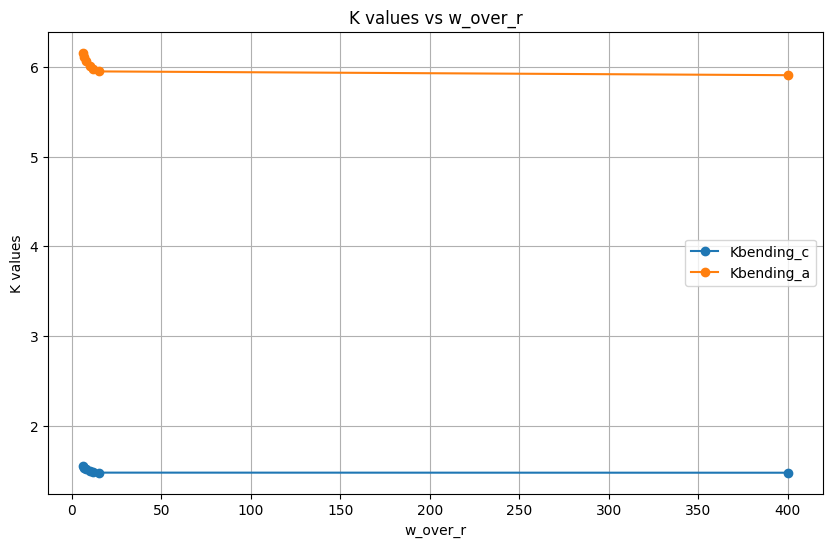

{'data_index': array([89453, 89454, 89455, 89456, 89457, 89458, 89459, 89460]), 'free_param_name': 'w_over_r', 'a_over_c': np.float64(0.10000000149011612), 'a_over_t': np.float64(0.10000000149011612), 'R_over_t': np.float64(0.3330000042915344), 'data': {'free_param_data': array([  5.19999981,   5.80000019,   6.4000001 ,   7.        ,
         8.        ,  12.        ,  15.        , 300.29998779]), 'Ktension_c_data': array([1.32299995, 1.31799996, 1.31299996, 1.30700004, 1.301     ,
       1.28799999, 1.28499997, 1.27900004]), 'Kbending_c_data': array([1.403     , 1.37800002, 1.36199999, 1.35000002, 1.33800006,
       1.32700002, 1.31299996, 1.30400002]), 'Kbearing_c_data': array([0.94029999, 0.9612    , 0.96789998, 0.96340001, 0.97920001,
       1.06900001, 1.14999998, 9.99800014]), 'Ktension_a_data': array([7.46500015, 7.38999987, 7.33599997, 7.29699993, 7.25099993,
       7.17000008, 7.14699984, 7.10599995]), 'Kbending_a_data': array([5.49300003, 5.42999983, 5.38500023, 5.35200024, 5

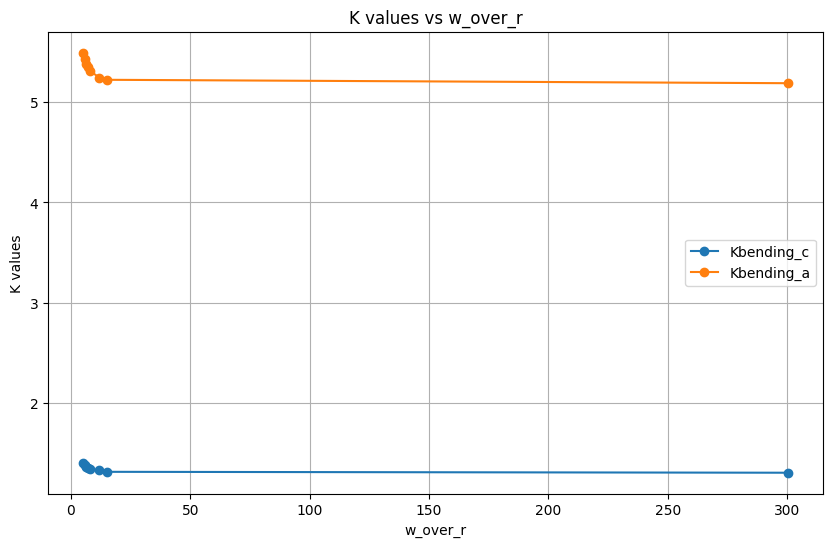

{'data_index': array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), 'free_param_name': 'w_over_r', 'a_over_c': np.float64(0.10000000149011612), 'a_over_t': np.float64(0.10000000149011612), 'R_over_t': np.float64(0.4000000059604645), 'data': {'free_param_data': array([  4.5999999 ,   5.19999981,   5.80000019,   6.4000001 ,
         7.        ,   8.        ,  10.        ,  12.        ,
        15.        , 250.        ]), 'Ktension_c_data': array([1.23000002, 1.22500002, 1.21899998, 1.21300006, 1.20799994,
       1.20299995, 1.19500005, 1.19200003, 1.18799996, 1.18299997]), 'Kbending_c_data': array([1.32099998, 1.29100001, 1.27199996, 1.25999999, 1.25100005,
       1.24100006, 1.22899997, 1.22399998, 1.21899998, 1.20899999]), 'Kbearing_c_data': array([ 0.9113    ,  0.93409997,  0.9429    ,  0.95319998,  0.9655    ,
        0.98970002,  1.03400004,  1.11199999,  1.20000005, 10.07999992]), 'Ktension_a_data': array([7.12400007, 7.02400017, 6.95599985, 6.90799999, 6.87200022,
       6.82999992, 6.78100014

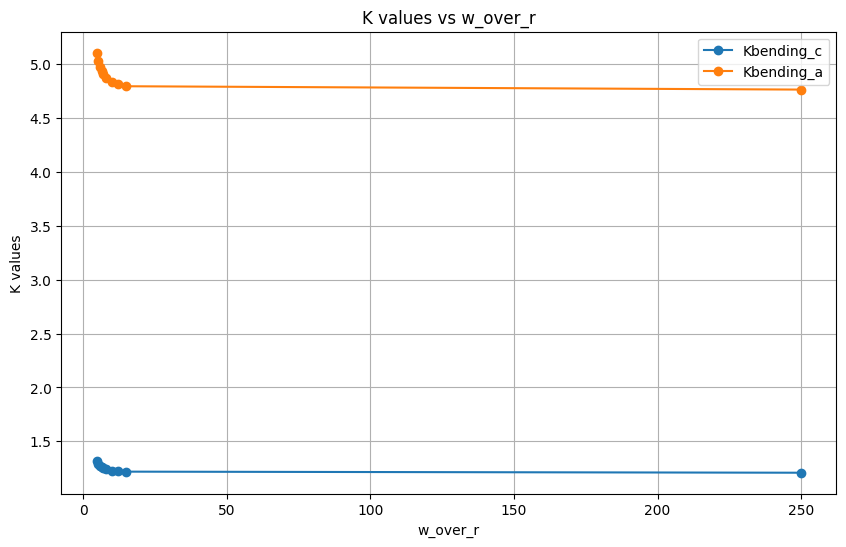

{'data_index': array([2877, 2878, 2879, 2880, 2881, 2882, 2883, 2884, 2885, 2886, 2887]), 'free_param_name': 'w_over_r', 'a_over_c': np.float64(0.10000000149011612), 'a_over_t': np.float64(0.10000000149011612), 'R_over_t': np.float64(0.44440001249313354), 'data': {'free_param_data': array([  4.        ,   4.5999999 ,   5.19999981,   5.80000019,
         6.4000001 ,   7.        ,   8.        ,  10.        ,
        12.        ,  15.        , 225.        ]), 'Ktension_c_data': array([1.18200004, 1.18099999, 1.17499995, 1.16799998, 1.16199994,
       1.15799999, 1.15199995, 1.14499998, 1.15499997, 1.13900006,
       1.13399994]), 'Kbending_c_data': array([1.30400002, 1.25999999, 1.23399997, 1.21800005, 1.21500003,
       1.199     , 1.19000006, 1.17999995, 1.18299997, 1.16999996,
       1.16400003]), 'Kbearing_c_data': array([ 0.88510001,  0.90539998,  0.92720002,  0.92629999,  0.95130002,
        0.96670002,  0.98320001,  1.04999995,  1.12300003,  1.23899996,
       10.10000038]), 'Ktens

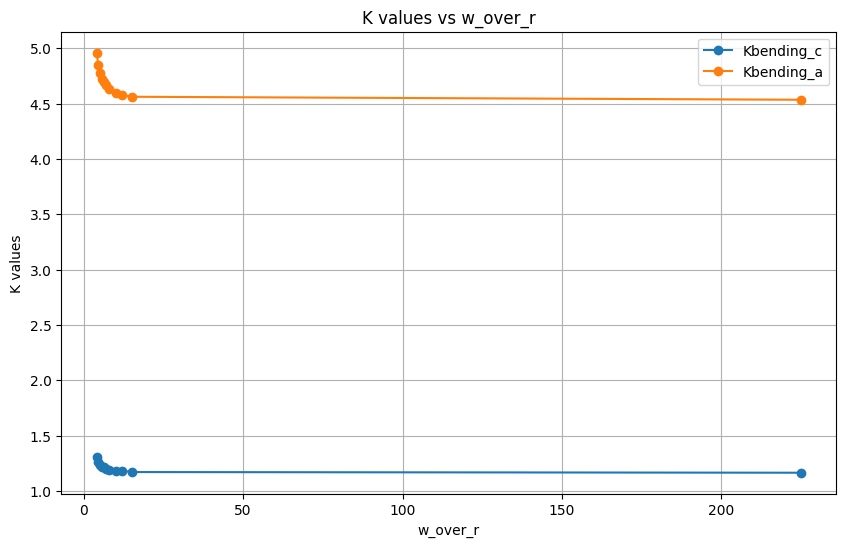

{'data_index': array([5850, 5851, 5852, 5853, 5854, 5855, 5856, 5857, 5858, 5859, 5860,
       5861]), 'free_param_name': 'w_over_r', 'a_over_c': np.float64(0.10000000149011612), 'a_over_t': np.float64(0.10000000149011612), 'R_over_t': np.float64(0.5), 'data': {'free_param_data': array([  3.5999999 ,   4.        ,   4.5999999 ,   5.19999981,
         5.80000019,   6.4000001 ,   7.        ,   8.        ,
        10.        ,  12.        ,  15.        , 200.        ]), 'Ktension_c_data': array([1.13      , 1.13600004, 1.13      , 1.12199998, 1.11500001,
       1.11000001, 1.10599995, 1.10000002, 1.09399998, 1.10399997,
       1.08800006, 1.08299994]), 'Kbending_c_data': array([1.27699995, 1.23500001, 1.19799995, 1.176     , 1.16199994,
       1.15199995, 1.14499998, 1.13600004, 1.12699997, 1.12199998,
       1.11899996, 1.11000001]), 'Kbearing_c_data': array([ 4.22200012,  4.18599987,  4.13899994,  4.17299986,  4.27600002,
        4.32399988,  4.46400023,  4.61299992,  5.08500004,  5.498

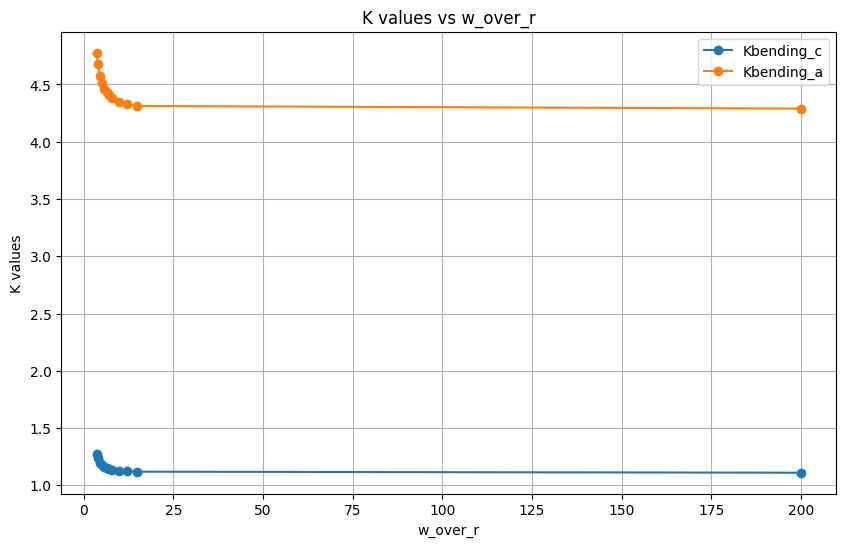

Number of entries with more than 8 data points: 5


In [ ]:

num_long_entries = 0
for i in range(10):
    if len(reduction_dicts[i]["data"]["free_param_data"]) > 5:
        num_long_entries += 1

        print(reduction_dicts[i])
        # Checking all data params for changing values
        # temp_array = []
        # for idx in reduction_dicts[i]["data_index"]:
            # temp_array.append(all_params_all_Ks_with_reference[idx])
        # temp_array = np.array(temp_array)
        # for j in range(temp_array.shape[1]-1):
            # print(index_feature_name_map[j], temp_array[:, j])

        # print(reduction_dicts[i])
        # Reorder the sets by increasing free_param
        

        # Plot the free parameter vs each K value
        plt.figure(figsize=(10, 6))
        # plt.plot(reduction_dicts[i]["data"]["free_param_data"], reduction_dicts[i]["data"]["Ktension_c_data"], marker='o', label='Ktension_c')
        plt.plot(reduction_dicts[i]["data"]["free_param_data"], reduction_dicts[i]["data"]["Kbending_c_data"], marker='o', label='Kbending_c')
        # plt.plot(reduction_dicts[i]["data"]["free_param_data"], reduction_dicts[i]["data"]["Kbearing_c_data"], marker='o', label='Kbearing_c')
        # plt.plot(reduction_dicts[i]["data"]["free_param_data"], reduction_dicts[i]["data"]["Ktension_a_data"], marker='o', label='Ktension_a')
        plt.plot(reduction_dicts[i]["data"]["free_param_data"], reduction_dicts[i]["data"]["Kbending_a_data"], marker='o', label='Kbending_a')
        # plt.plot(reduction_dicts[i]["data"]["free_param_data"], reduction_dicts[i]["data"]["Kbearing_a_data"], marker='o', label='Kbearing_a')
        plt.xlabel(reduction_dicts[i]["free_param_name"])
        plt.ylabel("K values")
        plt.title(f"K values vs {reduction_dicts[i]['free_param_name']}")
        plt.legend()
        plt.grid(True)
        plt.show()

print("Number of entries with more than 8 data points:", num_long_entries)


In [44]:
fixed_param_mapping = []
for i in range(len(reduction_dicts)):
    row_fixed_params = []
    if reduction_dicts[i]["free_param_name"] == "w_over_r":
        row_fixed_params.append(np.nan)
        row_fixed_params.append(reduction_dicts[i]["a_over_c"])
        row_fixed_params.append(reduction_dicts[i]["a_over_t"])
        row_fixed_params.append(reduction_dicts[i]["R_over_t"])
    elif reduction_dicts[i]["free_param_name"] == "a_over_c":
        row_fixed_params.append(reduction_dicts[i]["w_over_r"])
        row_fixed_params.append(np.nan)
        row_fixed_params.append(reduction_dicts[i]["a_over_t"])
        row_fixed_params.append(reduction_dicts[i]["R_over_t"])
    elif reduction_dicts[i]["free_param_name"] == "a_over_t":
        row_fixed_params.append(reduction_dicts[i]["w_over_r"])
        row_fixed_params.append(reduction_dicts[i]["a_over_c"])
        row_fixed_params.append(np.nan)
        row_fixed_params.append(reduction_dicts[i]["R_over_t"])
    elif reduction_dicts[i]["free_param_name"] == "R_over_t":
        row_fixed_params.append(reduction_dicts[i]["w_over_r"])
        row_fixed_params.append(reduction_dicts[i]["a_over_c"])
        row_fixed_params.append(reduction_dicts[i]["a_over_t"])
        row_fixed_params.append(np.nan)

    if len(row_fixed_params) == 4:
        row_fixed_params.append(i)
    else:
        print("Something went wrong, list isn't length 4")

    fixed_param_mapping.append(row_fixed_params)

fixed_param_mapping = np.array(fixed_param_mapping)

print("Length of reduction_dicts:", len(reduction_dicts))
print("Fixed parameter mapping array shape:", fixed_param_mapping.shape)

Length of reduction_dicts: 34123
Fixed parameter mapping array shape: (34123, 5)


In [45]:
# Record length before filtering
initial_length = len(reduction_dicts)

# Remove all entries that have W/r > 90
mask_w_over_r_below_90 = fixed_param_mapping[:, 0] <= 50
reduction_dicts = [reduction_dicts[i] for i in range(len(reduction_dicts)) if mask_w_over_r_below_90[i]]
fixed_param_mapping = fixed_param_mapping[mask_w_over_r_below_90]

# Print new / old lengths
print(f"Filtered reduction_dicts length: {len(reduction_dicts)} (from {initial_length})")

Filtered reduction_dicts length: 22664 (from 34123)


(92149, 17)
(92149, 18)
Unique w/r values: [   1.60000002    1.79999995    2.            2.20000005    2.4000001
    2.79999995    3.20000005    3.5999999     4.            4.5999999
    5.19999981    5.80000019    6.4000001     7.            8.
   10.           12.           12.5          14.30000019   15.
   16.70000076   20.           25.           33.29999924   40.
   44.40000153   50.           57.09999847   66.69999695   80.
  100.          125.          149.8999939   175.          200.
  225.          250.          300.29998779  400.          500.
  599.90002441  700.29998779  800.         1000.        ]
Unique a/c values: [ 0.1         0.111       0.125       0.1428      0.16670001  0.2
  0.25        0.333       0.5         0.667       0.75        0.80000001
  1.          1.25        1.33299994  1.5         2.          3.
  4.          5.          6.          7.          8.          9.
 10.        ]
Unique a/t values: [0.1        0.2        0.30000001 0.40000001 0.5        0.60

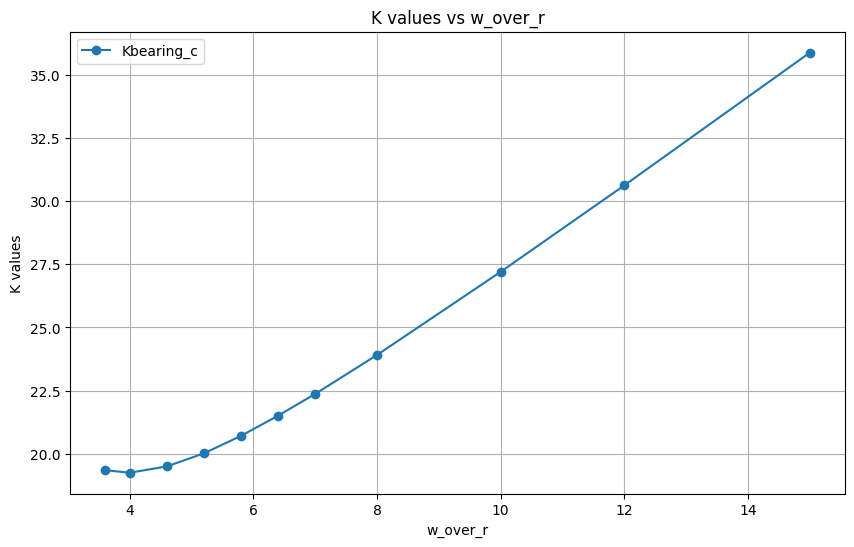

10342


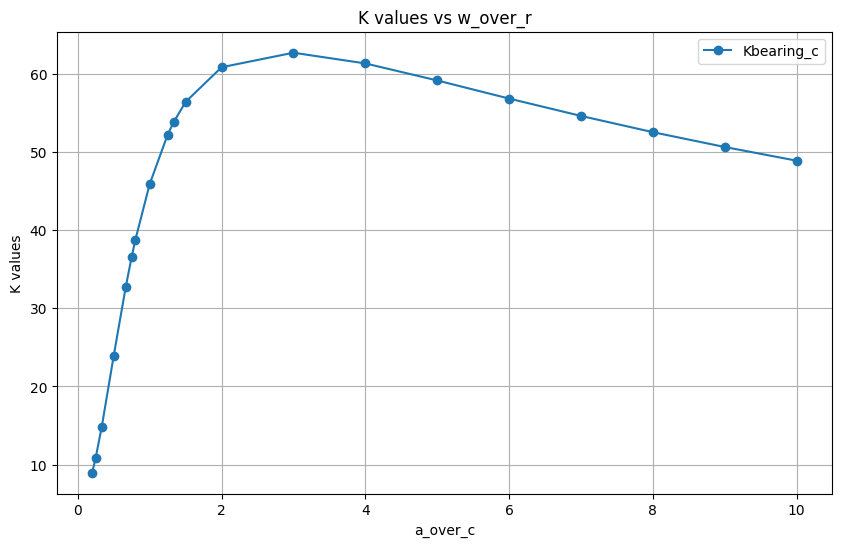

20175


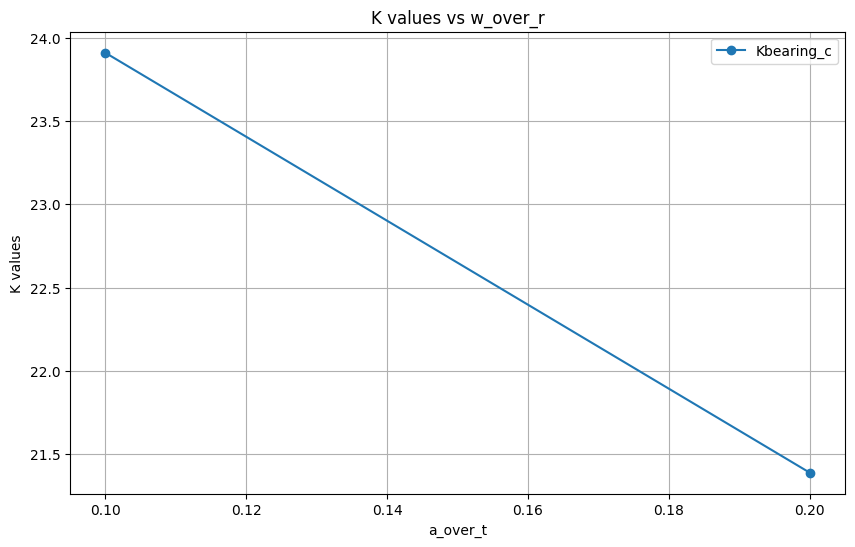

26824


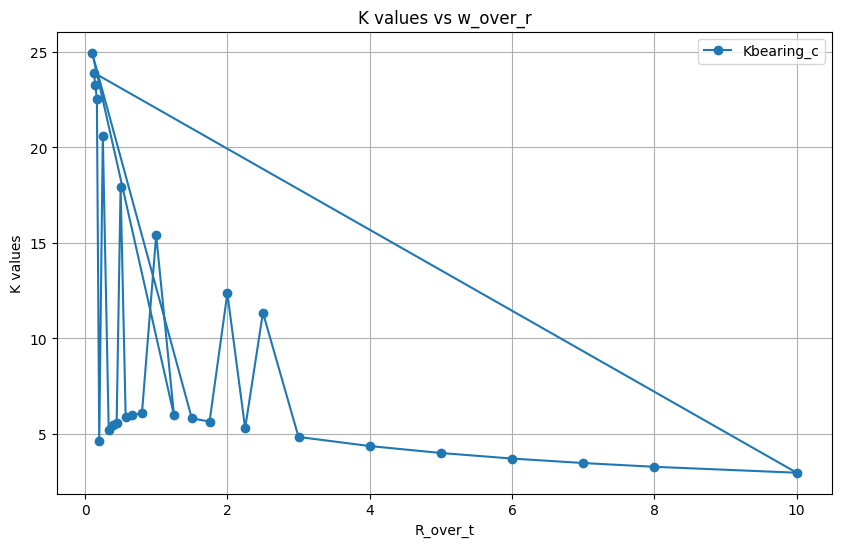

In [39]:
all_params_all_Ks = np.load('all_params_all_Ks.npy')
# Add an index column for easier reference
print(all_params_all_Ks.shape)
all_params_all_Ks_with_reference = np.column_stack([all_params_all_Ks, np.arange(len(all_params_all_Ks))])
print(all_params_all_Ks_with_reference.shape)
# Find all the unique values for each parameter
unique_w_over_r = np.unique(all_params_all_Ks_with_reference[:, w_over_r_idx])
unique_a_over_c = np.unique(all_params_all_Ks_with_reference[:, a_over_c_idx])
unique_a_over_t = np.unique(all_params_all_Ks_with_reference[:, a_over_t_idx])
unique_R_over_t = np.unique(all_params_all_Ks_with_reference[:, R_over_t_idx])
# unique_c = np.unique(all_params_all_Ks_with_reference[:, c_idx])

print("Unique w/r values:", unique_w_over_r)
print("Unique a/c values:", unique_a_over_c)
print("Unique a/t values:", unique_a_over_t)
print("Unique R/t values:", unique_R_over_t)
# print("Unique c values:", unique_c)
feature_names = ['w_over_r', 'a_over_c', 'a_over_t', 'R_over_t']
feature_indices = [w_over_r_idx, a_over_c_idx, a_over_t_idx, R_over_t_idx]
feature_unique_values = [unique_w_over_r, unique_a_over_c, unique_a_over_t, unique_R_over_t]


# Example: Filter data for specific R/t value
fixed_w_over_r = 8.0 # 8.0  #15.0
fixed_a_over_c = 0.5  #0.1
fixed_a_over_t = 0.1
fixed_R_over_t = 0.125
fixed_all = [fixed_w_over_r, fixed_a_over_c, fixed_a_over_t, fixed_R_over_t]

mask_w_over_r = np.isclose(fixed_param_mapping[:, 0], fixed_w_over_r)
mask_a_over_c = np.isclose(fixed_param_mapping[:, 1], fixed_a_over_c)
mask_a_over_t = np.isclose(fixed_param_mapping[:, 2], fixed_a_over_t)
mask_R_over_t = np.isclose(fixed_param_mapping[:, 3], fixed_R_over_t)
mask_list = [mask_w_over_r, mask_a_over_c, mask_a_over_t, mask_R_over_t]

for i in range(len(feature_names)): 
    masks_to_combine = [mask_list[j] for j in range(len(feature_names)) if j != i]

    # Find the entry in fixed_param_mapping with these values:
    combined_mask = np.logical_and.reduce(masks_to_combine)
    match = fixed_param_mapping[combined_mask]
    if match.shape[0] != 1:
        print("ERROR")
        continue
    
    match_idx = int(match[0,-1])
    print(match_idx)


    plt.figure(figsize=(10, 6))
    # plt.plot(reduction_dicts[match_idx]["data"]["free_param_data"], reduction_dicts[match_idx]["data"]["Ktension_c_data"], marker='o', label='Ktension_c')
    # plt.plot(reduction_dicts[match_idx]["data"]["free_param_data"], reduction_dicts[match_idx]["data"]["Kbending_c_data"], marker='o', label='Kbending_c')
    plt.plot(reduction_dicts[match_idx]["data"]["free_param_data"], reduction_dicts[match_idx]["data"]["Kbearing_c_data"], marker='o', label='Kbearing_c')
    # plt.plot(reduction_dicts[match_idx]["data"]["free_param_data"], reduction_dicts[match_idx]["data"]["Ktension_a_data"], marker='o', label='Ktension_a')
    # plt.plot(reduction_dicts[match_idx]["data"]["free_param_data"], reduction_dicts[match_idx]["data"]["Kbending_a_data"], marker='o', label='Kbending_a')
    # plt.plot(reduction_dicts[match_idx]["data"]["free_param_data"], reduction_dicts[match_idx]["data"]["Kbearing_a_data"], marker='o', label='Kbearing_a')
    
    plt.xlabel(reduction_dicts[match_idx]["free_param_name"])
    plt.ylabel("K values")
    plt.title(f"K values vs {reduction_dicts[i]['free_param_name']}")
    plt.legend()
    plt.grid(True)
    plt.show()


## Simple Polynomial Fitting for Curve Quality Assessment

In [ ]:
def simple_polynomial_fit(x, y, min_degree=2, max_degree=5, min_points=4):
    """
    Fit polynomials of degrees min_degree to max_degree and select the best based on R².
    
    Parameters:
    -----------
    x : array-like
        Independent variable
    y : array-like
        Dependent variable
    min_degree : int
        Minimum polynomial degree to try (default: 2)
    max_degree : int
        Maximum polynomial degree to try (default: 5)
    min_points : int
        Minimum number of valid points required (default: 4)
    
    Returns:
    --------
    dict with keys:
        - 'best_degree': Selected polynomial degree
        - 'best_r2': R² value of best fit
        - 'best_rmse': RMSE of best fit
        - 'coeffs': Polynomial coefficients of best fit
        - 'y_pred': Predicted y values
        - 'all_fits': Dict with results for each degree tried
        - 'is_bad_fit': Boolean indicating poor fit quality
        - 'n_points': Number of valid data points
    """
    from sklearn.metrics import r2_score, mean_squared_error
    
    result = {
        'best_degree': None,
        'best_r2': -np.inf,
        'best_rmse': np.inf,
        'coeffs': None,
        'y_pred': None,
        'all_fits': {},
        'is_bad_fit': True,
        'n_points': 0
    }
    
    # Input validation
    if x is None or y is None or len(x) < min_points:
        return result
    
    x_array = np.array(x)
    y_array = np.array(y)
    
    # Remove NaN/Inf values
    valid_mask = np.isfinite(x_array) & np.isfinite(y_array)
    if valid_mask.sum() < min_points:
        return result
    
    x_clean = x_array[valid_mask]
    y_clean = y_array[valid_mask]
    
    # Sort by x
    sort_idx = np.argsort(x_clean)
    x_sorted = x_clean[sort_idx]
    y_sorted = y_clean[sort_idx]
    
    result['n_points'] = len(x_sorted)

    # Additional check: need at least 2 points for R² calculation
    if len(x_sorted) < 2:
        return result
    
    # Try each polynomial degree
    max_feasible_degree = min(max_degree, len(x_sorted) - 1)
    
    for degree in range(min_degree, max_feasible_degree + 1):
        # Skip if we don't have enough points for this degree
        if len(x_sorted) < degree + 1:
            continue

        try:
            # Fit polynomial
            coeffs = np.polyfit(x_sorted, y_sorted, degree)
            y_pred = np.polyval(coeffs, x_sorted)
            
            # Calculate metrics
            r2 = r2_score(y_sorted, y_pred)
            mse = mean_squared_error(y_sorted, y_pred)
            rmse = np.sqrt(mse)
            
            # Store results for this degree
            result['all_fits'][degree] = {
                'r2': float(r2),
                'rmse': float(rmse),
                'coeffs': coeffs.tolist()
            }
            
            # Update best fit (with small penalty for higher degrees to avoid overfitting)
            adjusted_r2 = r2 - 0.001 * degree
            
            if adjusted_r2 > result['best_r2']:
                result['best_degree'] = degree
                result['best_r2'] = float(r2)
                result['best_rmse'] = float(rmse)
                result['coeffs'] = coeffs.tolist()
                result['y_pred'] = y_pred
                
        except Exception as e:
            result['all_fits'][degree] = {'error': str(e)}
            continue
    
    # Determine if fit is bad
    if result['best_r2'] is not None and result['best_r2'] > 0.5:
        result['is_bad_fit'] = False
    
    return result


# Test the function
print("=== Testing Simple Polynomial Fit Function ===\n")

# Test with quadratic data
test_x = np.array([1, 2, 3, 4, 5, 6, 7, 8])
test_y = np.array([1.0, 4.1, 9.0, 16.2, 24.9, 36.1, 49.0, 64.2])

result = simple_polynomial_fit(test_x, test_y, min_degree=2, max_degree=5)

print(f"Best degree: {result['best_degree']}")
print(f"Best R²: {result['best_r2']:.4f}")
print(f"Best RMSE: {result['best_rmse']:.4f}")
print(f"Is bad fit: {result['is_bad_fit']}")
print(f"\nAll fits tried:")
for degree, fit_info in result['all_fits'].items():
    if 'error' not in fit_info:
        print(f"  Degree {degree}: R² = {fit_info['r2']:.4f}, RMSE = {fit_info['rmse']:.4f}")
    else:
        print(f"  Degree {degree}: Error - {fit_info['error']}")

print("\n=== Function ready for use! ===")

=== Testing Simple Polynomial Fit Function ===



Best degree: 2
Best R²: 1.0000
Best RMSE: 0.0942
Is bad fit: False

All fits tried:
  Degree 2: R² = 1.0000, RMSE = 0.0942
  Degree 3: R² = 1.0000, RMSE = 0.0824
  Degree 4: R² = 1.0000, RMSE = 0.0818
  Degree 5: R² = 1.0000, RMSE = 0.0815

=== Function ready for use! ===


In [18]:
def detect_polynomial_outliers(x, y, poly_degree, method='ransac', threshold=3.5, pct_error_threshold=25.0, 
                               robust_fit=False, max_iter=100):
    """
    Detect outliers in polynomial fit using residual-based or Cook's distance methods.
    
    Parameters:
    -----------
    x : array-like
        Independent variable
    y : array-like
        Dependent variable
    poly_degree : int
        Degree of polynomial to fit
    method : str
        Outlier detection method:
        - 'mad': Modified z-score using Median Absolute Deviation
        - 'cooks': Cook's distance (influence of each point on fit)
        - 'huber': Huber regression (robust to outliers)
        - 'ransac': RANSAC polynomial fitting
    threshold : float
        Threshold for outlier detection
        - For 'mad': Modified z-score threshold (default 3.5)
        - For 'cooks': Cook's distance threshold (default 3.5, or use 4/n rule)
        - For 'huber': residual threshold for Huber loss (default 3.5)
        - For 'ransac': residual threshold for inliers (default 3.5)
    pct_error_threshold : float
        Percentage error threshold for MAD method (default 25.0)
        A point must exceed BOTH the z-score threshold AND this percentage error
        to be classified as an outlier. Only applies to 'mad' method.
    robust_fit : bool
        If True, use robust regression (Huber) for initial fit in MAD/Cook's methods
        This helps when outliers distort the initial polynomial fit (default False)
    max_iter : int
        Maximum iterations for iterative methods like Huber (default 100)
    
    Returns:
    --------
    dict with keys:
        - 'outlier_mask': Boolean array indicating outliers (True = outlier)
        - 'outlier_indices': Indices of outliers
        - 'scores': Detection scores for each point (modified z-score or Cook's D)
        - 'threshold_used': Actual threshold used
        - 'pct_error_threshold_used': Percentage error threshold used (MAD only)
        - 'pct_errors': Percentage errors for each point (MAD only)
        - 'coeffs': Polynomial coefficients of full fit
        - 'n_outliers': Number of outliers detected
        - 'method': Method used
        - 'robust_fit_used': Whether robust fitting was used
    """
    from sklearn.linear_model import HuberRegressor, RANSACRegressor
    from sklearn.preprocessing import PolynomialFeatures
    from sklearn.pipeline import make_pipeline
    
    result = {
        'outlier_mask': None,
        'outlier_indices': [],
        'scores': None,
        'threshold_used': threshold,
        'pct_error_threshold_used': pct_error_threshold if method == 'mad' else None,
        'pct_errors': None,
        'coeffs': None,
        'n_outliers': 0,
        'method': method,
        'robust_fit_used': robust_fit or method in ['huber', 'ransac']
    }
    
    # Input validation
    if x is None or y is None or len(x) < poly_degree + 2:
        return result
    
    x_array = np.array(x)
    y_array = np.array(y)
    
    # Remove NaN/Inf values
    valid_mask = np.isfinite(x_array) & np.isfinite(y_array)
    if valid_mask.sum() < poly_degree + 2:
        return result
    
    x_clean = x_array[valid_mask]
    y_clean = y_array[valid_mask]
    n = len(x_clean)
    
    # Reshape for sklearn
    X = x_clean.reshape(-1, 1)
    
    # Helper function to fit polynomial (OLS or Robust)
    def fit_polynomial(X, y, degree, use_robust=False):
        if use_robust:
            # Use Huber regression for robust fit
            model = make_pipeline(
                PolynomialFeatures(degree, include_bias=True),
                HuberRegressor(epsilon=1.35, max_iter=max_iter, alpha=0.0)
            )
            model.fit(X, y)
            y_pred = model.predict(X)
            
            # Extract coefficients (note: sklearn returns them in different order)
            huber = model.named_steps['huberregressor']
            poly_features = model.named_steps['polynomialfeatures']
            # Convert sklearn coefficients to numpy polyfit format (highest degree first)
            coeffs_sklearn = np.concatenate([[huber.intercept_], huber.coef_])
            coeffs = coeffs_sklearn[::-1]  # Reverse for numpy polyval compatibility
            
        else:
            # Standard least squares
            coeffs = np.polyfit(x_clean, y, degree)
            y_pred = np.polyval(coeffs, x_clean)
        
        return coeffs, y_pred
    
    # Fit initial polynomial
    try:
        if method == 'ransac':
            # RANSAC fitting
            # Set min samples to be data size - 3
            # min_samples = max(2, n - 5)
            # min_samples = poly_degree + 1  # At least degree + 1 points
            # Use more samples to establish a good consensus
            # Generally want at least 50-70% of data for initial model
            min_samples = max(poly_degree + 1, int(0.6 * n))

            # residual_threshold = threshold * np.std(y_clean)
            # Calculate a more reasonable threshold based on the data scale
            # Use median absolute deviation for robustness
            mad_y = np.median(np.abs(y_clean - np.median(y_clean)))
            if mad_y == 0:
                mad_y = np.std(y_clean)
            # Threshold in terms of MAD (2.5-3.0 is typical for outliers)
            residual_threshold = threshold * mad_y

            ransac = make_pipeline(
                PolynomialFeatures(poly_degree, include_bias=False),
                RANSACRegressor(
                    min_samples=min_samples,
                    residual_threshold=residual_threshold,
                    max_trials=10000,
                    random_state=42,
                )
            )
            ransac.fit(X, y_clean)
            y_pred = ransac.predict(X)
            
            # Get inlier mask from RANSAC
            ransac_model = ransac.named_steps['ransacregressor']
            inlier_mask = ransac_model.inlier_mask_
            outlier_mask = ~inlier_mask
            
            # Extract coefficients
            coeffs_sklearn = np.concatenate([[ransac_model.estimator_.intercept_], 
                                            ransac_model.estimator_.coef_])
            coeffs = coeffs_sklearn[::-1]
            
            residuals = y_clean - y_pred
            
            result['coeffs'] = coeffs.tolist()
            result['outlier_mask'] = outlier_mask
            result['outlier_indices'] = np.where(outlier_mask)[0].tolist()
            result['n_outliers'] = outlier_mask.sum()
            result['scores'] = np.abs(residuals)  # Use absolute residuals as scores
            
            return result
            
        elif method == 'huber':
            # Pure Huber regression - treats all points but downweights outliers
            coeffs, y_pred = fit_polynomial(X, y_clean, poly_degree, use_robust=True)
            residuals = y_clean - y_pred
            result['coeffs'] = coeffs.tolist()
            
            # Identify outliers based on residuals exceeding threshold
            abs_residuals = np.abs(residuals)
            residual_threshold = threshold * np.median(abs_residuals) / 0.6745  # MAD-based
            
            outlier_mask = abs_residuals > residual_threshold
            result['outlier_mask'] = outlier_mask
            result['outlier_indices'] = np.where(outlier_mask)[0].tolist()
            result['n_outliers'] = outlier_mask.sum()
            result['scores'] = abs_residuals
            result['threshold_used'] = residual_threshold
            
            return result
            
        else:
            # For MAD and Cook's: optionally use robust fit for initial polynomial
            coeffs, y_pred = fit_polynomial(X, y_clean, poly_degree, use_robust=robust_fit)
            residuals = y_clean - y_pred
            result['coeffs'] = coeffs.tolist()
            
    except Exception as e:
        print(f"Error fitting polynomial: {e}")
        return result
    
    # Method 1: Modified Z-Score using MAD
    if method == 'mad':
        # Calculate median absolute deviation
        median_residual = np.median(residuals)
        mad = np.median(np.abs(residuals - median_residual))
        
        if mad == 0:
            # If MAD is 0, use standard deviation as fallback
            mad = np.std(residuals)
            if mad == 0:
                # All residuals are identical
                result['outlier_mask'] = np.zeros(n, dtype=bool)
                result['scores'] = np.zeros(n)
                result['pct_errors'] = np.zeros(n)
                return result
        
        # Modified z-score: 0.6745 is the 0.75 quantile of standard normal distribution
        modified_z_scores = 0.6745 * (residuals - median_residual) / mad
        
        # Calculate percentage errors: |residual / y_pred| * 100
        # Handle division by zero - use a small epsilon for predicted values near zero
        y_pred_safe = np.where(np.abs(y_pred) < 1e-10, 1e-10, y_pred)
        pct_errors = np.abs(residuals / y_pred_safe) * 100.0
        
        # Outlier must satisfy BOTH conditions:
        # 1. Modified z-score exceeds threshold
        # 2. Percentage error exceeds pct_error_threshold
        z_score_condition = np.abs(modified_z_scores) > threshold
        pct_error_condition = pct_errors > pct_error_threshold
        outlier_mask = z_score_condition & pct_error_condition
        
        result['scores'] = modified_z_scores
        result['pct_errors'] = pct_errors
        result['outlier_mask'] = outlier_mask
        result['outlier_indices'] = np.where(outlier_mask)[0].tolist()
        result['n_outliers'] = outlier_mask.sum()
    
    # Method 2: Cook's Distance
    elif method == 'cooks':
        cooks_distances = np.zeros(n)
        
        # Calculate Cook's distance for each point
        for i in range(n):
            # Create mask excluding point i
            mask_without_i = np.ones(n, dtype=bool)
            mask_without_i[i] = False
            
            x_without_i = x_clean[mask_without_i]
            y_without_i = y_clean[mask_without_i]
            
            # Check if we have enough points left
            if len(x_without_i) < poly_degree + 1:
                cooks_distances[i] = 0
                continue
            
            try:
                # Fit polynomial without point i (use same robust setting)
                X_without_i = x_without_i.reshape(-1, 1)
                coeffs_without_i, y_pred_without_i_full = fit_polynomial(
                    X_without_i, y_without_i, poly_degree, use_robust=robust_fit
                )
                
                # Predict on full dataset with both models
                y_pred_full = y_pred  # Already computed above
                y_pred_without_i = np.polyval(coeffs_without_i, x_clean)
                
                # Calculate Cook's distance
                # D_i = sum((y_pred_full - y_pred_without_i)^2) / (p * MSE)
                # where p is number of parameters (poly_degree + 1)
                mse = np.mean(residuals**2)
                p = poly_degree + 1
                
                if mse > 0:
                    cooks_distances[i] = np.sum((y_pred_full - y_pred_without_i)**2) / (p * mse)
                else:
                    cooks_distances[i] = 0
                    
            except Exception as e:
                cooks_distances[i] = 0
                continue
        
        # Use 4/n rule if threshold not explicitly different from default
        if threshold == 3.5:  # Default value
            threshold_used = 4.0 / n
            result['threshold_used'] = threshold_used
        else:
            threshold_used = threshold
        
        outlier_mask = cooks_distances > threshold_used
        result['scores'] = cooks_distances
        result['outlier_mask'] = outlier_mask
        result['outlier_indices'] = np.where(outlier_mask)[0].tolist()
        result['n_outliers'] = outlier_mask.sum()
    
    else:
        raise ValueError(f"Unknown method: {method}. Use 'mad', 'cooks', 'huber', or 'ransac'")
    
    return result

In [14]:
def detect_polynomial_outliers(x, y, poly_degree, method='mad', threshold=3.5, pct_error_threshold=25.0):
    """
    Detect outliers in polynomial fit using residual-based or Cook's distance methods.
    
    Parameters:
    -----------
    x : array-like
        Independent variable
    y : array-like
        Dependent variable
    poly_degree : int
        Degree of polynomial to fit
    method : str
        Outlier detection method:
        - 'mad': Modified z-score using Median Absolute Deviation
        - 'cooks': Cook's distance (influence of each point on fit)
    threshold : float
        Threshold for outlier detection
        - For 'mad': Modified z-score threshold (default 3.5)
        - For 'cooks': Cook's distance threshold (default 3.5, or use 4/n rule)
    pct_error_threshold : float
        Percentage error threshold for MAD method (default 25.0)
        A point must exceed BOTH the z-score threshold AND this percentage error
        to be classified as an outlier. Only applies to 'mad' method.
    
    Returns:
    --------
    dict with keys:
        - 'outlier_mask': Boolean array indicating outliers (True = outlier)
        - 'outlier_indices': Indices of outliers
        - 'scores': Detection scores for each point (modified z-score or Cook's D)
        - 'threshold_used': Actual threshold used
        - 'pct_error_threshold_used': Percentage error threshold used (MAD only)
        - 'pct_errors': Percentage errors for each point (MAD only)
        - 'coeffs': Polynomial coefficients of full fit
        - 'n_outliers': Number of outliers detected
        - 'method': Method used
    """
    result = {
        'outlier_mask': None,
        'outlier_indices': [],
        'scores': None,
        'threshold_used': threshold,
        'pct_error_threshold_used': pct_error_threshold if method == 'mad' else None,
        'pct_errors': None,
        'coeffs': None,
        'n_outliers': 0,
        'method': method
    }
    
    # Input validation
    if x is None or y is None or len(x) < poly_degree + 2:
        return result
    
    x_array = np.array(x)
    y_array = np.array(y)
    
    # Remove NaN/Inf values
    valid_mask = np.isfinite(x_array) & np.isfinite(y_array)
    if valid_mask.sum() < poly_degree + 2:
        return result
    
    x_clean = x_array[valid_mask]
    y_clean = y_array[valid_mask]
    n = len(x_clean)
    
    # Fit initial polynomial
    try:
        coeffs = np.polyfit(x_clean, y_clean, poly_degree)
        y_pred = np.polyval(coeffs, x_clean)
        residuals = y_clean - y_pred
        result['coeffs'] = coeffs.tolist()
    except Exception as e:
        print(f"Error fitting polynomial: {e}")
        return result
    
    # Method 1: Modified Z-Score using MAD
    if method == 'mad':
        # Calculate median absolute deviation
        median_residual = np.median(residuals)
        mad = np.median(np.abs(residuals - median_residual))
        
        if mad == 0:
            # If MAD is 0, use standard deviation as fallback
            mad = np.std(residuals)
            if mad == 0:
                # All residuals are identical
                result['outlier_mask'] = np.zeros(n, dtype=bool)
                result['scores'] = np.zeros(n)
                result['pct_errors'] = np.zeros(n)
                return result
        
        # Modified z-score: 0.6745 is the 0.75 quantile of standard normal distribution
        modified_z_scores = 0.6745 * (residuals - median_residual) / mad
        
        # Calculate percentage errors: |residual / y_pred| * 100
        # Handle division by zero - use a small epsilon for predicted values near zero
        y_pred_safe = np.where(np.abs(y_pred) < 1e-10, 1e-10, y_pred)
        pct_errors = np.abs(residuals / y_pred_safe) * 100.0
        
        # Outlier must satisfy BOTH conditions:
        # 1. Modified z-score exceeds threshold
        # 2. Percentage error exceeds pct_error_threshold
        z_score_condition = np.abs(modified_z_scores) > threshold
        pct_error_condition = pct_errors > pct_error_threshold
        outlier_mask = z_score_condition & pct_error_condition
        
        result['scores'] = modified_z_scores
        result['pct_errors'] = pct_errors
        result['outlier_mask'] = outlier_mask
        result['outlier_indices'] = np.where(outlier_mask)[0].tolist()
        result['n_outliers'] = outlier_mask.sum()
    
    # Method 2: Cook's Distance
    elif method == 'cooks':
        cooks_distances = np.zeros(n)
        
        # Calculate Cook's distance for each point
        for i in range(n):
            # Create mask excluding point i
            mask_without_i = np.ones(n, dtype=bool)
            mask_without_i[i] = False
            
            x_without_i = x_clean[mask_without_i]
            y_without_i = y_clean[mask_without_i]
            
            # Check if we have enough points left
            if len(x_without_i) < poly_degree + 1:
                cooks_distances[i] = 0
                continue
            
            try:
                # Fit polynomial without point i
                coeffs_without_i = np.polyfit(x_without_i, y_without_i, poly_degree)
                
                # Predict on full dataset with both models
                y_pred_full = np.polyval(coeffs, x_clean)
                y_pred_without_i = np.polyval(coeffs_without_i, x_clean)
                
                # Calculate Cook's distance
                # D_i = sum((y_pred_full - y_pred_without_i)^2) / (p * MSE)
                # where p is number of parameters (poly_degree + 1)
                mse = np.mean(residuals**2)
                p = poly_degree + 1
                
                if mse > 0:
                    cooks_distances[i] = np.sum((y_pred_full - y_pred_without_i)**2) / (p * mse)
                else:
                    cooks_distances[i] = 0
                    
            except Exception as e:
                cooks_distances[i] = 0
                continue
        
        # Use 4/n rule if threshold not explicitly different from default
        if threshold == 3.5:  # Default value
            threshold_used = 4.0 / n
            result['threshold_used'] = threshold_used
        else:
            threshold_used = threshold
        
        outlier_mask = cooks_distances > threshold_used
        result['scores'] = cooks_distances
        result['outlier_mask'] = outlier_mask
        result['outlier_indices'] = np.where(outlier_mask)[0].tolist()
        result['n_outliers'] = outlier_mask.sum()
    
    else:
        raise ValueError(f"Unknown method: {method}. Use 'mad' or 'cooks'")
    
    return result

In [ ]:
import time

# Analyze first 1000 curves and store fit quality in reduction_dicts
print("=== Analyzing First 1000 Curves with Simple Polynomial Fitting ===\n")

K_targets = ["Kbearing_c_data", "Kbearing_a_data"]
K_targets_vertex_flagged = [K_target+"_vertex_flag" for K_target in K_targets]
max_to_analyze = 5000
analyzed_count = 0

start_time = time.time()

for curve_idx, d in enumerate(reduction_dicts):

    if analyzed_count >= max_to_analyze:
        break
    
    data_block = d["data"]
    x = np.array(data_block["free_param_data"])
    
    # Check if we have sufficient data points
    if len(x) < 4:
        continue
    
    # Initialize fit_results if not present
    if "simple_fit_results" not in d:
        d["simple_fit_results"] = {}
    
    # Analyze each K target
    has_valid_fit = False
    for k_target in K_targets:
        if k_target not in data_block:
            continue
        
        y = np.array(data_block[k_target])
        
        # Run simple polynomial fitting
        min_degree = 2
        max_degree = 4
        fit_result = simple_polynomial_fit(x, y, min_degree=min_degree, max_degree=max_degree)

        # Run outlier detection if we have a valid fit
        if fit_result['best_degree'] is not None and fit_result['n_points'] >= 4:
            # Clean and sort data for outlier detection
            valid_mask = np.isfinite(x) & np.isfinite(y)
            x_clean = x[valid_mask]
            y_clean = y[valid_mask]
            sort_idx = np.argsort(x_clean)
            x_sorted = x_clean[sort_idx]
            y_sorted = y_clean[sort_idx]
            
            # Detect outliers using MAD method
            outlier_result = detect_polynomial_outliers(
                x_sorted, y_sorted, 
                fit_result['best_degree'], 
                method='ransac', 
                threshold=2.0
            )
            
            # Store outlier detection results
            fit_result['outlier_detection'] = outlier_result
        
        # Store the result
        d["simple_fit_results"][k_target] = fit_result
        
        if fit_result['n_points'] >= 4:
            has_valid_fit = True
    
    if has_valid_fit:
        analyzed_count += 1
        
        # Progress update every 100 curves
        if analyzed_count % 100 == 0:
            
            elapsed_time = time.time() - start_time
            print(f"Analyzed {analyzed_count} curves... (Last 100 took {elapsed_time:.2f} seconds)")
            print(f"Analyzed {analyzed_count} curves...")
            start_time = time.time()

print(f"\n{'='*80}")
print(f"Analysis complete! Analyzed {analyzed_count} curves.")
print(f"{'='*80}")

# Print summary statistics
total_bad_fits = 0
total_fits = 0
degree_counts = {}
r2_values = []
outlier_counts = []

for d in reduction_dicts[:analyzed_count]:
    if "simple_fit_results" not in d:
        continue
    
    for k_target, fit_result in d["simple_fit_results"].items():
        if fit_result['n_points'] >= 4:
            total_fits += 1
            
            if fit_result['is_bad_fit']:
                total_bad_fits += 1
            
            if fit_result['best_r2'] is not None and fit_result['best_r2'] > -np.inf:
                r2_values.append(fit_result['best_r2'])
            
            if fit_result['best_degree'] is not None:
                degree = fit_result['best_degree']
                degree_counts[degree] = degree_counts.get(degree, 0) + 1
            
            # Track outlier statistics
            if 'outlier_detection' in fit_result:
                outlier_counts.append(fit_result['outlier_detection']['n_outliers'])

print(f"\nSummary Statistics:")
print(f"  Total fits performed: {total_fits}")
print(f"  Bad fits: {total_bad_fits} ({100*total_bad_fits/total_fits:.1f}%)")

if r2_values:
    print(f"\nR² Statistics:")
    print(f"  Mean R²: {np.mean(r2_values):.4f}")
    print(f"  Median R²: {np.median(r2_values):.4f}")
    print(f"  Min R²: {np.min(r2_values):.4f}")
    print(f"  Max R²: {np.max(r2_values):.4f}")

if degree_counts:
    print(f"\nPolynomial Degree Selection:")
    for degree in sorted(degree_counts.keys()):
        print(f"  Degree {degree}: {degree_counts[degree]} fits ({100*degree_counts[degree]/total_fits:.1f}%)")

if outlier_counts:
    print(f"\nOutlier Detection Statistics (MAD method):")
    print(f"  Total outliers detected: {sum(outlier_counts)}")
    print(f"  Fits with outliers: {sum(1 for count in outlier_counts if count > 0)} ({100*sum(1 for count in outlier_counts if count > 0)/len(outlier_counts):.1f}%)")
    print(f"  Mean outliers per fit: {np.mean(outlier_counts):.2f}")
    print(f"  Max outliers in a fit: {max(outlier_counts)}")

=== Analyzing First 1000 Curves with Simple Polynomial Fitting ===

Analyzed 100 curves... (Last 100 took 0.87 seconds)
Analyzed 100 curves...
Analyzed 100 curves... (Last 100 took 0.87 seconds)
Analyzed 100 curves...
Analyzed 200 curves... (Last 100 took 0.80 seconds)
Analyzed 200 curves...
Analyzed 200 curves... (Last 100 took 0.80 seconds)
Analyzed 200 curves...
Analyzed 300 curves... (Last 100 took 0.84 seconds)
Analyzed 300 curves...
Analyzed 300 curves... (Last 100 took 0.84 seconds)
Analyzed 300 curves...
Analyzed 400 curves... (Last 100 took 0.77 seconds)
Analyzed 400 curves...
Analyzed 400 curves... (Last 100 took 0.77 seconds)
Analyzed 400 curves...
Analyzed 500 curves... (Last 100 took 0.81 seconds)
Analyzed 500 curves...
Analyzed 500 curves... (Last 100 took 0.81 seconds)
Analyzed 500 curves...
Analyzed 600 curves... (Last 100 took 0.78 seconds)
Analyzed 600 curves...
Analyzed 600 curves... (Last 100 took 0.78 seconds)
Analyzed 600 curves...
Analyzed 700 curves... (Last 100

=== Testing RANSAC Outlier Detection on 10 Worst Fits ===

Found 10000 fits to rank
Testing RANSAC outlier detection on worst 10...


WORST FIT #1 - RANSAC Outlier Detection Results
Curve Index: 711
Point indices: [ 9271  9366  9482  9608  9738  9870 10012 10158 10306 10457 10627 10809
 10996 11183 11373 11563 11752 11941]
Free parameter: a_over_c
Fixed parameters: w_over_r=2.200, a_over_t=0.100, R_over_t=0.571
K-target: Kbearing_c_data
Polynomial degree: 3
R² = 0.6715
Number of points: 18

--- RANSAC Method ---
Fit Coefficients: [2.1733e-02, -2.2074e-01, 7.5022e-01, 4.0327e+00]
RANSAC Coefficients: [7.9570e-02, -9.8107e-01, 3.2168e+00, 2.4740e+00]
Outliers detected: 2
Outlier indices: [15, 17]
Residuals at outliers: ['4.3506', '6.5254']


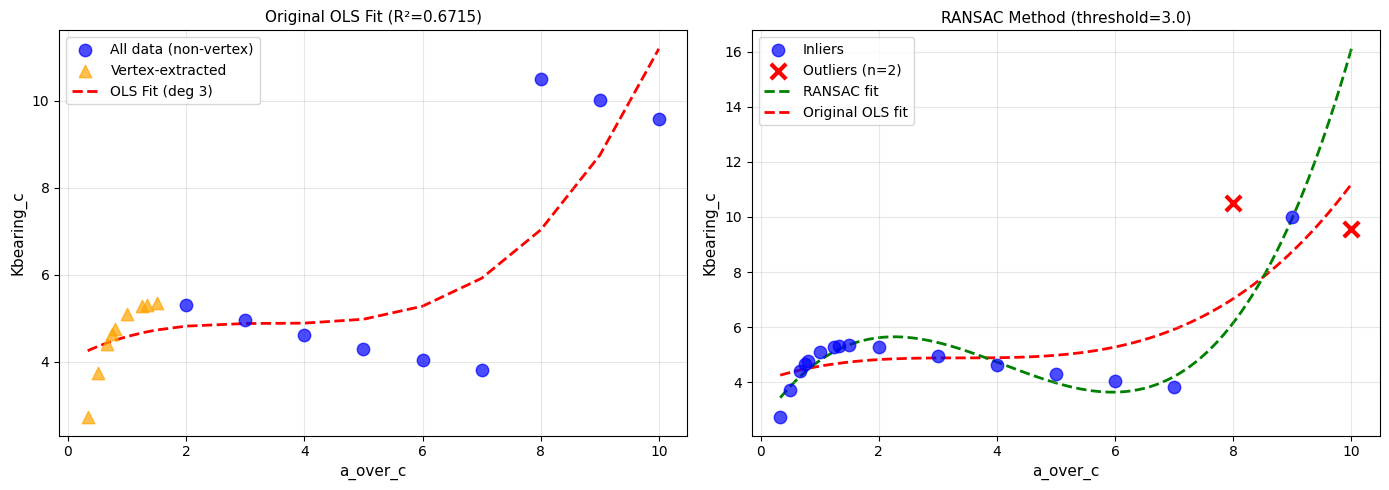


WORST FIT #2 - RANSAC Outlier Detection Results
Curve Index: 960
Point indices: [ 9145  9203  9272  9367  9483  9609  9739  9871 10013 10159 10307 10458
 10628 10810 10997 11184 11374 11564 11753 11942]
Free parameter: a_over_c
Fixed parameters: w_over_r=2.400, a_over_t=0.100, R_over_t=0.571
K-target: Kbearing_c_data
Polynomial degree: 3
R² = 0.6783
Number of points: 20

--- RANSAC Method ---
Fit Coefficients: [3.4882e-02, -4.4934e-01, 1.8291e+00, 2.8149e+00]
RANSAC Coefficients: [8.8229e-02, -1.1242e+00, 3.8556e+00, 1.7594e+00]
Outliers detected: 2
Outlier indices: [17, 19]
Residuals at outliers: ['4.3224', '6.8756']


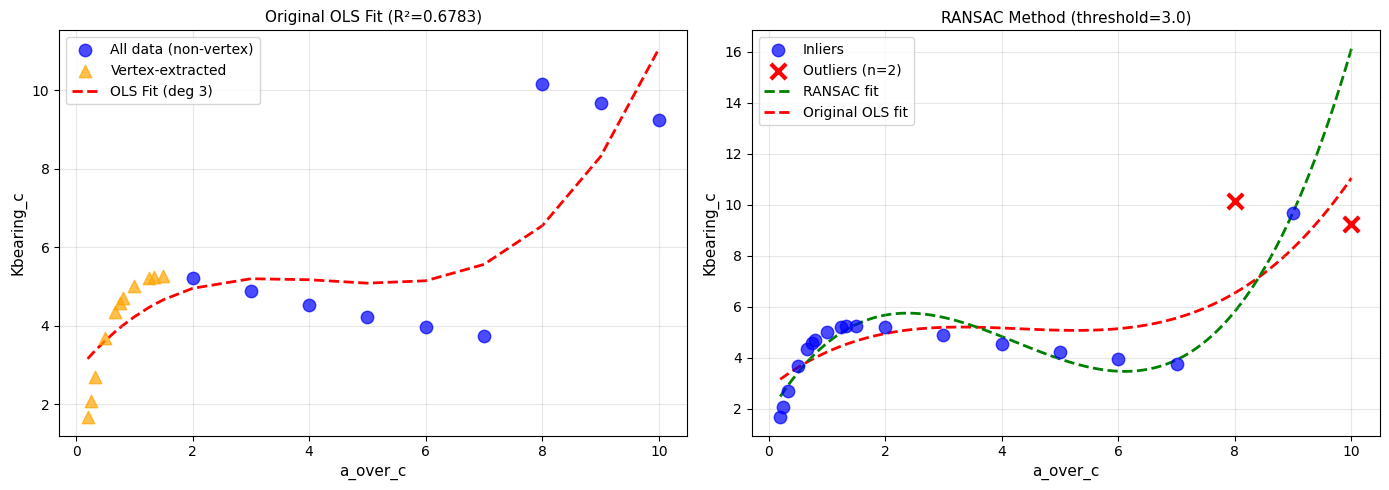


WORST FIT #3 - RANSAC Outlier Detection Results
Curve Index: 468
Point indices: [ 9270  9365  9481  9607  9737  9869 10011 10157 10305 10456 10626 10808
 10995 11182 11372 11562 11751 11940]
Free parameter: a_over_c
Fixed parameters: w_over_r=2.000, a_over_t=0.100, R_over_t=0.571
K-target: Kbearing_c_data
Polynomial degree: 3
R² = 0.6793
Number of points: 18

--- RANSAC Method ---
Fit Coefficients: [2.2823e-02, -2.2961e-01, 7.8433e-01, 4.1497e+00]
RANSAC Coefficients: [8.4247e-02, -1.0372e+00, 3.4043e+00, 2.4941e+00]
Outliers detected: 2
Outlier indices: [15, 17]
Residuals at outliers: ['4.6270', '6.9254']


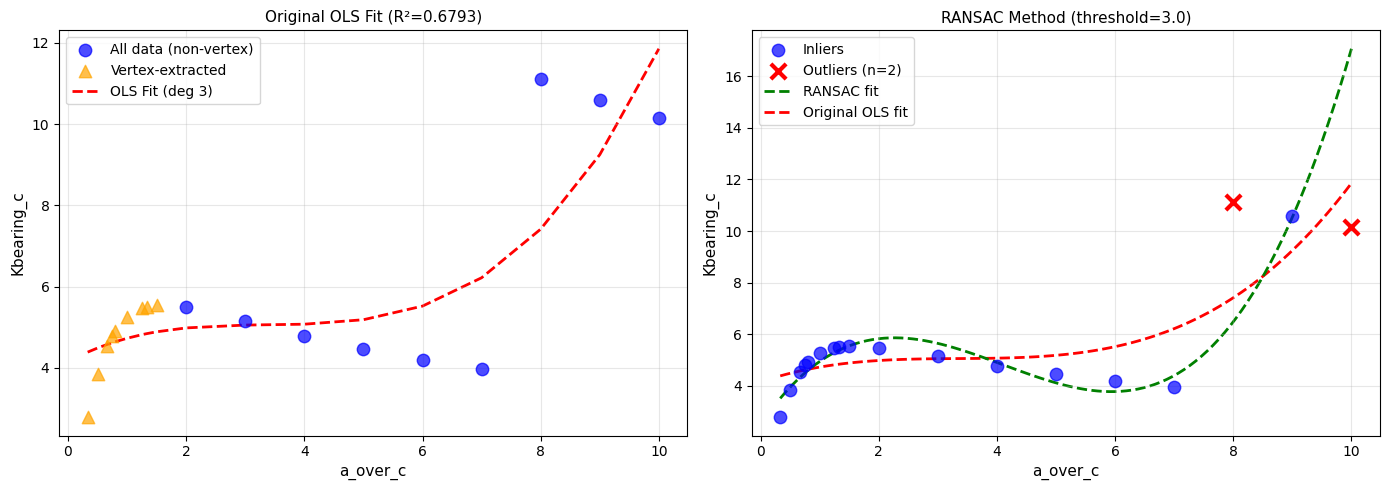


WORST FIT #4 - RANSAC Outlier Detection Results
Curve Index: 234
Point indices: [ 9269  9364  9480  9606  9736  9868 10010 10156 10304 10455 10625 10807
 10994 11181 11371 11561 11750 11939]
Free parameter: a_over_c
Fixed parameters: w_over_r=1.800, a_over_t=0.100, R_over_t=0.571
K-target: Kbearing_c_data
Polynomial degree: 3
R² = 0.6874
Number of points: 18

--- RANSAC Method ---
Fit Coefficients: [2.5188e-02, -2.5479e-01, 8.9456e-01, 4.3293e+00]
RANSAC Coefficients: [9.2990e-02, -1.1461e+00, 3.7862e+00, 2.5020e+00]
Outliers detected: 2
Outlier indices: [15, 17]
Residuals at outliers: ['5.1011', '7.6492']


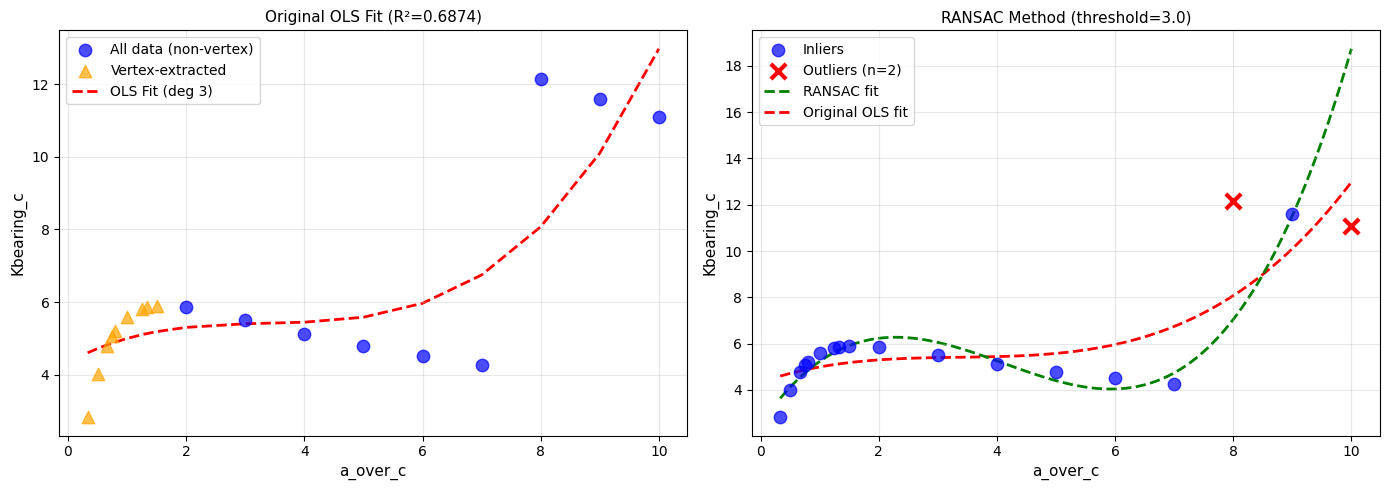


WORST FIT #5 - RANSAC Outlier Detection Results
Curve Index: 1214
Point indices: [ 9050  9095  9146  9204  9273  9368  9484  9610  9740  9872 10014 10160
 10308 10459 10629 10811 10998 11185 11375 11565 11754 11943]
Free parameter: a_over_c
Fixed parameters: w_over_r=2.800, a_over_t=0.100, R_over_t=0.571
K-target: Kbearing_c_data
Polynomial degree: 3
R² = 0.7037
Number of points: 22

--- RANSAC Method ---
Fit Coefficients: [4.3300e-02, -5.9736e-01, 2.5178e+00, 2.1252e+00]
RANSAC Coefficients: [6.0369e-02, -8.4436e-01, 3.2789e+00, 1.7796e+00]
Outliers detected: 1
Outlier indices: [19]
Residuals at outliers: ['4.9510']


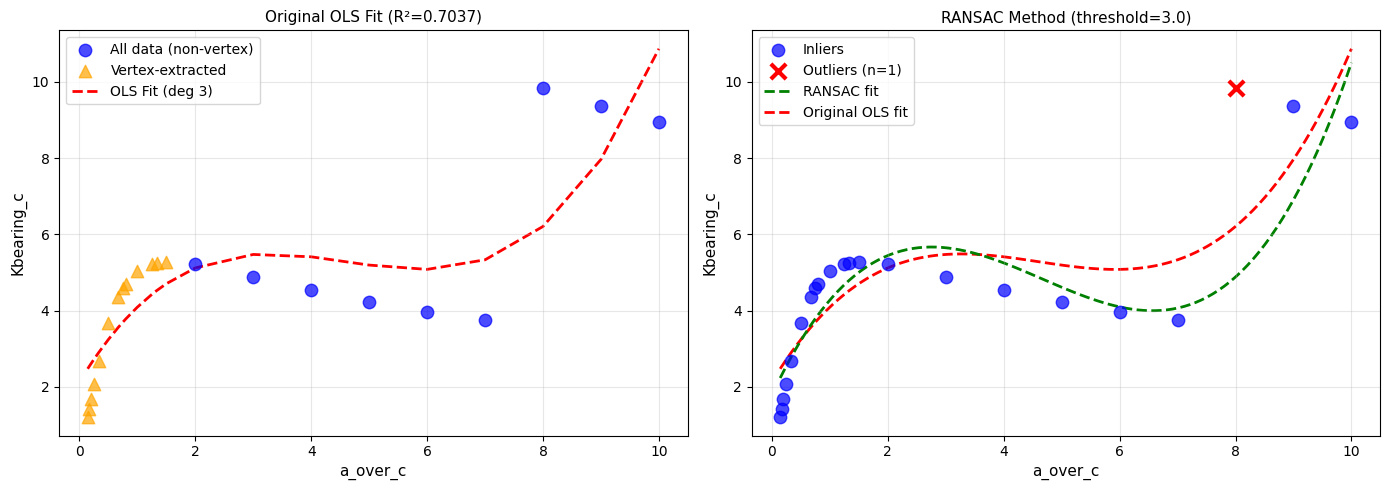


WORST FIT #6 - RANSAC Outlier Detection Results
Curve Index: 10
Point indices: [ 9363  9479  9605  9735  9867 10009 10155 10303 10454 10624 10806 10993
 11180 11370 11560 11749 11938]
Free parameter: a_over_c
Fixed parameters: w_over_r=1.600, a_over_t=0.100, R_over_t=0.571
K-target: Kbearing_c_data
Polynomial degree: 3
R² = 0.7052
Number of points: 17

--- RANSAC Method ---
Fit Coefficients: [1.8465e-02, -1.1324e-01, 2.0308e-01, 5.6832e+00]
RANSAC Coefficients: [6.4075e-02, -8.4224e-01, 2.9315e+00, 3.7000e+00]
Outliers detected: 2
Outlier indices: [14, 15]
Residuals at outliers: ['8.0052', '4.8376']


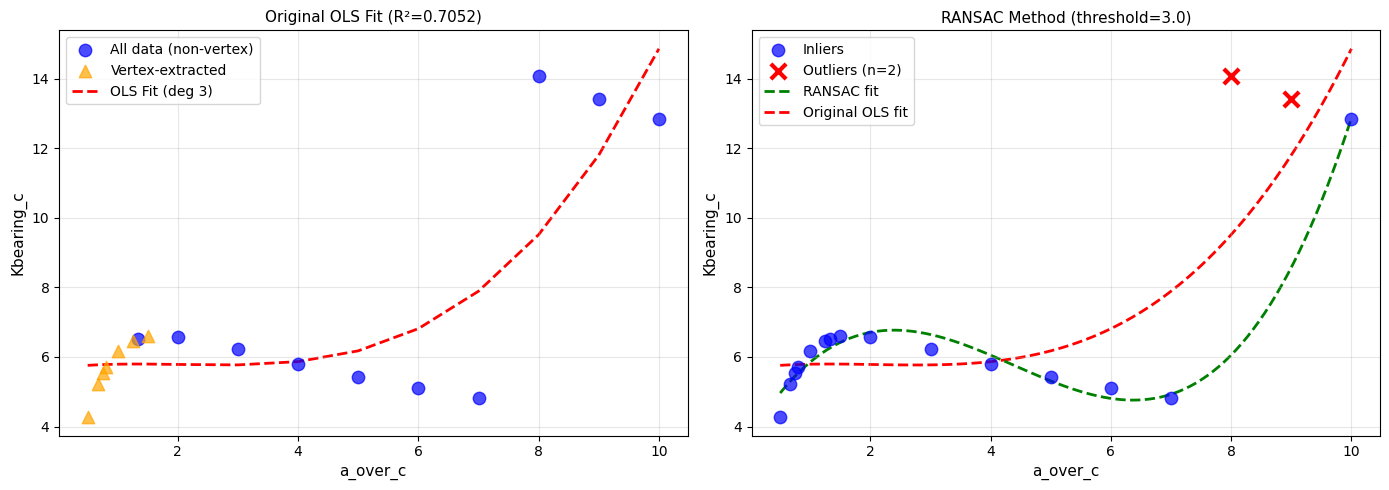


WORST FIT #7 - RANSAC Outlier Detection Results
Curve Index: 2251
Point indices: [85862 86013 86169 86330 86497 86669 86840 87013]
Free parameter: a_over_c
Fixed parameters: w_over_r=4.000, a_over_t=0.950, R_over_t=0.200
K-target: Kbearing_c_data
Polynomial degree: 3
R² = 0.9688
Number of points: 8

--- RANSAC Method ---
Fit Coefficients: [-1.0631e-02, 2.3773e-01, -1.7197e+00, 1.4238e+01]
RANSAC Coefficients: [-4.1667e-03, 9.6428e-02, -7.3155e-01, 1.2044e+01]
Outliers detected: 1
Outlier indices: [0]
Residuals at outliers: ['0.3657']


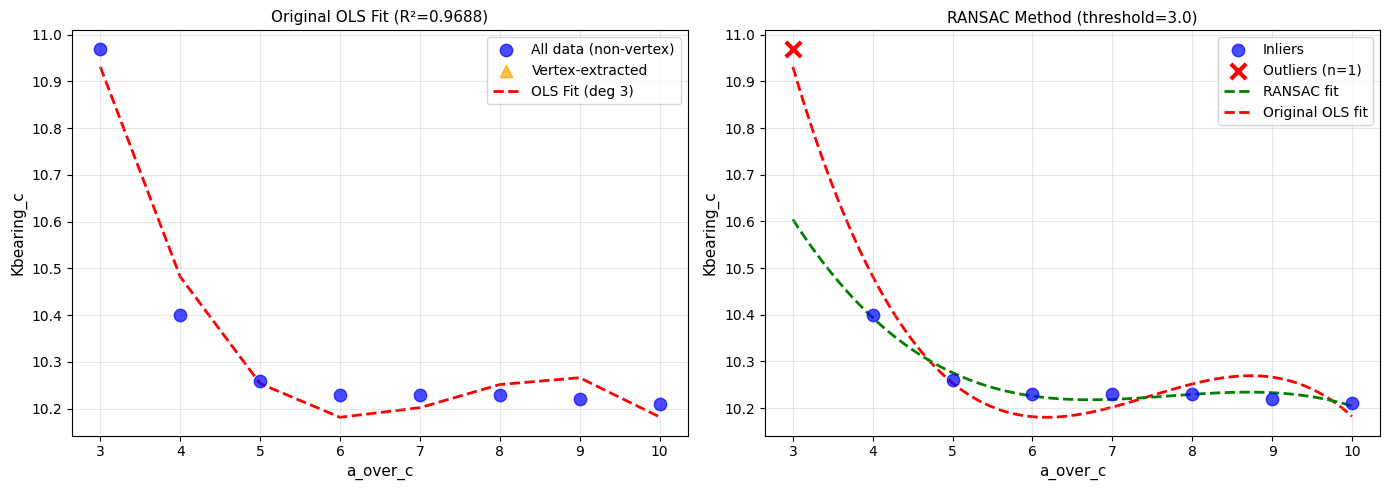


WORST FIT #8 - RANSAC Outlier Detection Results
Curve Index: 687
Point indices: [20858 21043 21232 21422 21612 21802 21986 22176 22366 22556]
Free parameter: a_over_c
Fixed parameters: w_over_r=2.000, a_over_t=0.950, R_over_t=1.000
K-target: Kbearing_a_data
Polynomial degree: 3
R² = 0.9834
Number of points: 10

--- RANSAC Method ---
Fit Coefficients: [-3.9728e-02, 8.5982e-01, -5.9598e+00, 1.2101e+01]
RANSAC Coefficients: [-5.2273e-02, 1.0428e+00, -6.7304e+00, 1.2982e+01]
Outliers detected: 1
Outlier indices: [9]
Residuals at outliers: ['1.2773']


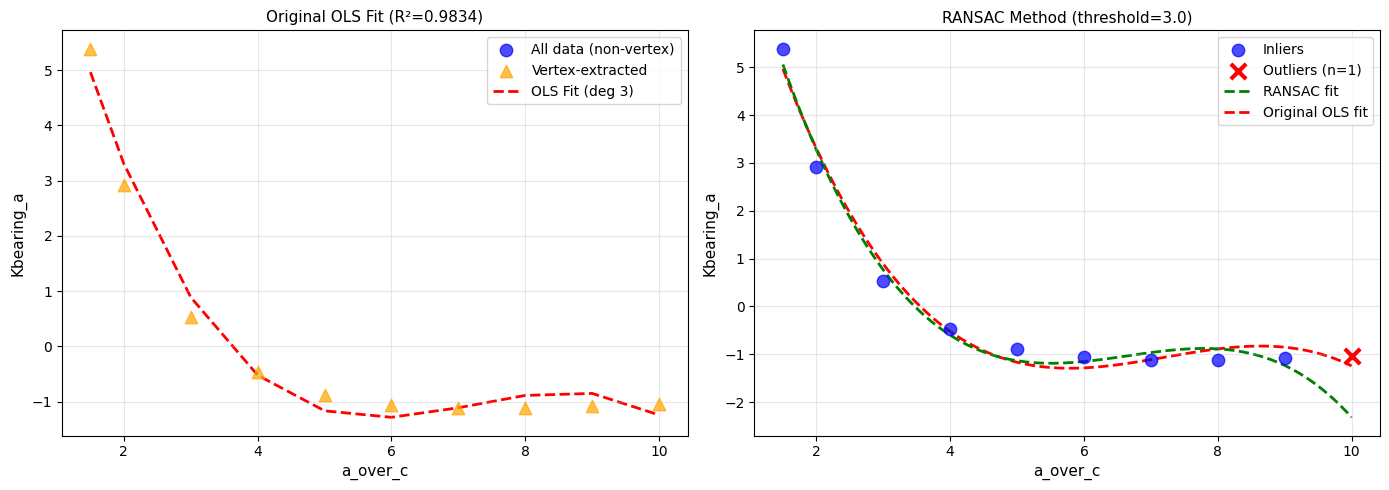


WORST FIT #9 - RANSAC Outlier Detection Results
Curve Index: 2793
Point indices: [90182 90303 90425 90549 90699 90864 91037 91214 91395 91578 91765 91952
 92140]
Free parameter: a_over_c
Fixed parameters: w_over_r=5.200, a_over_t=0.950, R_over_t=0.333
K-target: Kbearing_c_data
Polynomial degree: 3
R² = 0.2958
Number of points: 13

--- RANSAC Method ---
Fit Coefficients: [-1.1753e-02, 1.9318e-01, -8.5386e-01, 1.1809e+01]
RANSAC Coefficients: [-4.5352e-03, 6.0918e-02, -1.3714e-01, 1.0742e+01]
Outliers detected: 1
Outlier indices: [0]
Residuals at outliers: ['1.2989']


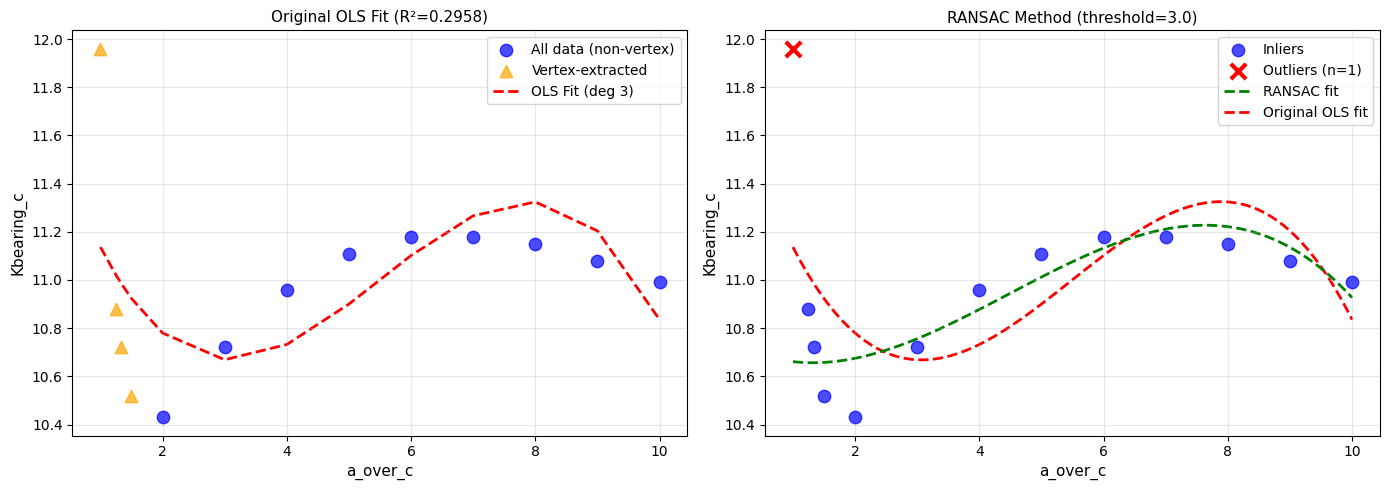


WORST FIT #10 - RANSAC Outlier Detection Results
Curve Index: 2766
Point indices: [90173 90293 90415 90538 90686 90849 91021 91197 91379 91561 91747 91934
 92122]
Free parameter: a_over_c
Fixed parameters: w_over_r=5.200, a_over_t=0.900, R_over_t=0.333
K-target: Kbearing_c_data
Polynomial degree: 3
R² = 0.4035
Number of points: 13

--- RANSAC Method ---
Fit Coefficients: [-7.7999e-03, 1.1742e-01, -4.2765e-01, 1.1102e+01]
RANSAC Coefficients: [-7.7999e-03, 1.1742e-01, -4.2765e-01, 1.1102e+01]
Outliers detected: 0


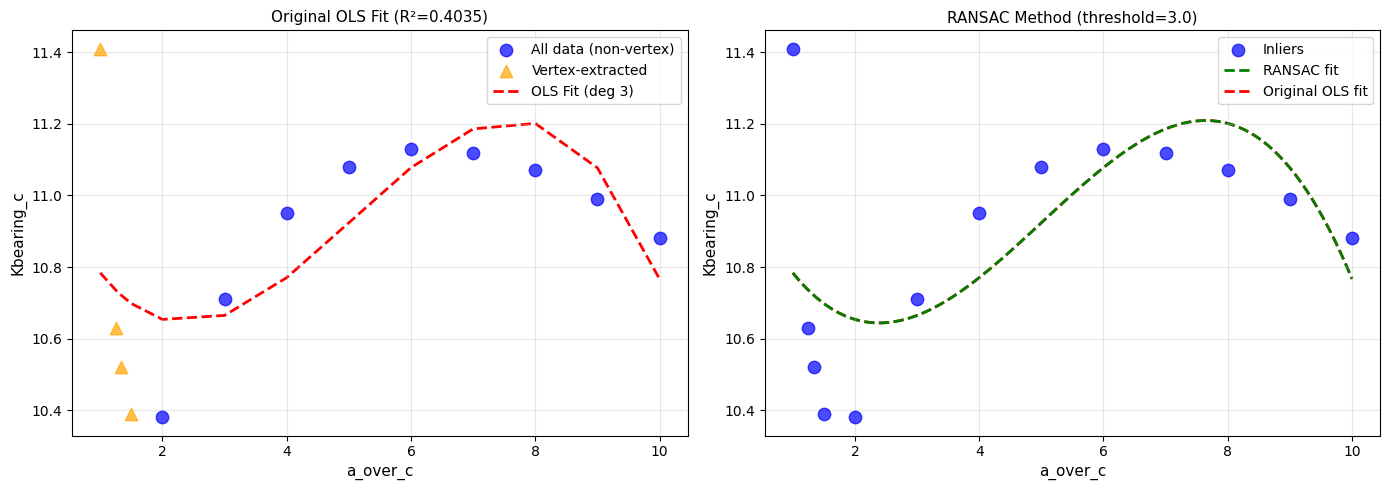


RANSAC outlier detection testing complete on 10 worst fits.


In [49]:
# Test outlier detection on the 10 worst fits from reduction_dicts
print("=== Testing RANSAC Outlier Detection on 10 Worst Fits ===\n")

# Find the worst 10 fits
fit_rankings = []

for curve_idx, d in enumerate(reduction_dicts):
    if "simple_fit_results" not in d:
        continue
    
    for k_target, fit_result in d["simple_fit_results"].items():
        k_target_vertex_flag = k_target + "_vertex_flag"
        n_outliers = 0
        if 'outlier_detection' in fit_result:
            n_outliers = fit_result['outlier_detection']['n_outliers']

        if fit_result['n_points'] >= 4 and fit_result['best_r2'] is not None:
            fit_rankings.append({
                'curve_idx': curve_idx,
                'k_target': k_target,
                'r2': fit_result['best_r2'],
                'rmse': fit_result['best_rmse'],
                'degree': fit_result['best_degree'],
                'is_bad': fit_result['is_bad_fit'],
                'n_outliers': n_outliers
            })

# Sort by R² (ascending - worst first)
# fit_rankings.sort(key=lambda x: x['r2'])
# fit_rankings.sort(key=lambda x: (x['r2'], -x['n_outliers']))
fit_rankings.sort(key=lambda x: (-x['n_outliers'], x['r2']))

print(f"Found {len(fit_rankings)} fits to rank")
print(f"Testing RANSAC outlier detection on worst 10...\n")

# Test on the worst 10
num_to_test = min(10, len(fit_rankings))

for test_idx in range(num_to_test):
    try:
        worst_fit = fit_rankings[test_idx]
        curve_idx = worst_fit['curve_idx']
        k_target = worst_fit['k_target']
        
        d = reduction_dicts[curve_idx]
        data_block = d["data"]
        fit_result = d["simple_fit_results"][k_target]
        
        # Get data
        x = np.array(data_block["free_param_data"])
        y = np.array(data_block[k_target])
        # Use all_params_all_K_vertex_flagged to figure out if each point was a vertex extraction or not
        # Remove "_data" from k_target to get the base name
        k_target_vertex_flag = k_target.replace("data", "vertex_flag")
        vertex_flags = data_block[k_target_vertex_flag]
        
        # Clean data
        valid_mask = np.isfinite(x) & np.isfinite(y)
        x_clean = x[valid_mask]
        y_clean = y[valid_mask]
        vertex_flags_clean = vertex_flags[valid_mask]
        
        # Sort for consistency
        sort_idx = np.argsort(x_clean)
        x_sorted = x_clean[sort_idx]
        y_sorted = y_clean[sort_idx]
        vertex_flags_sorted = vertex_flags_clean[sort_idx]

        poly_degree = fit_result['best_degree']
        
        # Run RANSAC outlier detection
        outlier_ransac = detect_polynomial_outliers(x_sorted, y_sorted, poly_degree, method='ransac', threshold=3.0)
        
        # # Get RANSAC outliers from stored results if available
        # if 'outlier_detection' in fit_result:
        #     outlier_ransac = fit_result['outlier_detection']
        # else:
        #     print(f"No stored outlier detection for curve {curve_idx}, running RANSAC now...")
        #     outlier_ransac = detect_polynomial_outliers(x_sorted, y_sorted, poly_degree, method='ransac', threshold=2.0)

        # Print results
        print(f"\n{'='*80}")
        print(f"WORST FIT #{test_idx+1} - RANSAC Outlier Detection Results")
        print(f"{'='*80}")
        print(f"Curve Index: {curve_idx}")
        point_indices = d["data_index"][valid_mask][sort_idx]
        print(f"Point indices: {point_indices}")

        print(f"Free parameter: {d['free_param_name']}")
        
        # Print fixed parameters
        all_params = ["w_over_r", "a_over_c", "a_over_t", "R_over_t"]
        print("Fixed parameters:", end=" ")
        fixed_params = []
        for param in all_params:
            if param in d and param != d["free_param_name"]:
                fixed_params.append(f"{param}={d[param]:.3f}")
        print(", ".join(fixed_params))
        
        print(f"K-target: {k_target}")
        print(f"Polynomial degree: {poly_degree}")
        print(f"R² = {fit_result['best_r2']:.4f}")
        print(f"Number of points: {fit_result['n_points']}")
        
        print(f"\n--- RANSAC Method ---")
        # print fit polynomial coefficients
        if fit_result['coeffs'] is not None:
            coeffs_fit = fit_result['coeffs']
            coeffs_str = ", ".join([f"{c:.4e}" for c in coeffs_fit])
            print(f"Fit Coefficients: [{coeffs_str}]")
        # print ransac polynomial coefficients
        if outlier_ransac['coeffs'] is not None:
            coeffs_ransac = outlier_ransac['coeffs']
            coeffs_str = ", ".join([f"{c:.4e}" for c in coeffs_ransac])
            print(f"RANSAC Coefficients: [{coeffs_str}]")
        print(f"Outliers detected: {outlier_ransac['n_outliers']}")
        if outlier_ransac['n_outliers'] > 0:
            print(f"Outlier indices: {outlier_ransac['outlier_indices']}")
            outlier_scores = [outlier_ransac['scores'][i] for i in outlier_ransac['outlier_indices']]
            print(f"Residuals at outliers: {[f'{score:.4f}' for score in outlier_scores]}")
        
        # Create visualization
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Original fit (no outlier removal)
        ax0 = axes[0]
        # Plot distinct point shapes for vertex-extracted points if available, using k_target_vertex_flag
        if vertex_flags_sorted is not None:
            vertex_mask = vertex_flags_sorted.astype(bool)
            non_vertex_mask = ~vertex_mask
            ax0.scatter(x_sorted[non_vertex_mask], y_sorted[non_vertex_mask], 
                    c='blue', s=80, alpha=0.7, label='All data (non-vertex)', zorder=2)
            ax0.scatter(x_sorted[vertex_mask], y_sorted[vertex_mask], 
                    c='orange', s=80, alpha=0.7, marker='^', label='Vertex-extracted', zorder=2)
        else:
            ax0.scatter(x_sorted, y_sorted, c='blue', s=80, alpha=0.7, label='All data', zorder=2)

        if fit_result['y_pred'] is not None:
            ax0.plot(x_sorted, fit_result['y_pred'], 'r--', linewidth=2, 
                    label=f"OLS Fit (deg {poly_degree})", zorder=1)
        ax0.set_xlabel(d["free_param_name"], fontsize=11)
        ax0.set_ylabel(k_target.replace('_data', ''), fontsize=11)
        ax0.set_title(f"Original OLS Fit (R²={fit_result['best_r2']:.4f})", fontsize=11)
        ax0.legend()
        ax0.grid(True, alpha=0.3)
        
        # RANSAC method
        ax1 = axes[1]
        outlier_mask_ransac = outlier_ransac['outlier_mask']
        if outlier_mask_ransac is None:
            outlier_mask_ransac = np.zeros_like(x_sorted, dtype=bool)
        inlier_mask_ransac = ~outlier_mask_ransac
        
        ax1.scatter(x_sorted[inlier_mask_ransac], y_sorted[inlier_mask_ransac], 
                c='blue', s=80, alpha=0.7, label='Inliers', zorder=2)
        if outlier_ransac['n_outliers'] > 0:
            ax1.scatter(x_sorted[outlier_mask_ransac], y_sorted[outlier_mask_ransac], 
                    c='red', s=120, marker='x', linewidths=3, 
                    label=f'Outliers (n={outlier_ransac["n_outliers"]})', zorder=3)
        
        # Plot RANSAC fit using the coefficients from RANSAC
        if outlier_ransac['coeffs'] is not None:
            coeffs_ransac = np.array(outlier_ransac['coeffs'])
            x_fit = np.linspace(x_sorted.min(), x_sorted.max(), 100)
            # remove the second to last entry from coeffs_ransac if degree
            # if len(coeffs_ransac) > 2:
            #     coeffs_ransac = np.delete(coeffs_ransac, -2)
            y_fit_ransac = np.polyval(coeffs_ransac, x_fit)
            ax1.plot(x_fit, y_fit_ransac, 'g--', linewidth=2, label='RANSAC fit', zorder=1)

            # Plot the original fit from coefficients, for comparison
        if fit_result['coeffs'] is not None:
            coeffs_fit = np.array(fit_result['coeffs'])
            y_fit_ols = np.polyval(coeffs_fit, x_fit)
            ax1.plot(x_fit, y_fit_ols, 'r--', linewidth=2, label='Original OLS fit', zorder=0)
        
        ax1.set_xlabel(d["free_param_name"], fontsize=11)
        ax1.set_ylabel(k_target.replace('_data', ''), fontsize=11)
        ax1.set_title(f"RANSAC Method (threshold={outlier_ransac['threshold_used']:.1f})", fontsize=11)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error processing worst fit #{test_idx+1}: {str(e)}, skipping...")
        continue

print(f"\n{'='*80}")
print(f"RANSAC outlier detection testing complete on {num_to_test} worst fits.")
print(f"{'='*80}")

=== Testing Outlier Detection on 10 Worst Fits ===

Found 2000 fits to rank
Testing outlier detection on worst 10...


WORST FIT #1 - Outlier Detection Results
Curve Index: 236
Free parameter: a_over_c
Fixed parameters: w_over_r=1.800, a_over_t=0.100, R_over_t=0.800
K-target: Kbearing_c_data
Polynomial degree: 5
R² = 0.8046
Number of points: 18

--- MAD Method ---
Outliers detected: 1
Outlier indices: [15]
Modified z-scores at outliers: ['-3.78']

--- Cook's Distance Method ---
Outliers detected: 0
Threshold used (4/n): 0.2222


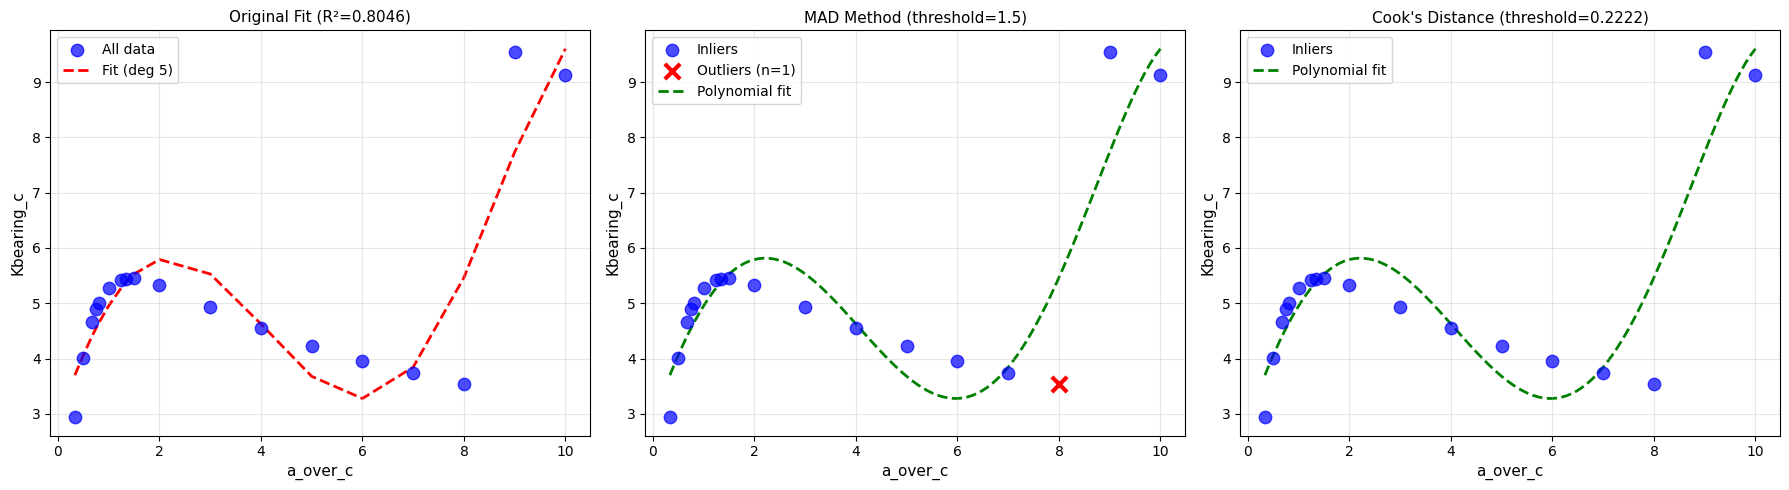


WORST FIT #2 - Outlier Detection Results
Curve Index: 12
Free parameter: a_over_c
Fixed parameters: w_over_r=1.600, a_over_t=0.100, R_over_t=0.800
K-target: Kbearing_c_data
Polynomial degree: 5
R² = 0.8107
Number of points: 18

--- MAD Method ---
Outliers detected: 1
Outlier indices: [15]
Modified z-scores at outliers: ['-3.78']

--- Cook's Distance Method ---
Outliers detected: 0
Threshold used (4/n): 0.2222


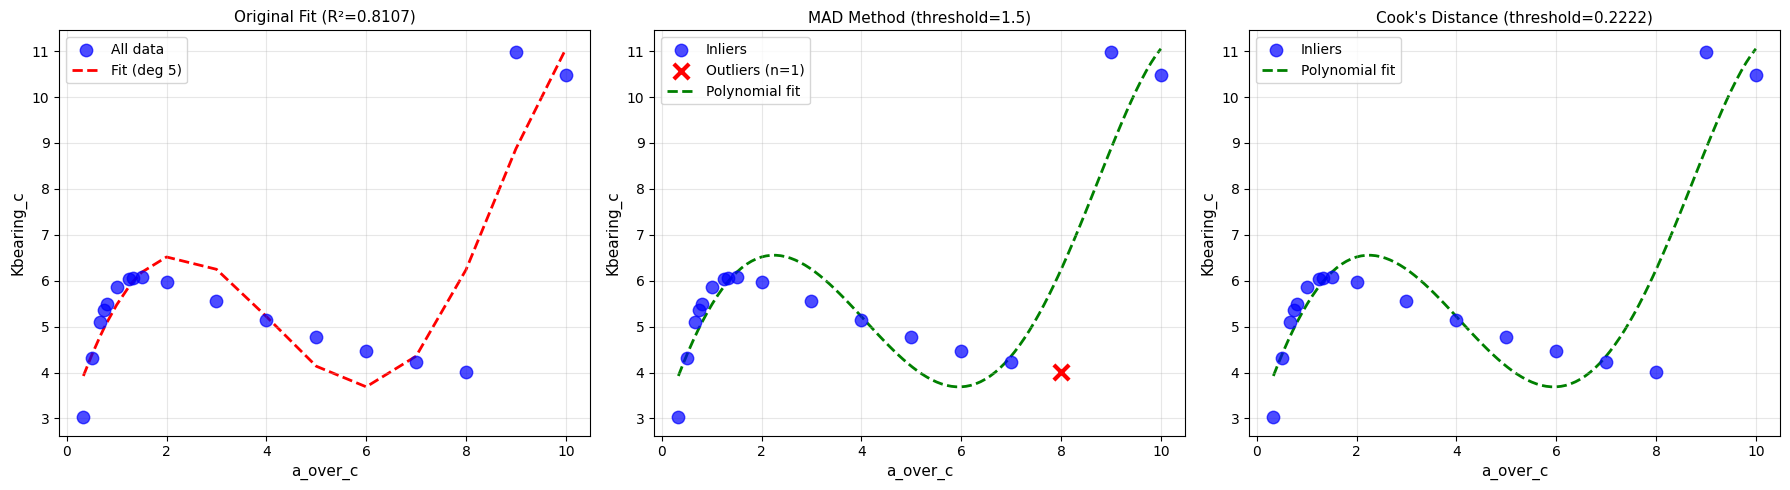


WORST FIT #3 - Outlier Detection Results
Curve Index: 880
Free parameter: a_over_c
Fixed parameters: w_over_r=2.200, a_over_t=0.700, R_over_t=10.000
K-target: Kbearing_c_data
Polynomial degree: 5
R² = 0.8269
Number of points: 25

--- MAD Method ---
Outliers detected: 0

--- Cook's Distance Method ---
Outliers detected: 0
Threshold used (4/n): 0.1600


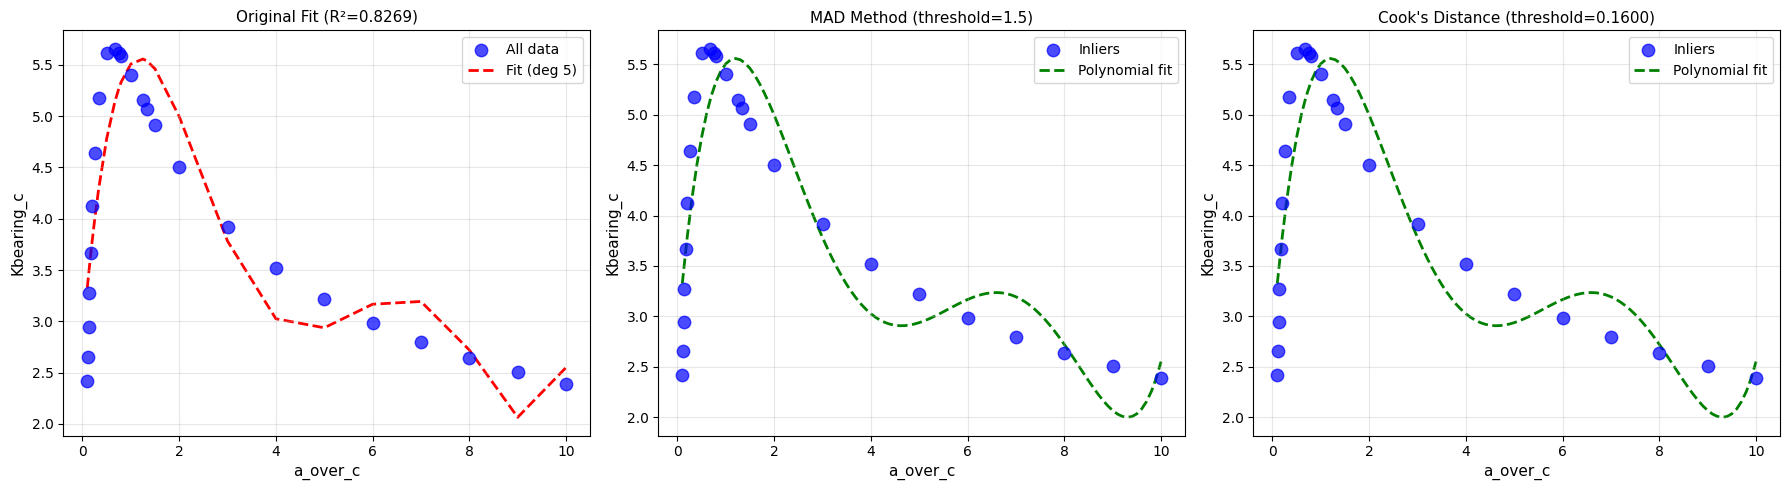


WORST FIT #4 - Outlier Detection Results
Curve Index: 470
Free parameter: a_over_c
Fixed parameters: w_over_r=2.000, a_over_t=0.100, R_over_t=0.800
K-target: Kbearing_c_data
Polynomial degree: 4
R² = 0.8275
Number of points: 20

--- MAD Method ---
Outliers detected: 2
Outlier indices: [17, 18]
Modified z-scores at outliers: ['-2.61', '2.73']

--- Cook's Distance Method ---
Outliers detected: 0
Threshold used (4/n): 0.2000


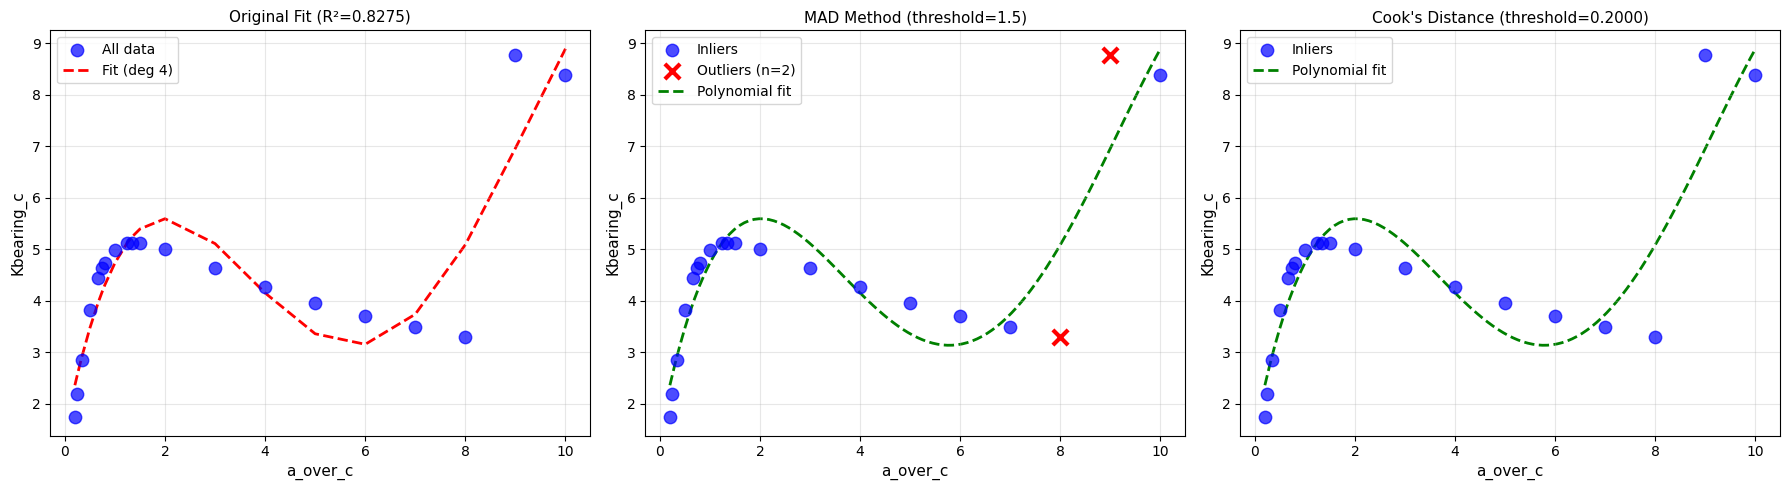


WORST FIT #5 - Outlier Detection Results
Curve Index: 633
Free parameter: a_over_c
Fixed parameters: w_over_r=2.000, a_over_t=0.700, R_over_t=10.000
K-target: Kbearing_c_data
Polynomial degree: 5
R² = 0.8301
Number of points: 25

--- MAD Method ---
Outliers detected: 0

--- Cook's Distance Method ---
Outliers detected: 0
Threshold used (4/n): 0.1600


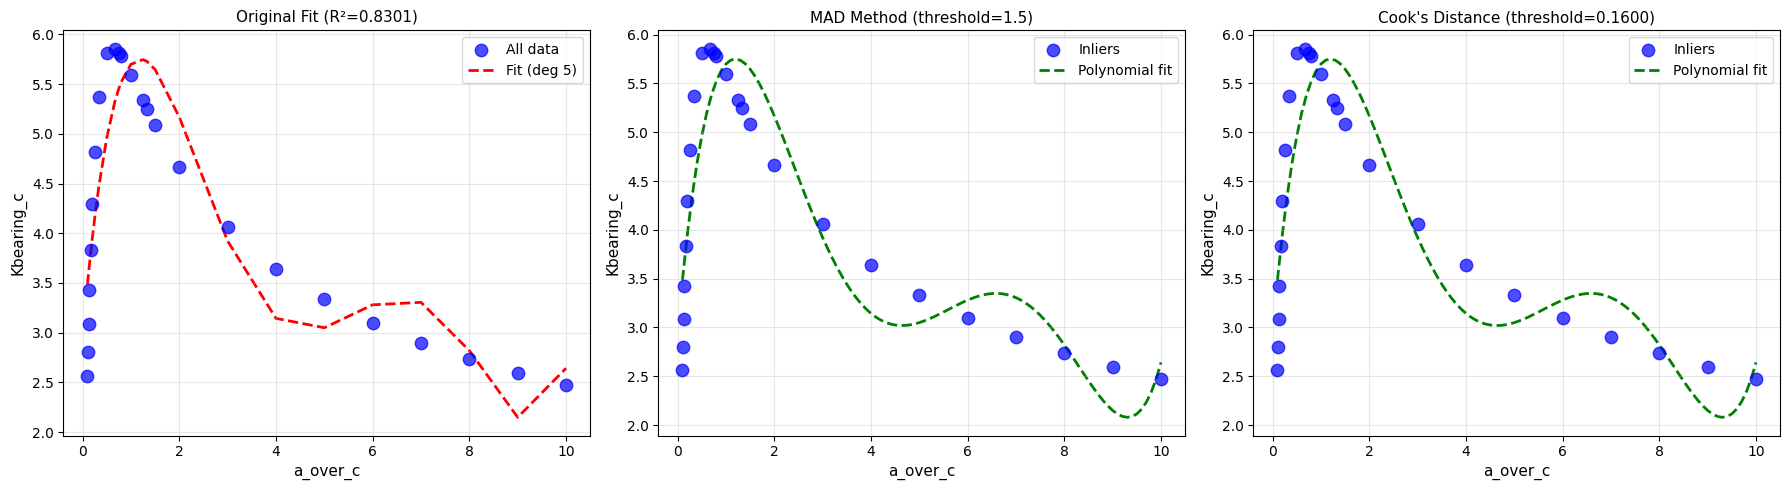


WORST FIT #6 - Outlier Detection Results
Curve Index: 856
Free parameter: a_over_c
Fixed parameters: w_over_r=2.200, a_over_t=0.600, R_over_t=10.000
K-target: Kbearing_c_data
Polynomial degree: 5
R² = 0.8364
Number of points: 25

--- MAD Method ---
Outliers detected: 0

--- Cook's Distance Method ---
Outliers detected: 0
Threshold used (4/n): 0.1600


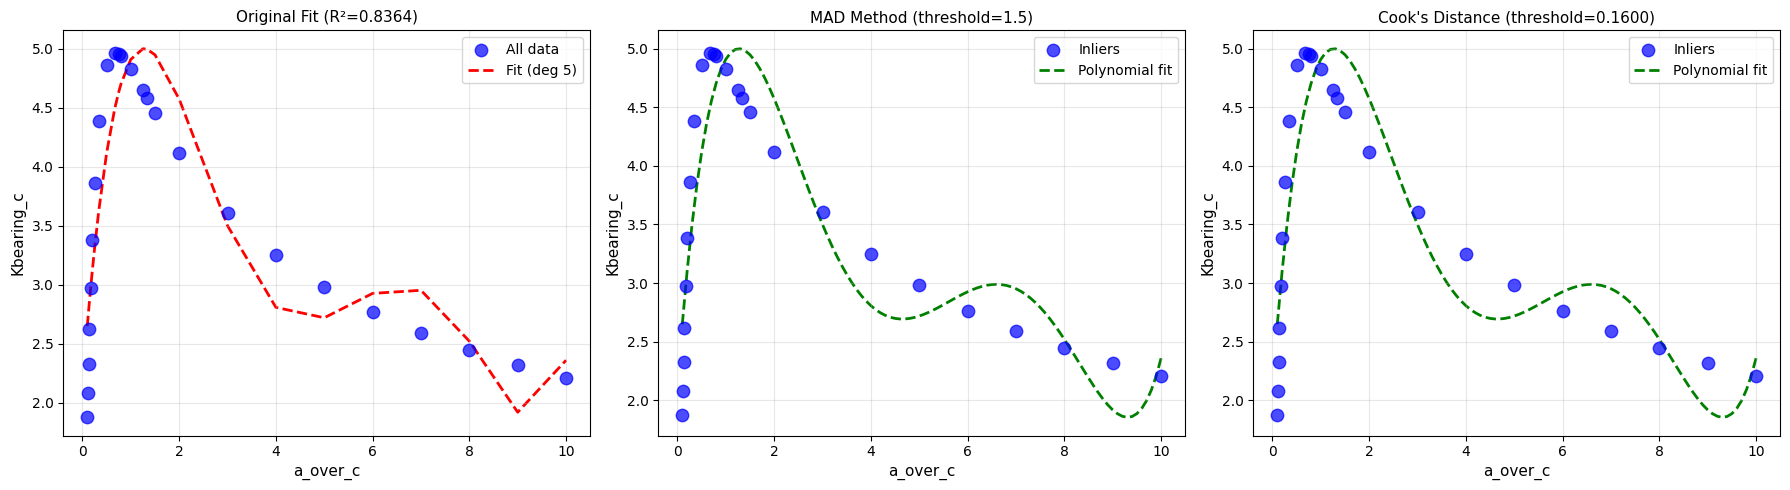


WORST FIT #7 - Outlier Detection Results
Curve Index: 610
Free parameter: a_over_c
Fixed parameters: w_over_r=2.000, a_over_t=0.600, R_over_t=10.000
K-target: Kbearing_c_data
Polynomial degree: 5
R² = 0.8371
Number of points: 25

--- MAD Method ---
Outliers detected: 0

--- Cook's Distance Method ---
Outliers detected: 0
Threshold used (4/n): 0.1600


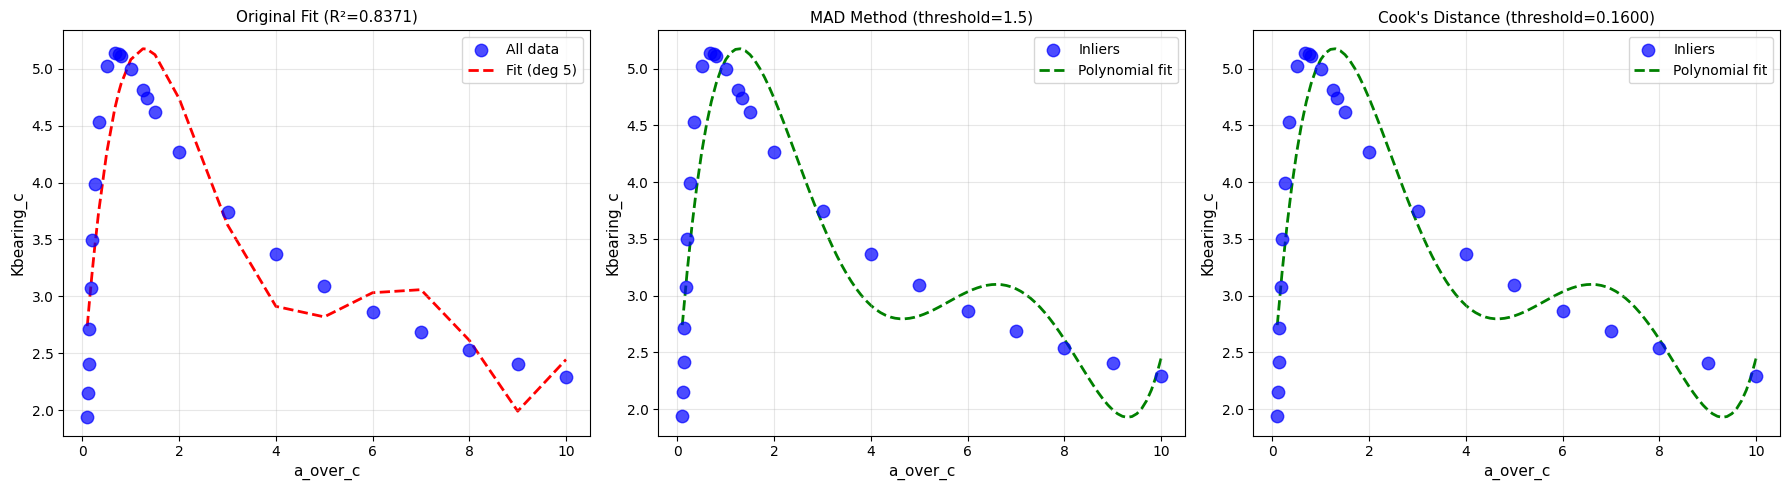


WORST FIT #8 - Outlier Detection Results
Curve Index: 958
Free parameter: a_over_c
Fixed parameters: w_over_r=2.400, a_over_t=0.100, R_over_t=0.444
K-target: Kbearing_c_data
Polynomial degree: 5
R² = 0.8379
Number of points: 18

--- MAD Method ---
Outliers detected: 1
Outlier indices: [15]
Modified z-scores at outliers: ['-5.21']

--- Cook's Distance Method ---
Outliers detected: 0
Threshold used (4/n): 0.2222


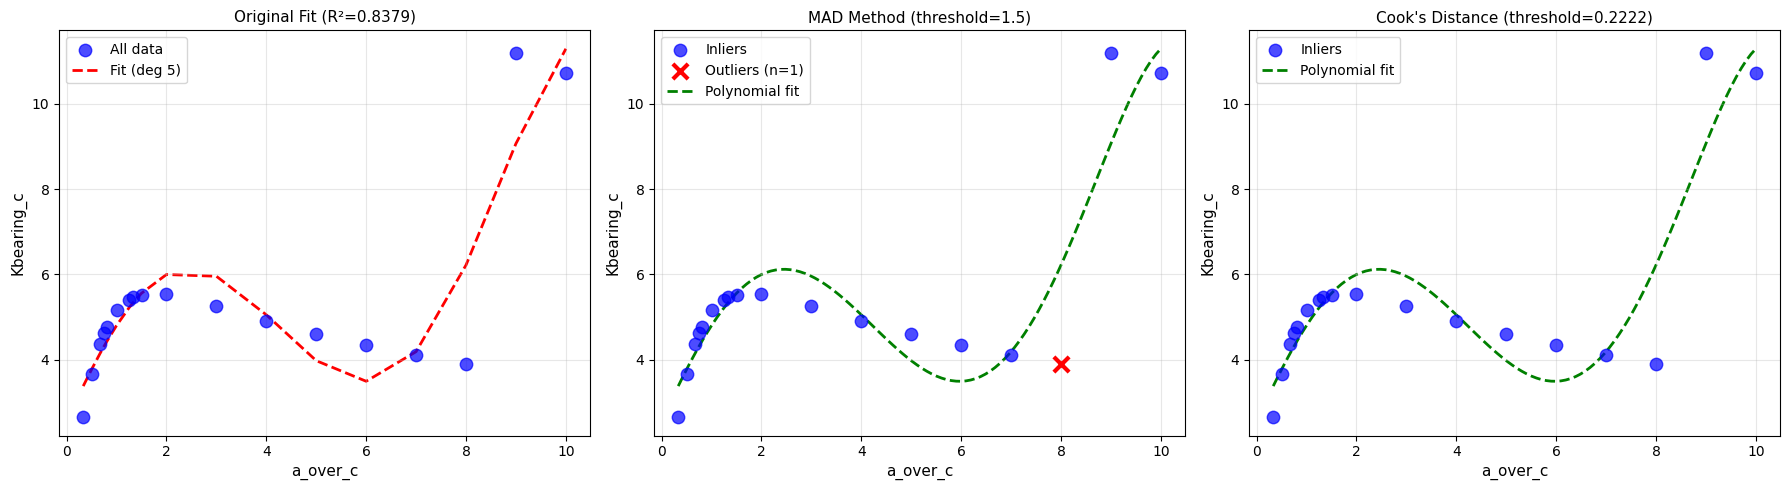


WORST FIT #9 - Outlier Detection Results
Curve Index: 709
Free parameter: a_over_c
Fixed parameters: w_over_r=2.200, a_over_t=0.100, R_over_t=0.444
K-target: Kbearing_c_data
Polynomial degree: 5
R² = 0.8392
Number of points: 18

--- MAD Method ---
Outliers detected: 1
Outlier indices: [15]
Modified z-scores at outliers: ['-5.30']

--- Cook's Distance Method ---
Outliers detected: 0
Threshold used (4/n): 0.2222


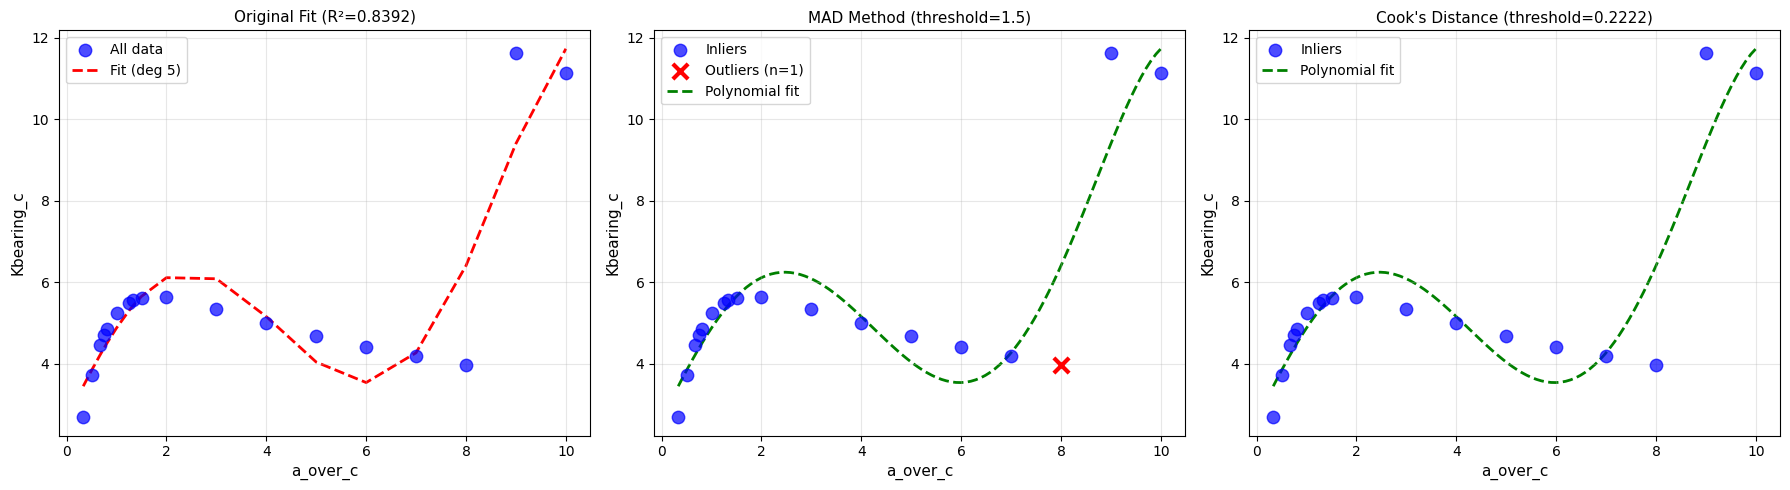


WORST FIT #10 - Outlier Detection Results
Curve Index: 879
Free parameter: a_over_c
Fixed parameters: w_over_r=2.200, a_over_t=0.700, R_over_t=8.000
K-target: Kbearing_c_data
Polynomial degree: 5
R² = 0.8396
Number of points: 25

--- MAD Method ---
Outliers detected: 0

--- Cook's Distance Method ---
Outliers detected: 0
Threshold used (4/n): 0.1600


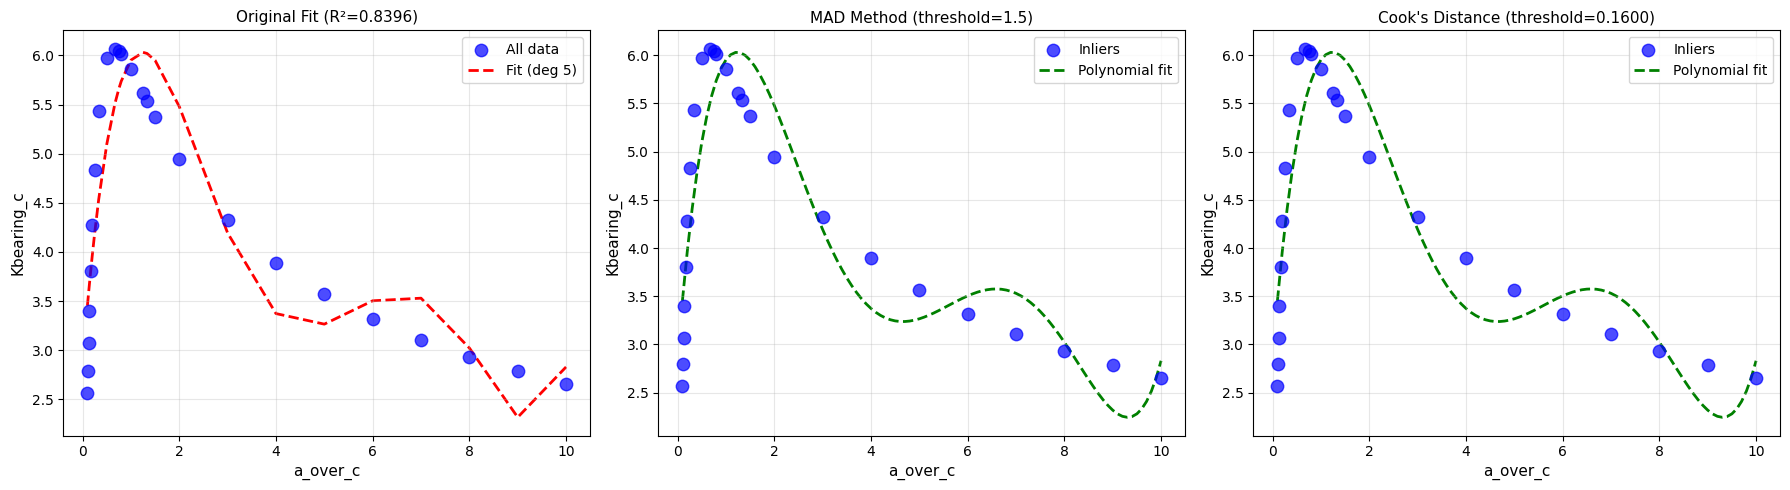


WORST FIT #11 - Outlier Detection Results
Curve Index: 903
Free parameter: a_over_c
Fixed parameters: w_over_r=2.200, a_over_t=0.800, R_over_t=10.000
K-target: Kbearing_c_data
Polynomial degree: 5
R² = 0.8404
Number of points: 25

--- MAD Method ---
Outliers detected: 0

--- Cook's Distance Method ---
Outliers detected: 0
Threshold used (4/n): 0.1600


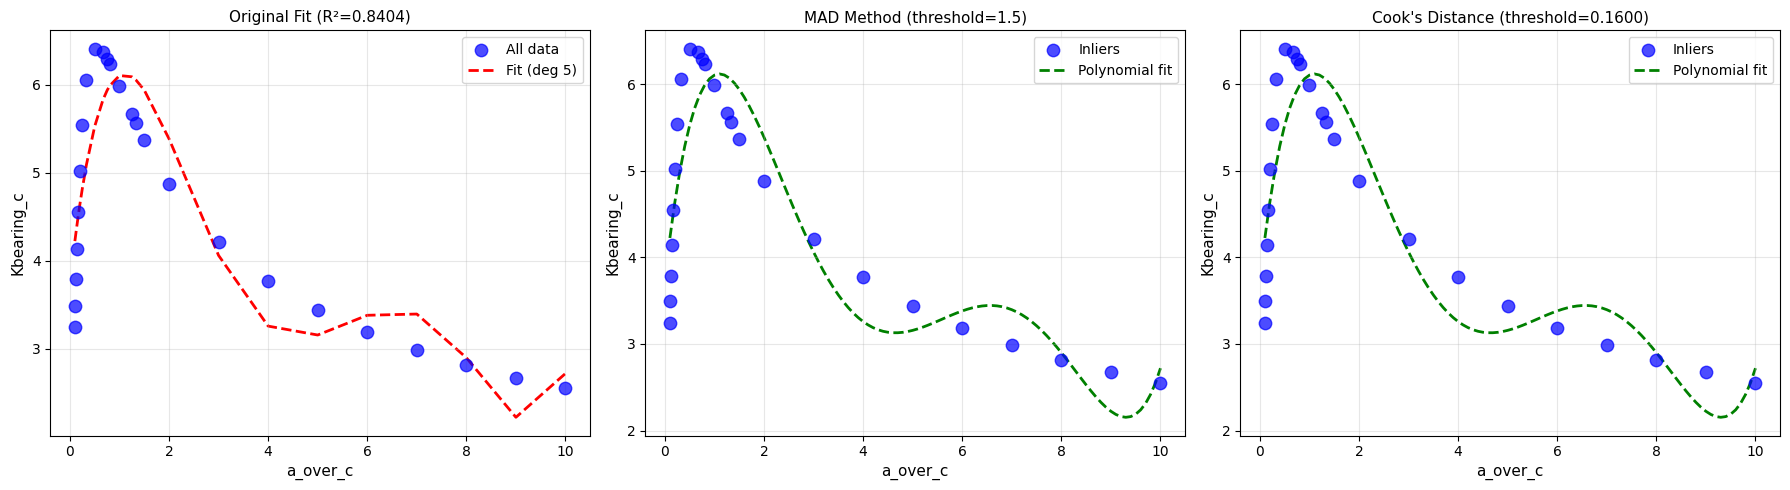


WORST FIT #12 - Outlier Detection Results
Curve Index: 466
Free parameter: a_over_c
Fixed parameters: w_over_r=2.000, a_over_t=0.100, R_over_t=0.444
K-target: Kbearing_c_data
Polynomial degree: 5
R² = 0.8409
Number of points: 18

--- MAD Method ---
Outliers detected: 2
Outlier indices: [13, 15]
Modified z-scores at outliers: ['1.78', '-5.29']

--- Cook's Distance Method ---
Outliers detected: 0
Threshold used (4/n): 0.2222


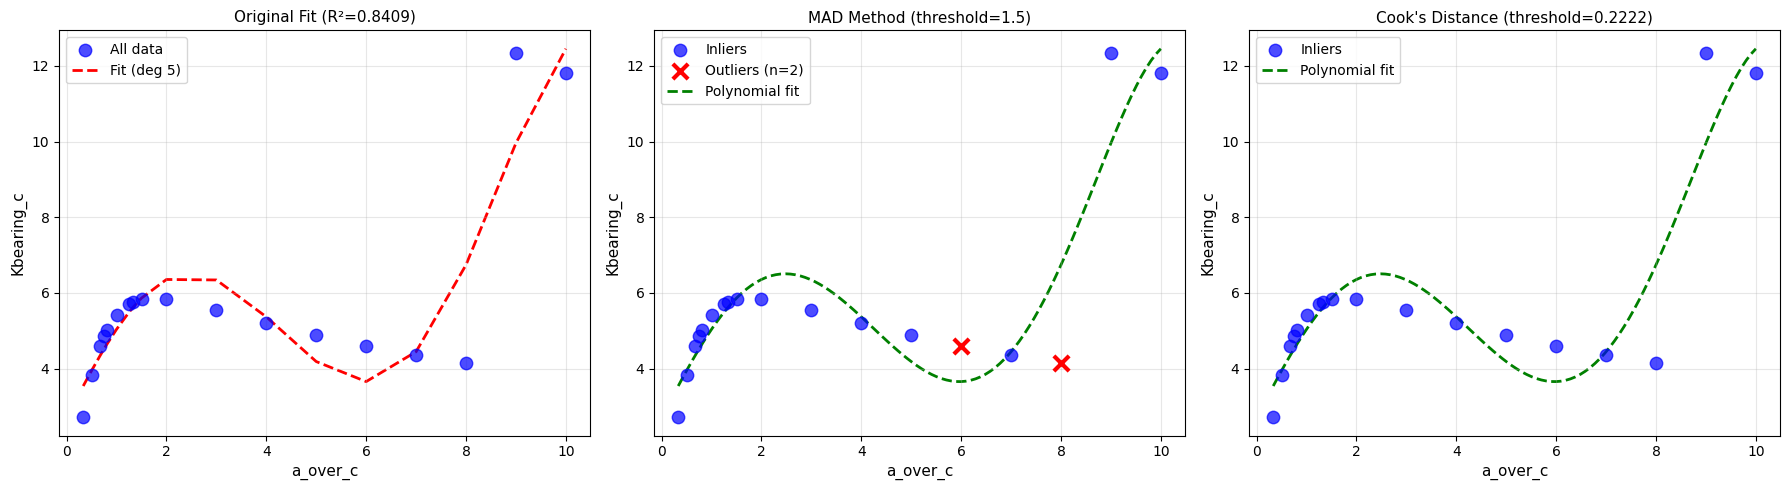


WORST FIT #13 - Outlier Detection Results
Curve Index: 713
Free parameter: a_over_c
Fixed parameters: w_over_r=2.200, a_over_t=0.100, R_over_t=0.800
K-target: Kbearing_c_data
Polynomial degree: 4
R² = 0.8428
Number of points: 21

--- MAD Method ---
Outliers detected: 1
Outlier indices: [18]
Modified z-scores at outliers: ['-2.40']

--- Cook's Distance Method ---
Outliers detected: 0
Threshold used (4/n): 0.1905


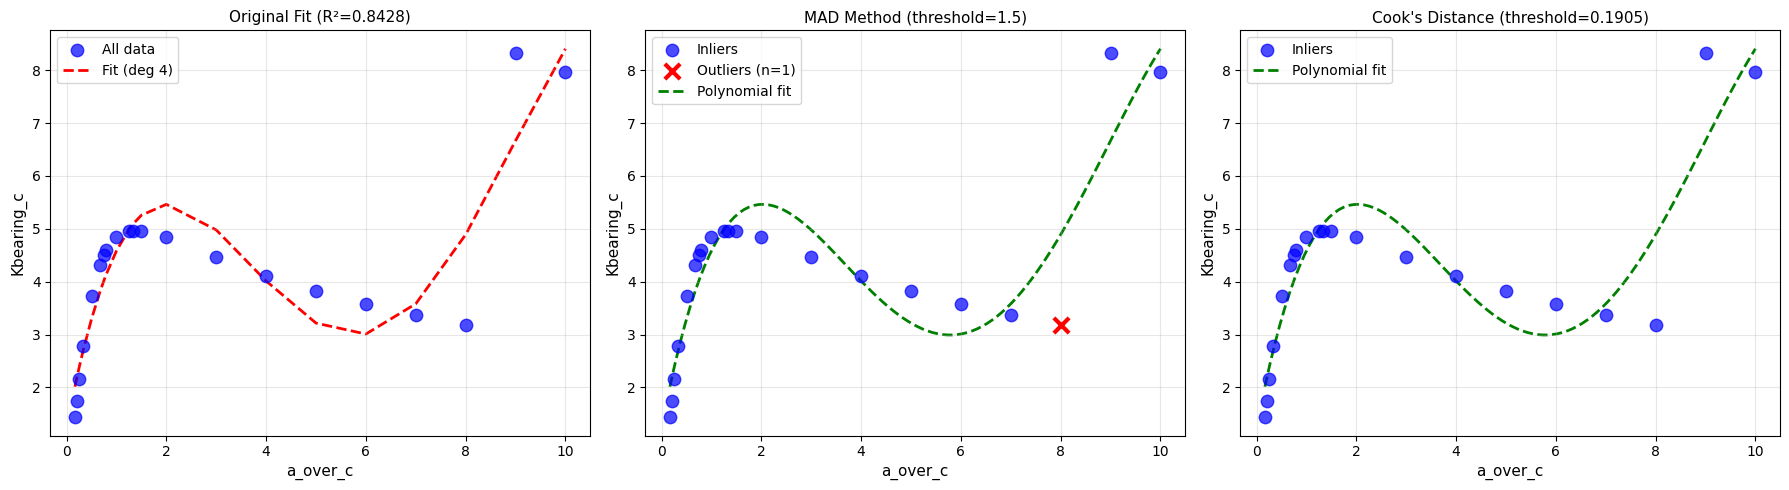


WORST FIT #14 - Outlier Detection Results
Curve Index: 232
Free parameter: a_over_c
Fixed parameters: w_over_r=1.800, a_over_t=0.100, R_over_t=0.444
K-target: Kbearing_c_data
Polynomial degree: 5
R² = 0.8430
Number of points: 17

--- MAD Method ---
Outliers detected: 1
Outlier indices: [14]
Modified z-scores at outliers: ['-4.19']

--- Cook's Distance Method ---
Outliers detected: 0
Threshold used (4/n): 0.2353


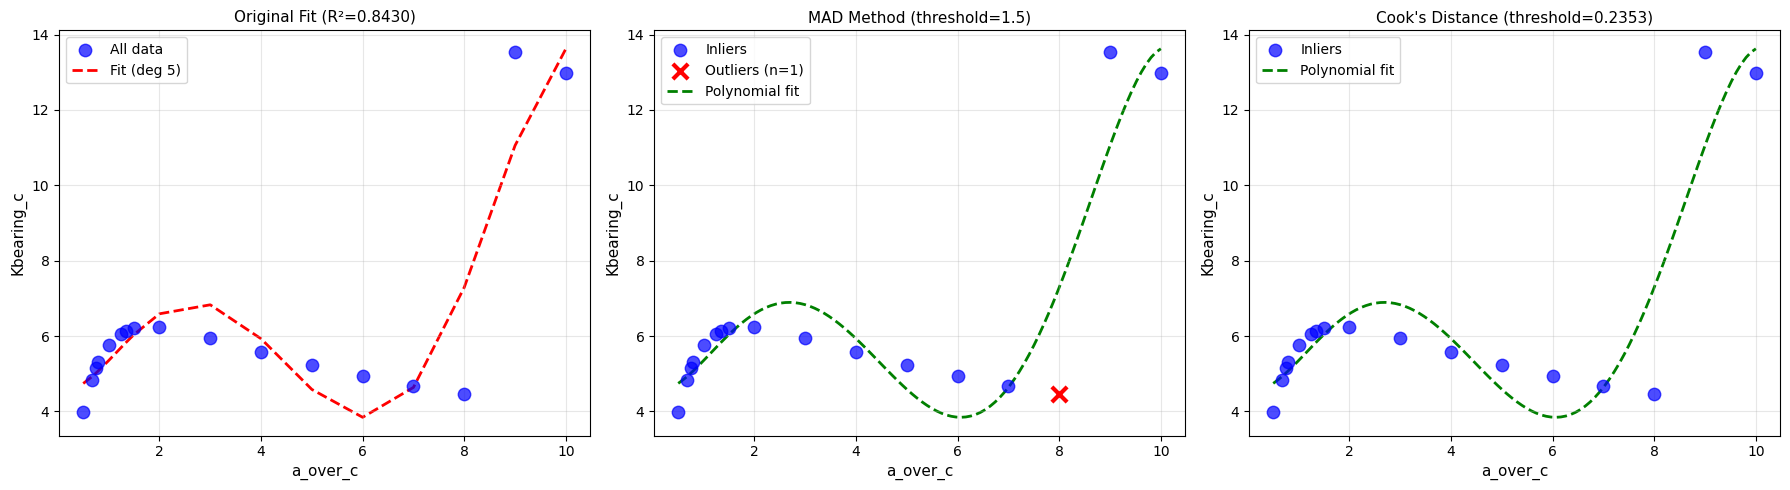


WORST FIT #15 - Outlier Detection Results
Curve Index: 371
Free parameter: a_over_c
Fixed parameters: w_over_r=1.800, a_over_t=0.600, R_over_t=10.000
K-target: Kbearing_c_data
Polynomial degree: 5
R² = 0.8470
Number of points: 24

--- MAD Method ---
Outliers detected: 1
Outlier indices: [0]
Modified z-scores at outliers: ['-1.53']

--- Cook's Distance Method ---
Outliers detected: 0
Threshold used (4/n): 0.1667


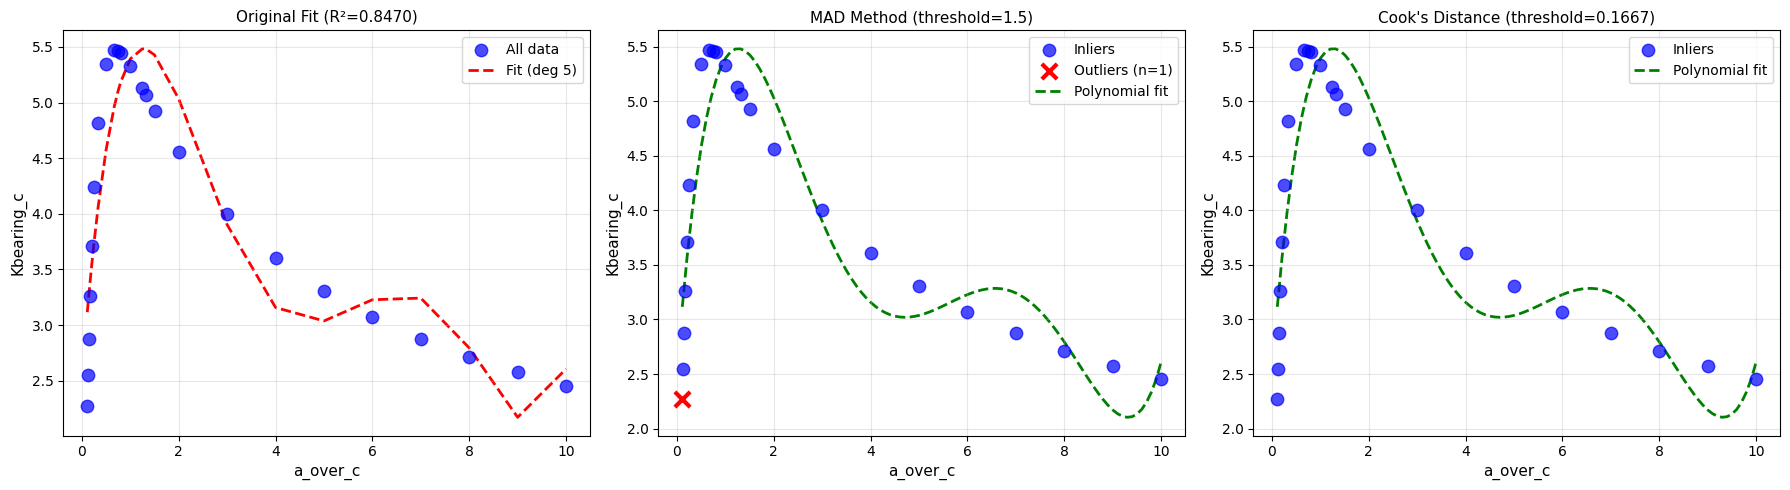


WORST FIT #16 - Outlier Detection Results
Curve Index: 855
Free parameter: a_over_c
Fixed parameters: w_over_r=2.200, a_over_t=0.600, R_over_t=8.000
K-target: Kbearing_c_data
Polynomial degree: 5
R² = 0.8481
Number of points: 25

--- MAD Method ---
Outliers detected: 0

--- Cook's Distance Method ---
Outliers detected: 0
Threshold used (4/n): 0.1600


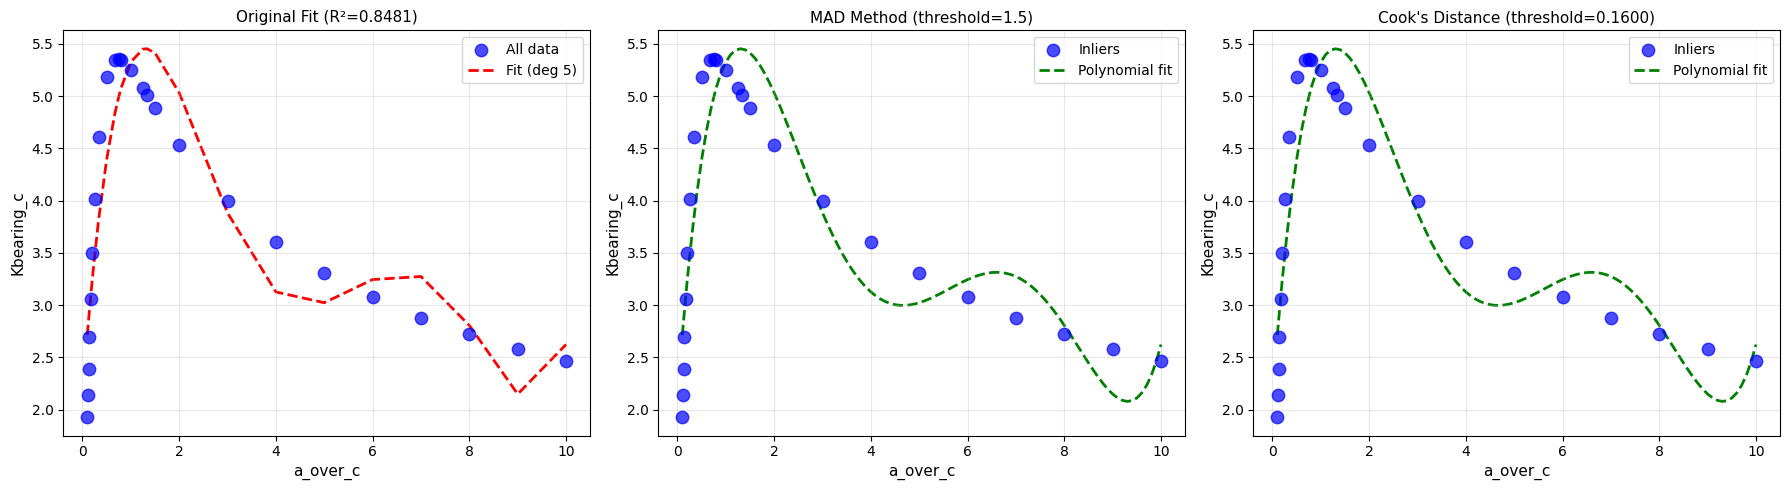


WORST FIT #17 - Outlier Detection Results
Curve Index: 8
Free parameter: a_over_c
Fixed parameters: w_over_r=1.600, a_over_t=0.100, R_over_t=0.444
K-target: Kbearing_c_data
Polynomial degree: 5
R² = 0.8487
Number of points: 16

--- MAD Method ---
Outliers detected: 2
Outlier indices: [11, 13]
Modified z-scores at outliers: ['1.65', '-4.37']

--- Cook's Distance Method ---
Outliers detected: 0
Threshold used (4/n): 0.2500


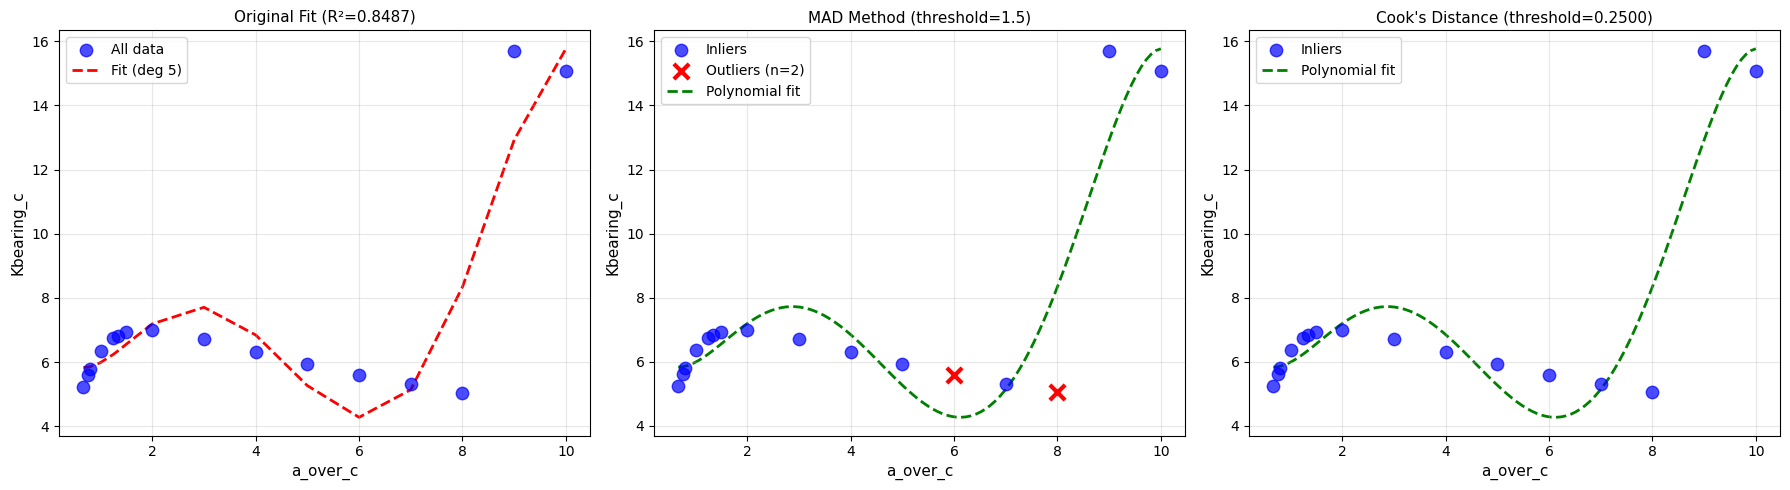


WORST FIT #18 - Outlier Detection Results
Curve Index: 609
Free parameter: a_over_c
Fixed parameters: w_over_r=2.000, a_over_t=0.600, R_over_t=8.000
K-target: Kbearing_c_data
Polynomial degree: 5
R² = 0.8553
Number of points: 24

--- MAD Method ---
Outliers detected: 0

--- Cook's Distance Method ---
Outliers detected: 0
Threshold used (4/n): 0.1667


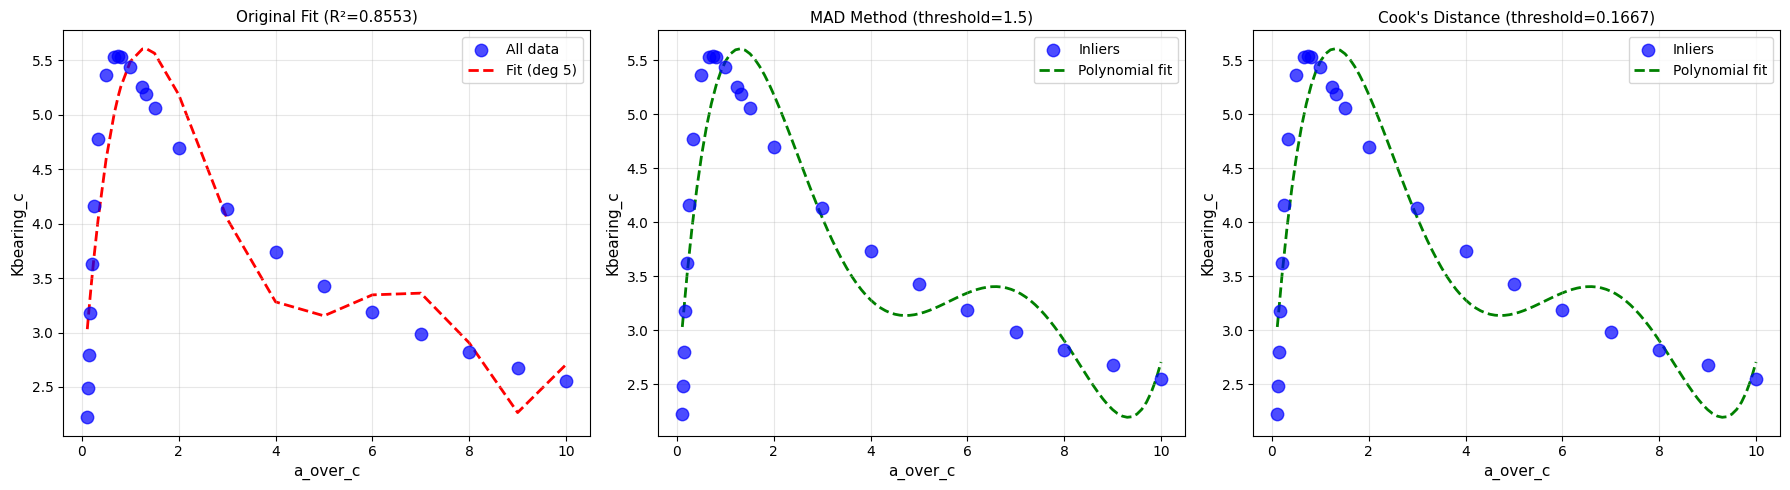


WORST FIT #19 - Outlier Detection Results
Curve Index: 832
Free parameter: a_over_c
Fixed parameters: w_over_r=2.200, a_over_t=0.500, R_over_t=10.000
K-target: Kbearing_c_data
Polynomial degree: 5
R² = 0.8554
Number of points: 25

--- MAD Method ---
Outliers detected: 0

--- Cook's Distance Method ---
Outliers detected: 0
Threshold used (4/n): 0.1600


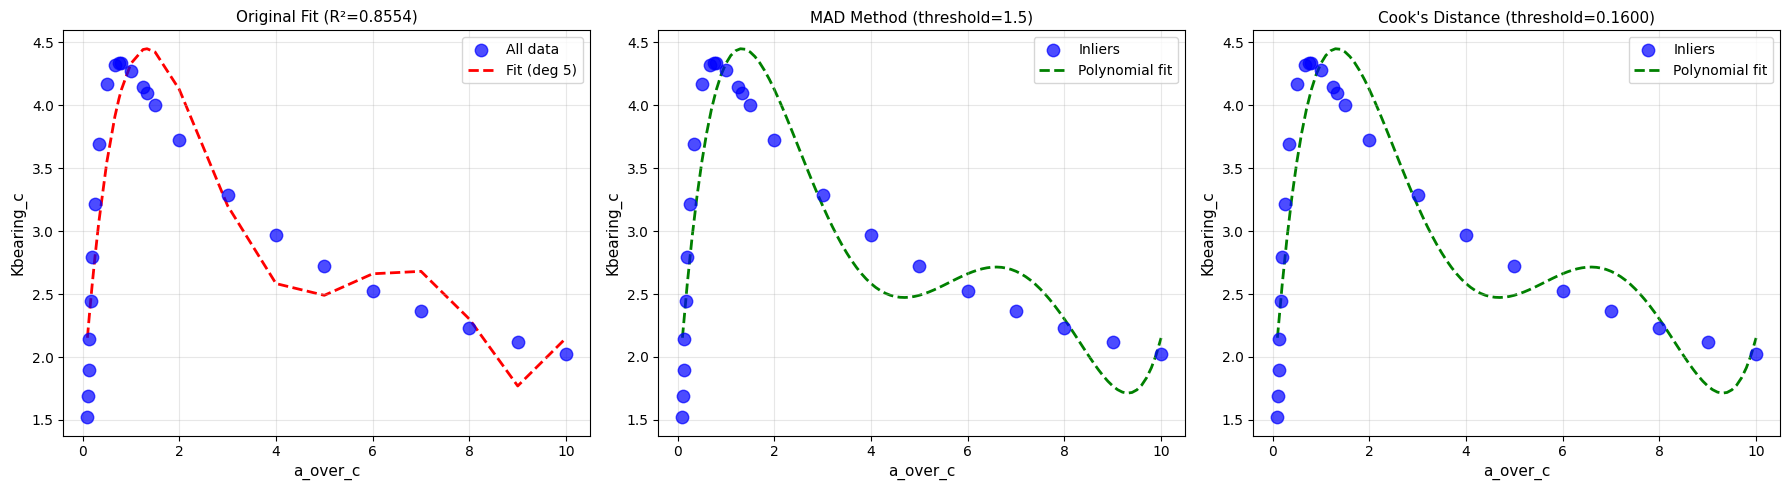


WORST FIT #20 - Outlier Detection Results
Curve Index: 656
Free parameter: a_over_c
Fixed parameters: w_over_r=2.000, a_over_t=0.800, R_over_t=10.000
K-target: Kbearing_c_data
Polynomial degree: 5
R² = 0.8560
Number of points: 25

--- MAD Method ---
Outliers detected: 0

--- Cook's Distance Method ---
Outliers detected: 0
Threshold used (4/n): 0.1600


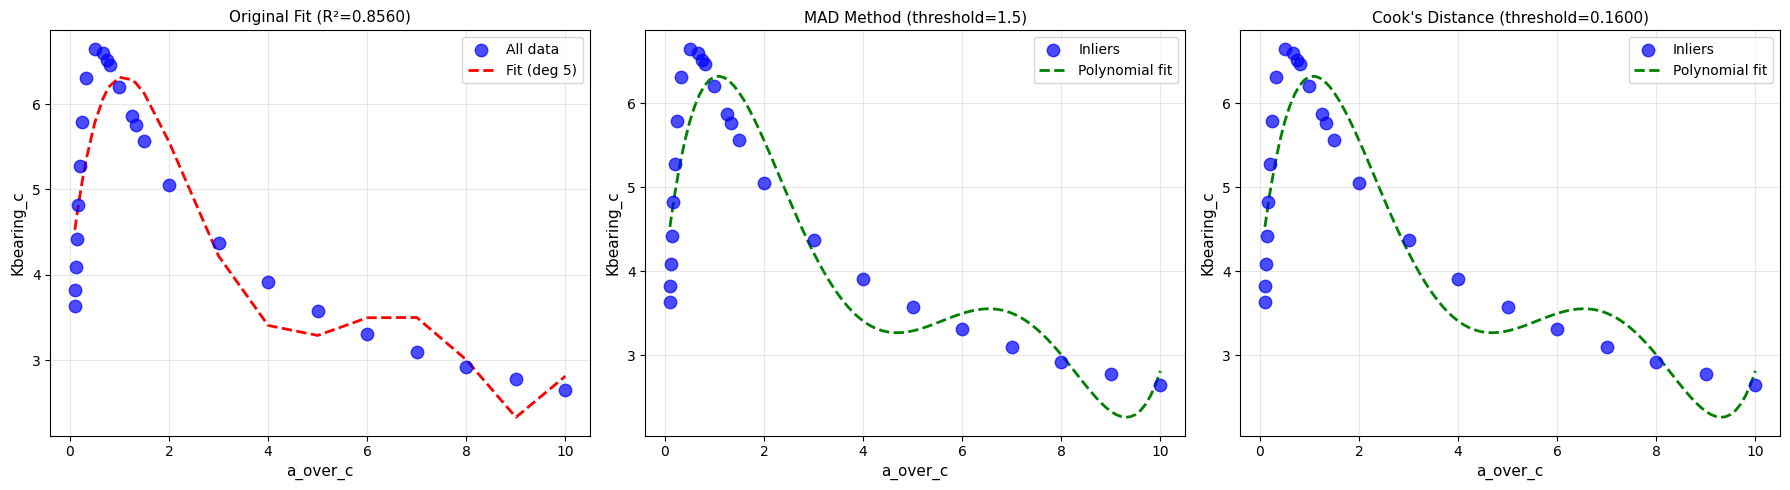


Outlier detection testing complete on 20 worst fits.


In [45]:
# Test outlier detection on the 10 worst fits from reduction_dicts
print("=== Testing Outlier Detection on 10 Worst Fits ===\n")

# Find the worst 10 fits
fit_rankings = []

for curve_idx, d in enumerate(reduction_dicts):
    if "simple_fit_results" not in d:
        continue
    
    for k_target, fit_result in d["simple_fit_results"].items():
        if fit_result['n_points'] >= 4 and fit_result['best_r2'] is not None:
            fit_rankings.append({
                'curve_idx': curve_idx,
                'k_target': k_target,
                'r2': fit_result['best_r2'],
                'rmse': fit_result['best_rmse'],
                'degree': fit_result['best_degree'],
                'is_bad': fit_result['is_bad_fit']
            })

# Sort by R² (ascending - worst first)
fit_rankings.sort(key=lambda x: x['r2'])

# Sort descending
# fit_rankings.sort(key=lambda x: x['r2'], reverse=True)

print(f"Found {len(fit_rankings)} fits to rank")
print(f"Testing outlier detection on worst 10...\n")

# Test on the worst 10
num_to_test = min(20, len(fit_rankings))

for test_idx in range(num_to_test):
    try:
        worst_fit = fit_rankings[test_idx]
        curve_idx = worst_fit['curve_idx']
        k_target = worst_fit['k_target']
        
        d = reduction_dicts[curve_idx]
        data_block = d["data"]
        fit_result = d["simple_fit_results"][k_target]
        
        # Get data
        x = np.array(data_block["free_param_data"])
        y = np.array(data_block[k_target])
        
        # Clean data
        valid_mask = np.isfinite(x) & np.isfinite(y)
        x_clean = x[valid_mask]
        y_clean = y[valid_mask]
        
        # Sort for consistency
        sort_idx = np.argsort(x_clean)
        x_sorted = x_clean[sort_idx]
        y_sorted = y_clean[sort_idx]
        
        poly_degree = fit_result['best_degree']
        
        # Run both outlier detection methods
        outlier_mad = detect_polynomial_outliers(x_sorted, y_sorted, poly_degree, method='mad', threshold=1.5)
        outlier_cooks = detect_polynomial_outliers(x_sorted, y_sorted, poly_degree, method='cooks')
        
        # Print results
        print(f"\n{'='*80}")
        print(f"WORST FIT #{test_idx+1} - Outlier Detection Results")
        print(f"{'='*80}")
        print(f"Curve Index: {curve_idx}")
        print(f"Free parameter: {d['free_param_name']}")
        
        # Print fixed parameters
        all_params = ["w_over_r", "a_over_c", "a_over_t", "R_over_t"]
        print("Fixed parameters:", end=" ")
        fixed_params = []
        for param in all_params:
            if param in d and param != d["free_param_name"]:
                fixed_params.append(f"{param}={d[param]:.3f}")
        print(", ".join(fixed_params))
        
        print(f"K-target: {k_target}")
        print(f"Polynomial degree: {poly_degree}")
        print(f"R² = {fit_result['best_r2']:.4f}")
        print(f"Number of points: {fit_result['n_points']}")
        
        print(f"\n--- MAD Method ---")
        print(f"Outliers detected: {outlier_mad['n_outliers']}")
        if outlier_mad['n_outliers'] > 0:
            print(f"Outlier indices: {outlier_mad['outlier_indices']}")
            outlier_scores = [outlier_mad['scores'][i] for i in outlier_mad['outlier_indices']]
            print(f"Modified z-scores at outliers: {[f'{score:.2f}' for score in outlier_scores]}")
        
        print(f"\n--- Cook's Distance Method ---")
        print(f"Outliers detected: {outlier_cooks['n_outliers']}")
        print(f"Threshold used (4/n): {outlier_cooks['threshold_used']:.4f}")
        if outlier_cooks['n_outliers'] > 0:
            print(f"Outlier indices: {outlier_cooks['outlier_indices']}")
            cooks_scores = [outlier_cooks['scores'][i] for i in outlier_cooks['outlier_indices']]
            print(f"Cook's D at outliers: {[f'{score:.4f}' for score in cooks_scores]}")
        
        # Create visualization
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Original fit (no outlier removal)
        ax0 = axes[0]
        ax0.scatter(x_sorted, y_sorted, c='blue', s=80, alpha=0.7, label='All data', zorder=2)
        if fit_result['y_pred'] is not None:
            ax0.plot(x_sorted, fit_result['y_pred'], 'r--', linewidth=2, 
                    label=f"Fit (deg {poly_degree})", zorder=1)
        ax0.set_xlabel(d["free_param_name"], fontsize=11)
        ax0.set_ylabel(k_target.replace('_data', ''), fontsize=11)
        ax0.set_title(f"Original Fit (R²={fit_result['best_r2']:.4f})", fontsize=11)
        ax0.legend()
        ax0.grid(True, alpha=0.3)
        
        # MAD method
        ax1 = axes[1]
        outlier_mask_mad = outlier_mad['outlier_mask']
        if outlier_mask_mad is None:
            outlier_mask_mad = np.zeros_like(x_sorted, dtype=bool)
        inlier_mask_mad = ~outlier_mask_mad
        
        ax1.scatter(x_sorted[inlier_mask_mad], y_sorted[inlier_mask_mad], 
                c='blue', s=80, alpha=0.7, label='Inliers', zorder=2)
        if outlier_mad['n_outliers'] > 0:
            ax1.scatter(x_sorted[outlier_mask_mad], y_sorted[outlier_mask_mad], 
                    c='red', s=120, marker='x', linewidths=3, 
                    label=f'Outliers (n={outlier_mad["n_outliers"]})', zorder=3)
        
        # Plot fit
        coeffs_mad = np.array(outlier_mad['coeffs'])
        x_fit = np.linspace(x_sorted.min(), x_sorted.max(), 100)
        y_fit_mad = np.polyval(coeffs_mad, x_fit)
        ax1.plot(x_fit, y_fit_mad, 'g--', linewidth=2, label='Polynomial fit', zorder=1)
        
        ax1.set_xlabel(d["free_param_name"], fontsize=11)
        ax1.set_ylabel(k_target.replace('_data', ''), fontsize=11)
        ax1.set_title(f"MAD Method (threshold={outlier_mad['threshold_used']:.1f})", fontsize=11)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Cook's Distance method
        ax2 = axes[2]
        outlier_mask_cooks = outlier_cooks['outlier_mask']
        if outlier_mask_cooks is None:
            outlier_mask_cooks = np.zeros_like(x_sorted, dtype=bool)
        inlier_mask_cooks = ~outlier_mask_cooks
        
        ax2.scatter(x_sorted[inlier_mask_cooks], y_sorted[inlier_mask_cooks], 
                c='blue', s=80, alpha=0.7, label='Inliers', zorder=2)
        if outlier_cooks['n_outliers'] > 0:
            ax2.scatter(x_sorted[outlier_mask_cooks], y_sorted[outlier_mask_cooks], 
                    c='red', s=120, marker='x', linewidths=3, 
                    label=f'Outliers (n={outlier_cooks["n_outliers"]})', zorder=3)
        
        # Plot fit
        coeffs_cooks = np.array(outlier_cooks['coeffs'])
        y_fit_cooks = np.polyval(coeffs_cooks, x_fit)
        ax2.plot(x_fit, y_fit_cooks, 'g--', linewidth=2, label='Polynomial fit', zorder=1)
        
        ax2.set_xlabel(d["free_param_name"], fontsize=11)
        ax2.set_ylabel(k_target.replace('_data', ''), fontsize=11)
        ax2.set_title(f"Cook's Distance (threshold={outlier_cooks['threshold_used']:.4f})", fontsize=11)
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    except:
        print(f"Error processing worst fit #{test_idx+1}, skipping...")
        continue
print(f"\n{'='*80}")
print(f"Outlier detection testing complete on {num_to_test} worst fits.")
print(f"{'='*80}")


=== Plotting Fits with Most Outliers ===

Found 30 fits with outliers detected
Plotting top 10 by worst R² (with outlier count as secondary)...


RANK #1 - Worst R² (Curve Set Index: 236)
Free parameter: a_over_c
Fixed parameters:
  w_over_r = 1.8000
  a_over_t = 0.1000
  R_over_t = 0.8000

K-target: Kbearing_c_data
Best polynomial degree: 5
R² = 0.8046
RMSE = 0.7299
Number of points: 18
Outliers detected (MAD): 1
Outlier z score and pct error thresholds for each outlier point:
  Index 15: z-score = -3.78, pct error = 35.27%
Outlier percentage: 5.6%
  Outlier indices: [15]


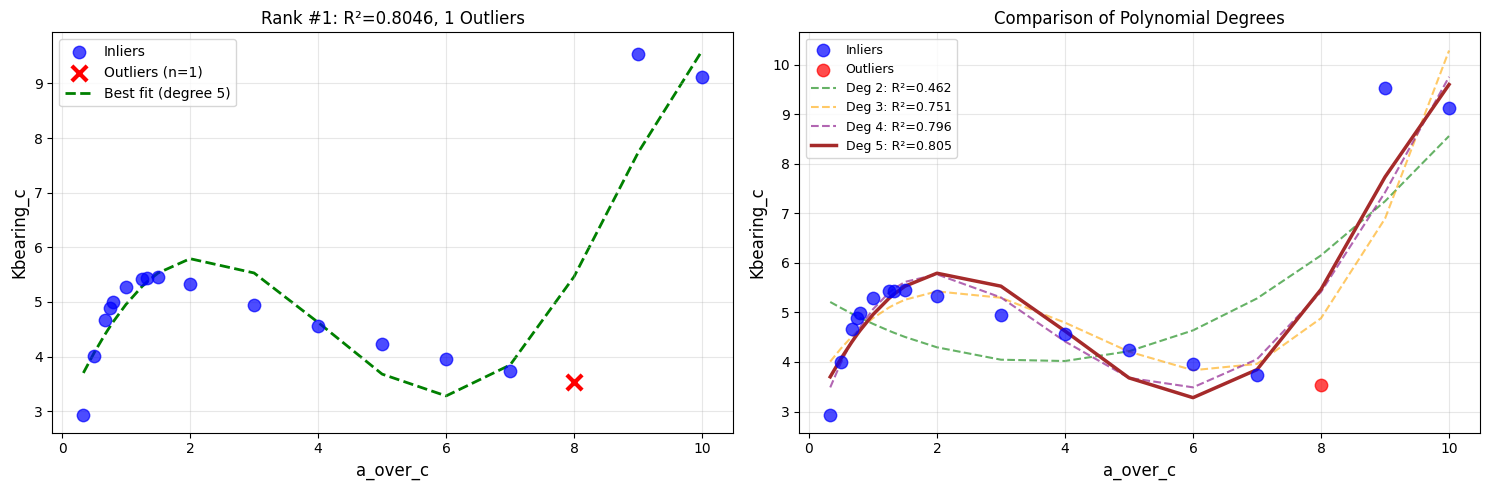


RANK #2 - Worst R² (Curve Set Index: 12)
Free parameter: a_over_c
Fixed parameters:
  w_over_r = 1.6000
  a_over_t = 0.1000
  R_over_t = 0.8000

K-target: Kbearing_c_data
Best polynomial degree: 5
R² = 0.8107
RMSE = 0.8487
Number of points: 18
Outliers detected (MAD): 1
Outlier z score and pct error thresholds for each outlier point:
  Index 15: z-score = -3.78, pct error = 35.84%
Outlier percentage: 5.6%
  Outlier indices: [15]


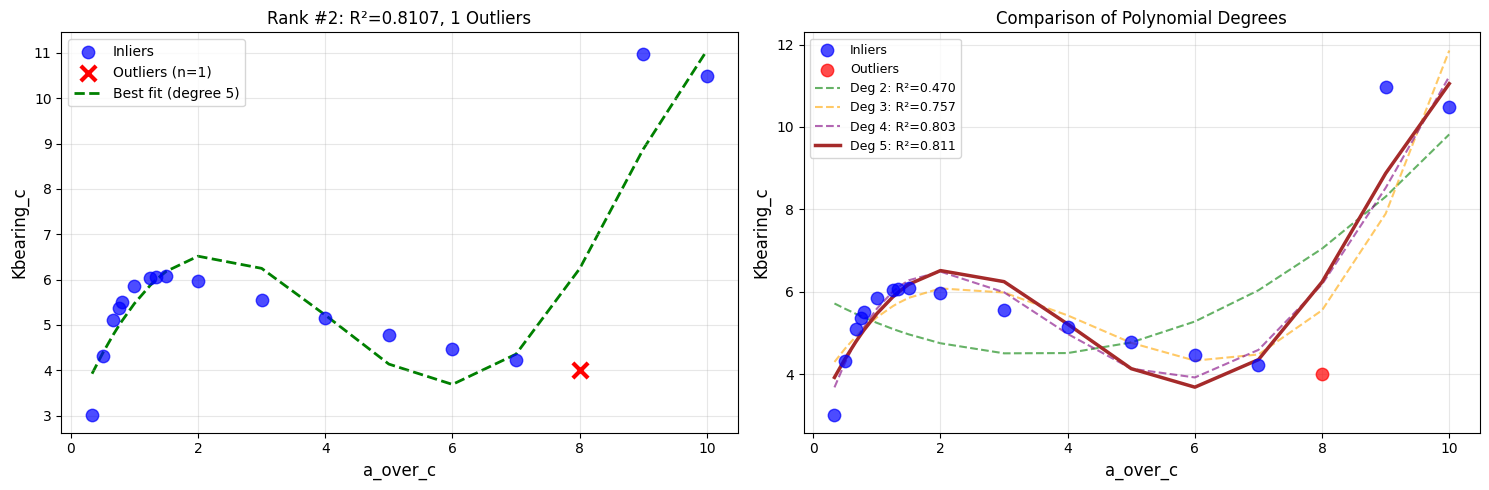


RANK #3 - Worst R² (Curve Set Index: 470)
Free parameter: a_over_c
Fixed parameters:
  w_over_r = 2.0000
  a_over_t = 0.1000
  R_over_t = 0.8000

K-target: Kbearing_c_data
Best polynomial degree: 4
R² = 0.8275
RMSE = 0.6865
Number of points: 20
Outliers detected (MAD): 2
Outlier z score and pct error thresholds for each outlier point:
  Index 17: z-score = -2.61, pct error = 35.04%
  Index 18: z-score = 2.73, pct error = 26.05%
Outlier percentage: 10.0%
  Outlier indices: [17, 18]


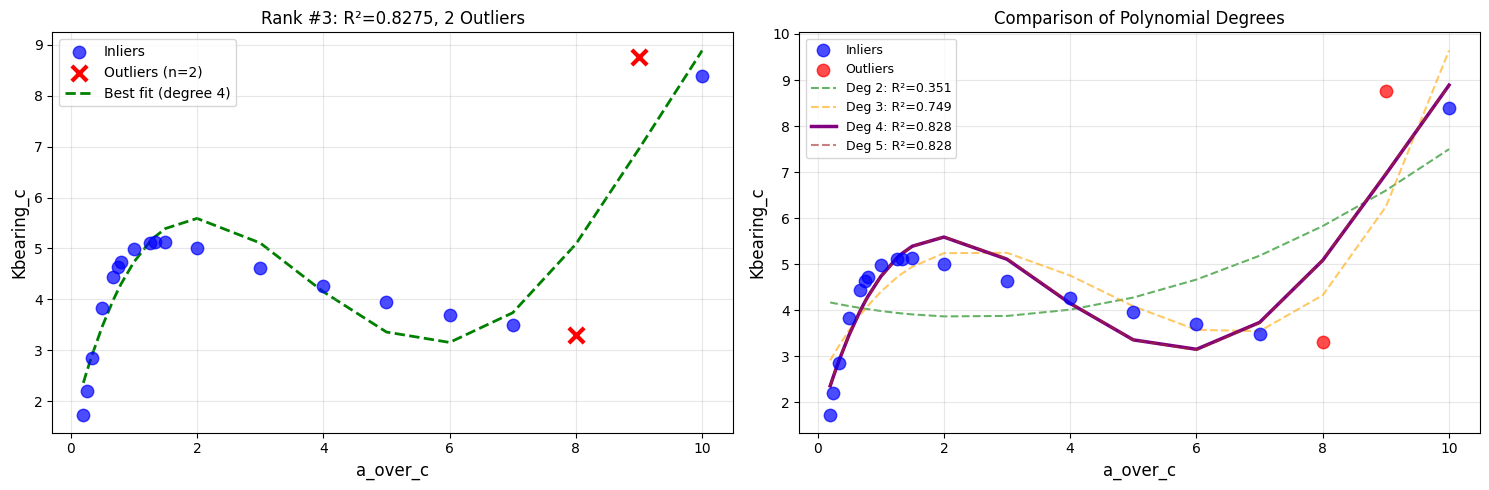


RANK #4 - Worst R² (Curve Set Index: 958)
Free parameter: a_over_c
Fixed parameters:
  w_over_r = 2.4000
  a_over_t = 0.1000
  R_over_t = 0.4444

K-target: Kbearing_c_data
Best polynomial degree: 5
R² = 0.8379
RMSE = 0.8523
Number of points: 18
Outliers detected (MAD): 1
Outlier z score and pct error thresholds for each outlier point:
  Index 15: z-score = -5.21, pct error = 37.28%
Outlier percentage: 5.6%
  Outlier indices: [15]


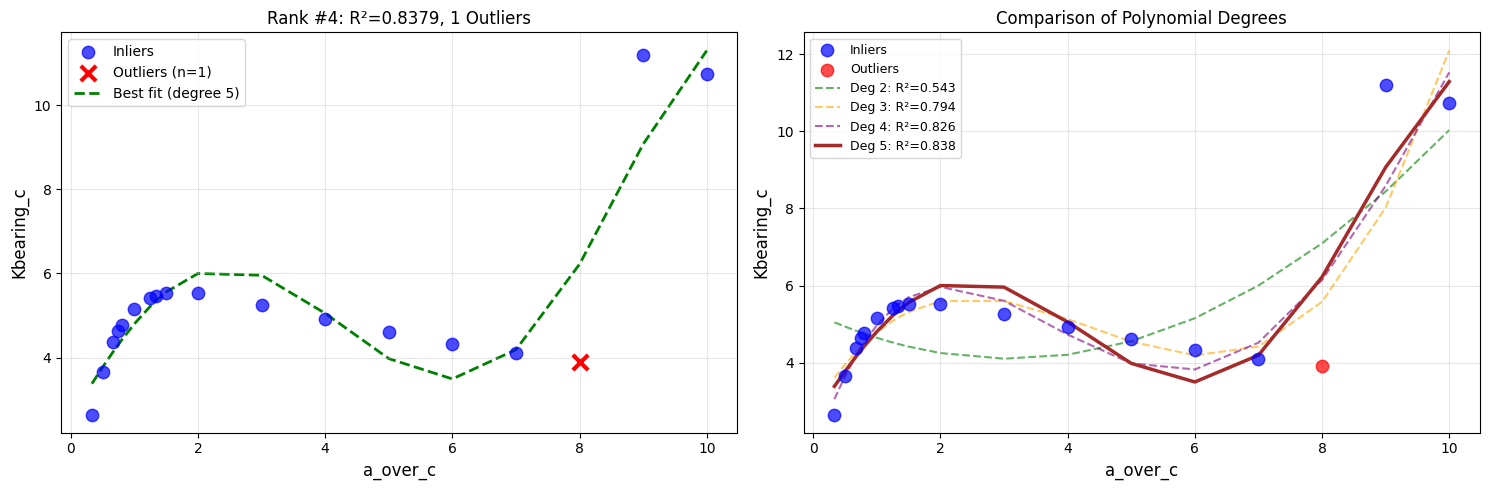


RANK #5 - Worst R² (Curve Set Index: 709)
Free parameter: a_over_c
Fixed parameters:
  w_over_r = 2.2000
  a_over_t = 0.1000
  R_over_t = 0.4444

K-target: Kbearing_c_data
Best polynomial degree: 5
R² = 0.8392
RMSE = 0.8909
Number of points: 18
Outliers detected (MAD): 1
Outlier z score and pct error thresholds for each outlier point:
  Index 15: z-score = -5.30, pct error = 37.90%
Outlier percentage: 5.6%
  Outlier indices: [15]


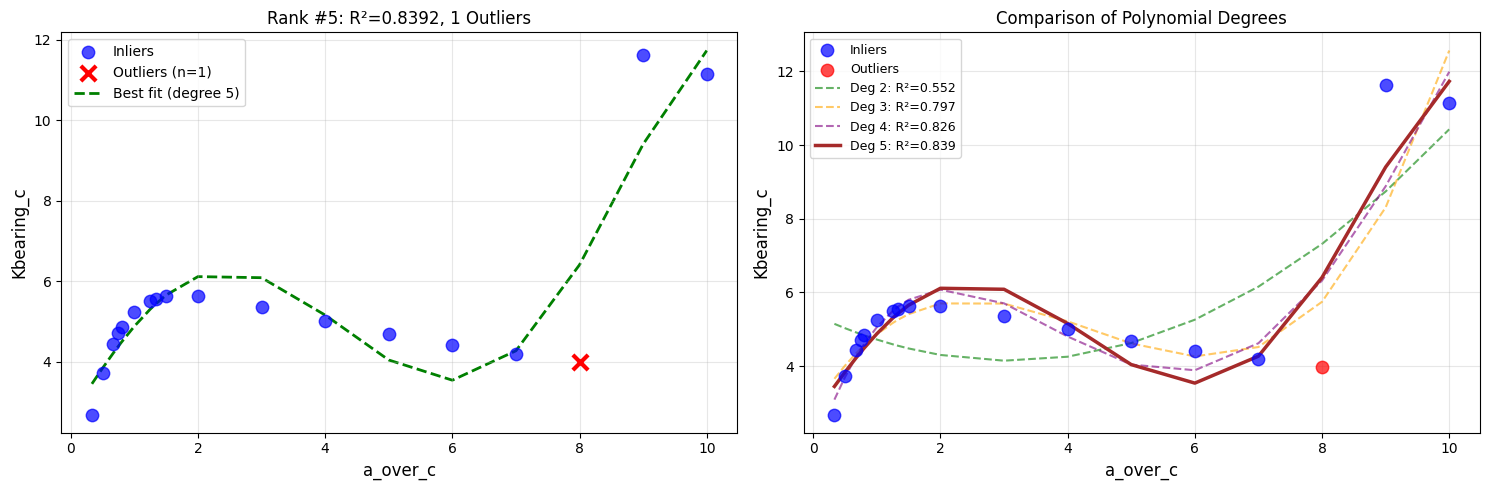


RANK #6 - Worst R² (Curve Set Index: 466)
Free parameter: a_over_c
Fixed parameters:
  w_over_r = 2.0000
  a_over_t = 0.1000
  R_over_t = 0.4444

K-target: Kbearing_c_data
Best polynomial degree: 5
R² = 0.8409
RMSE = 0.9535
Number of points: 18
Outliers detected (MAD): 1
Outlier z score and pct error thresholds for each outlier point:
  Index 15: z-score = -5.29, pct error = 38.55%
Outlier percentage: 5.6%
  Outlier indices: [15]


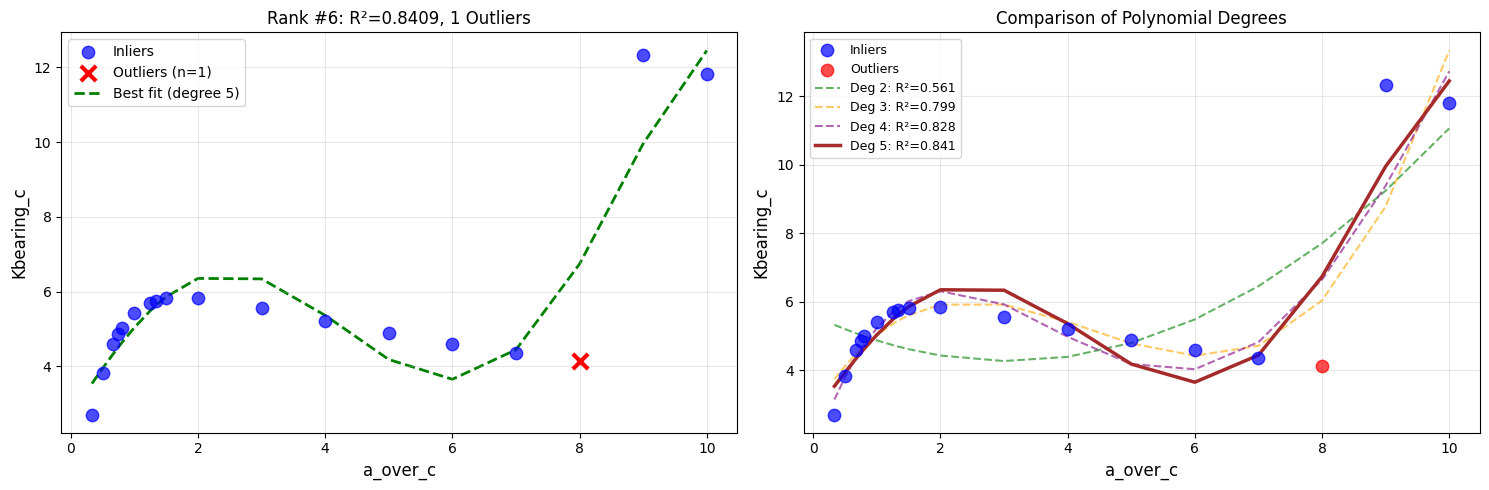


RANK #7 - Worst R² (Curve Set Index: 232)
Free parameter: a_over_c
Fixed parameters:
  w_over_r = 1.8000
  a_over_t = 0.1000
  R_over_t = 0.4444

K-target: Kbearing_c_data
Best polynomial degree: 5
R² = 0.8430
RMSE = 1.0389
Number of points: 17
Outliers detected (MAD): 1
Outlier z score and pct error thresholds for each outlier point:
  Index 14: z-score = -4.19, pct error = 38.94%
Outlier percentage: 5.9%
  Outlier indices: [14]


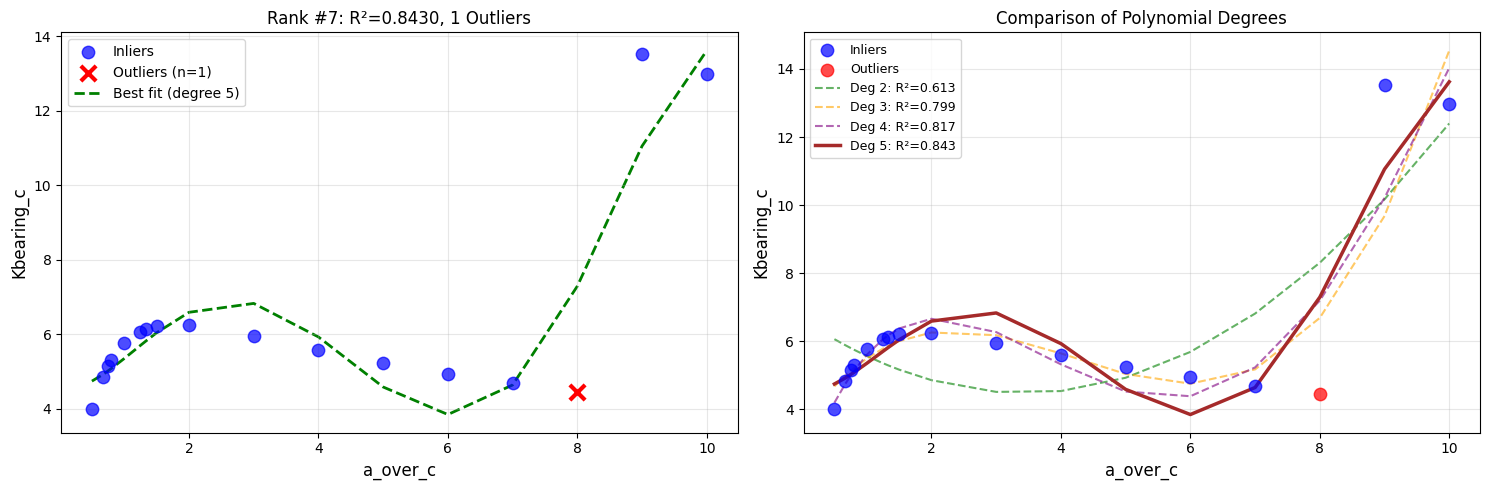


RANK #8 - Worst R² (Curve Set Index: 8)
Free parameter: a_over_c
Fixed parameters:
  w_over_r = 1.6000
  a_over_t = 0.1000
  R_over_t = 0.4444

K-target: Kbearing_c_data
Best polynomial degree: 5
R² = 0.8487
RMSE = 1.2190
Number of points: 16
Outliers detected (MAD): 1
Outlier z score and pct error thresholds for each outlier point:
  Index 13: z-score = -4.37, pct error = 39.45%
Outlier percentage: 6.2%
  Outlier indices: [13]


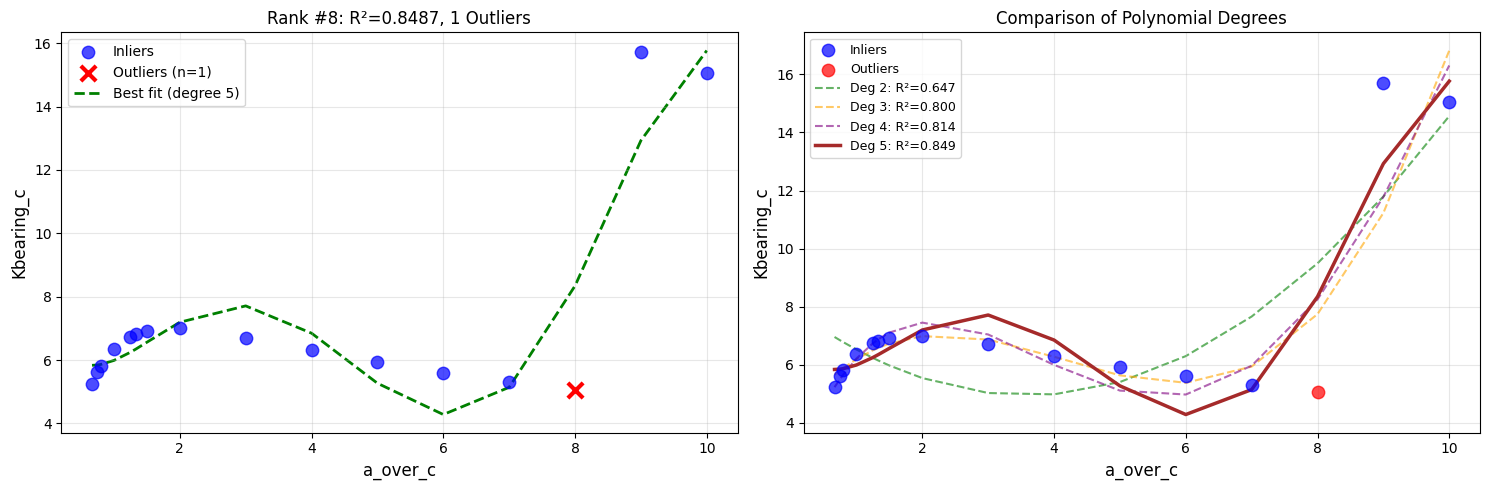


RANK #9 - Worst R² (Curve Set Index: 962)
Free parameter: a_over_c
Fixed parameters:
  w_over_r = 2.4000
  a_over_t = 0.1000
  R_over_t = 0.8000

K-target: Kbearing_c_data
Best polynomial degree: 4
R² = 0.8701
RMSE = 0.6243
Number of points: 23
Outliers detected (MAD): 1
Outlier z score and pct error thresholds for each outlier point:
  Index 20: z-score = -2.99, pct error = 34.86%
Outlier percentage: 4.3%
  Outlier indices: [20]


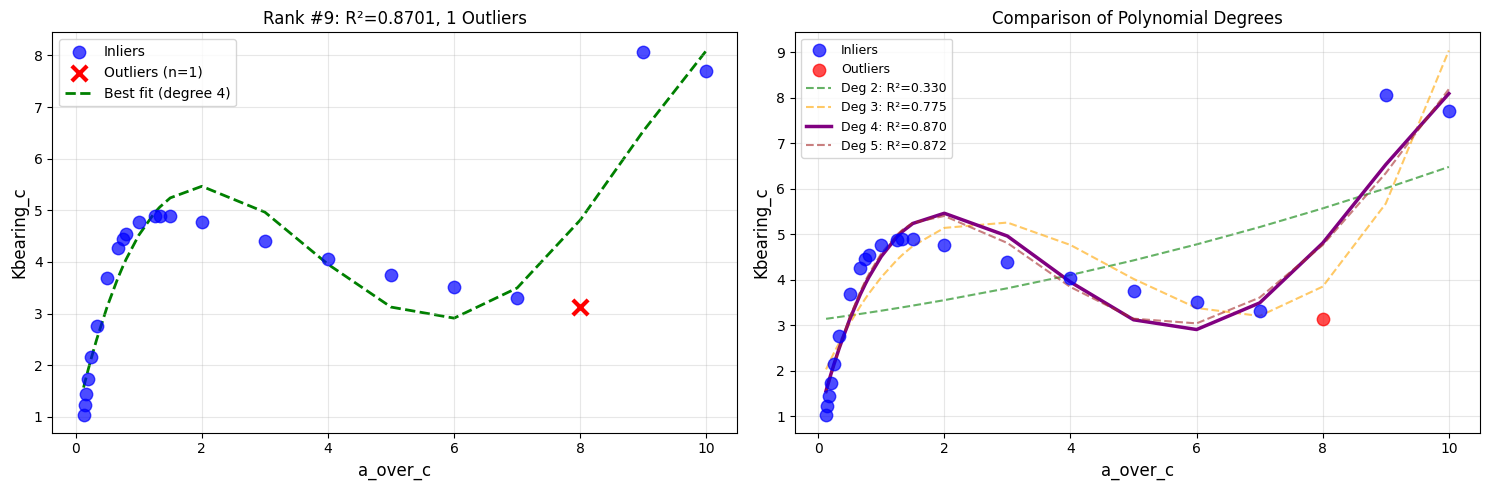


RANK #10 - Worst R² (Curve Set Index: 711)
Free parameter: a_over_c
Fixed parameters:
  w_over_r = 2.2000
  a_over_t = 0.1000
  R_over_t = 0.5714

K-target: Kbearing_c_data
Best polynomial degree: 5
R² = 0.8808
RMSE = 0.7416
Number of points: 18
Outliers detected (MAD): 1
Outlier z score and pct error thresholds for each outlier point:
  Index 14: z-score = -6.00, pct error = 33.63%
Outlier percentage: 5.6%
  Outlier indices: [14]


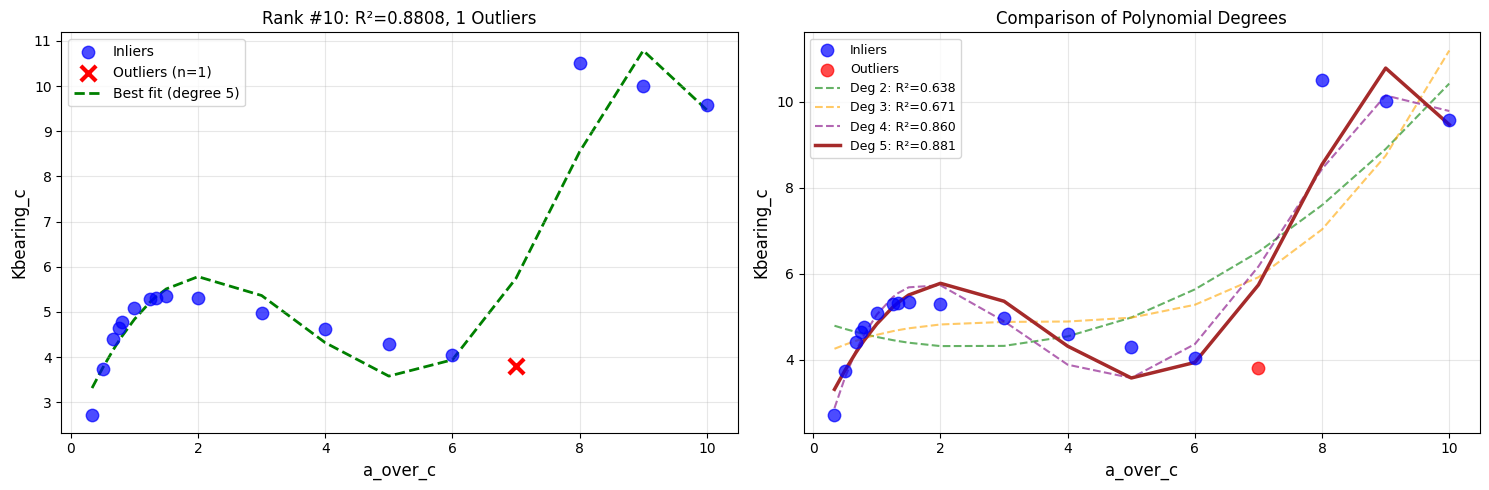


Plotted 10 fits ranked by worst R² (with outlier count as tiebreaker).


In [42]:
# Plot fits with most outliers (primary) and worst R² (secondary)
print("=== Plotting Fits with Most Outliers ===\n")

# Find all fits with outlier detection results and rank by outlier count then R²
fit_rankings_outliers = []

for curve_idx, d in enumerate(reduction_dicts):
    if "simple_fit_results" not in d:
        continue
    
    for k_target, fit_result in d["simple_fit_results"].items():
        if (fit_result['n_points'] >= 4 and 
            fit_result['best_r2'] is not None and 
            'outlier_detection' in fit_result and
            fit_result['outlier_detection']['n_outliers'] > 0):  # Only include fits with outliers
            
            fit_rankings_outliers.append({
                'curve_idx': curve_idx,
                'k_target': k_target,
                'r2': fit_result['best_r2'],
                'rmse': fit_result['best_rmse'],
                'degree': fit_result['best_degree'],
                'is_bad': fit_result['is_bad_fit'],
                'n_outliers': fit_result['outlier_detection']['n_outliers']
            })

# Sort by R² (ascending for worst first), then by number of outliers (descending)
fit_rankings_outliers.sort(key=lambda x: (x['r2'], -x['n_outliers']))

print(f"Found {len(fit_rankings_outliers)} fits with outliers detected")
print(f"Plotting top 10 by worst R² (with outlier count as secondary)...\n")

# Plot the top 10
num_to_plot = min(10, len(fit_rankings_outliers))

for plot_idx in range(num_to_plot):
    ranked_fit = fit_rankings_outliers[plot_idx]
    curve_idx = ranked_fit['curve_idx']
    k_target = ranked_fit['k_target']
    
    d = reduction_dicts[curve_idx]
    data_block = d["data"]
    fit_result = d["simple_fit_results"][k_target]
    outlier_info = fit_result['outlier_detection']
    
    # Get data
    x = np.array(data_block["free_param_data"])
    y = np.array(data_block[k_target])
    
    # Clean data
    valid_mask = np.isfinite(x) & np.isfinite(y)
    x_clean = x[valid_mask]
    y_clean = y[valid_mask]
    
    # Sort for plotting
    sort_idx = np.argsort(x_clean)
    x_sorted = x_clean[sort_idx]
    y_sorted = y_clean[sort_idx]
    
    # Print info
    print(f"\n{'='*80}")
    print(f"RANK #{plot_idx+1} - Worst R² (Curve Set Index: {curve_idx})")
    print(f"{'='*80}")
    print(f"Free parameter: {d['free_param_name']}")
    
    # Print fixed parameters
    all_params = ["w_over_r", "a_over_c", "a_over_t", "R_over_t"]
    print("Fixed parameters:")
    for param in all_params:
        if param in d and param != d["free_param_name"]:
            print(f"  {param} = {d[param]:.4f}")
    
    print(f"\nK-target: {k_target}")
    print(f"Best polynomial degree: {fit_result['best_degree']}")
    print(f"R² = {fit_result['best_r2']:.4f}")
    print(f"RMSE = {fit_result['best_rmse']:.4f}")
    print(f"Number of points: {fit_result['n_points']}")
    print(f"Outliers detected (MAD): {outlier_info['n_outliers']}")
    print(f"Outlier z score and pct error thresholds for each outlier point:")
    for outlier_idx in outlier_info['outlier_indices']:
        z_score = outlier_info['scores'][outlier_idx]
        pct_error = outlier_info['pct_errors'][outlier_idx]
        print(f"  Index {outlier_idx}: z-score = {z_score:.2f}, pct error = {pct_error:.2f}%")
    print(f"Outlier percentage: {100*outlier_info['n_outliers']/fit_result['n_points']:.1f}%")
    if outlier_info['n_outliers'] > 0:
        print(f"  Outlier indices: {outlier_info['outlier_indices']}")
    
    # Create plot
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Left plot: Data with outliers marked and best fit
    ax1 = axes[0]
    
    outlier_mask = outlier_info['outlier_mask']
    inlier_mask = ~outlier_mask
    
    # Plot inliers
    ax1.scatter(x_sorted[inlier_mask], y_sorted[inlier_mask], 
               c='blue', s=80, alpha=0.7, label='Inliers', zorder=2)
    
    # Plot outliers
    if outlier_info['n_outliers'] > 0:
        ax1.scatter(x_sorted[outlier_mask], y_sorted[outlier_mask], 
                   c='red', s=120, marker='x', linewidths=3, 
                   label=f'Outliers (n={outlier_info["n_outliers"]})', zorder=3)
    
    if fit_result['y_pred'] is not None:
        ax1.plot(x_sorted, fit_result['y_pred'], 'g--', linewidth=2, 
                label=f"Best fit (degree {fit_result['best_degree']})", zorder=1)
    
    ax1.set_xlabel(d["free_param_name"], fontsize=12)
    ax1.set_ylabel(k_target.replace('_data', ''), fontsize=12)
    ax1.set_title(f"Rank #{plot_idx+1}: R²={fit_result['best_r2']:.4f}, {outlier_info['n_outliers']} Outliers", fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Right plot: All polynomial fits compared
    ax2 = axes[1]
    
    # Plot all data points (outliers in red)
    ax2.scatter(x_sorted[inlier_mask], y_sorted[inlier_mask], 
               c='blue', s=80, alpha=0.7, label='Inliers', zorder=5)
    if outlier_info['n_outliers'] > 0:
        ax2.scatter(x_sorted[outlier_mask], y_sorted[outlier_mask], 
                   c='red', s=80, alpha=0.7, label='Outliers', zorder=5)
    
    colors = ['green', 'orange', 'purple', 'brown']
    for idx, (degree, fit_info) in enumerate(sorted(fit_result['all_fits'].items())):
        if 'error' not in fit_info:
            # Compute predictions for this degree
            coeffs = np.array(fit_info['coeffs'])
            y_pred_deg = np.polyval(coeffs, x_sorted)
            
            is_best = (degree == fit_result['best_degree'])
            linestyle = '-' if is_best else '--'
            linewidth = 2.5 if is_best else 1.5
            alpha = 1.0 if is_best else 0.6
            
            ax2.plot(x_sorted, y_pred_deg, linestyle, 
                    color=colors[idx % len(colors)], linewidth=linewidth, alpha=alpha,
                    label=f"Deg {degree}: R²={fit_info['r2']:.3f}", zorder=idx+1)
    
    ax2.set_xlabel(d["free_param_name"], fontsize=12)
    ax2.set_ylabel(k_target.replace('_data', ''), fontsize=12)
    ax2.set_title(f"Comparison of Polynomial Degrees", fontsize=12)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print(f"\n{'='*80}")
print(f"Plotted {num_to_plot} fits ranked by worst R² (with outlier count as tiebreaker).")
print(f"{'='*80}")


In [34]:
all_params_all_Ks = np.load('all_params_all_Ks.npy')
# Add an index column for easier reference
print(all_params_all_Ks.shape)
all_params_all_Ks_with_reference = np.column_stack([all_params_all_Ks, np.arange(len(all_params_all_Ks))])
print(all_params_all_Ks_with_reference.shape)
# Find all the unique values for each parameter
unique_w_over_r = np.unique(all_params_all_Ks_with_reference[:, w_over_r_idx])
unique_a_over_c = np.unique(all_params_all_Ks_with_reference[:, a_over_c_idx])
unique_a_over_t = np.unique(all_params_all_Ks_with_reference[:, a_over_t_idx])
unique_R_over_t = np.unique(all_params_all_Ks_with_reference[:, R_over_t_idx])
# unique_c = np.unique(all_params_all_Ks_with_reference[:, c_idx])

print("Unique w/r values:", unique_w_over_r)
print("Unique a/c values:", unique_a_over_c)
print("Unique a/t values:", unique_a_over_t)
print("Unique R/t values:", unique_R_over_t)
# print("Unique c values:", unique_c)
feature_names = ['w_over_r', 'a_over_c', 'a_over_t', 'R_over_t']
feature_indices = [w_over_r_idx, a_over_c_idx, a_over_t_idx, R_over_t_idx]
feature_unique_values = [unique_w_over_r, unique_a_over_c, unique_a_over_t, unique_R_over_t]

# Example: Filter data for specific R/t value
fixed_w_over_r = 8.0 # 8.0  #15.0
fixed_a_over_c = 0.5  #0.1
fixed_a_over_t = 0.1
fixed_R_over_t = 0.125
fixed_all = [fixed_w_over_r, fixed_a_over_c, fixed_a_over_t, fixed_R_over_t]

mask_w_over_r = np.isclose(fixed_param_mapping[:, 0], fixed_w_over_r)
mask_a_over_c = np.isclose(fixed_param_mapping[:, 1], fixed_a_over_c)
mask_a_over_t = np.isclose(fixed_param_mapping[:, 2], fixed_a_over_t)
mask_R_over_t = np.isclose(fixed_param_mapping[:, 3], fixed_R_over_t)
mask_list = [mask_w_over_r, mask_a_over_c, mask_a_over_t, mask_R_over_t]

fixed_reduction_dicts = []
for i in range(len(feature_names)): 
    masks_to_combine = [mask_list[j] for j in range(len(feature_names)) if j != i]

    # Find the entry in fixed_param_mapping with these values:
    combined_mask = np.logical_and.reduce(masks_to_combine)
    match = fixed_param_mapping[combined_mask]
    if match.shape[0] != 1:
        print("ERROR")
        continue
    
    match_idx = int(match[0,-1])
    print(match_idx)
    fixed_reduction_dicts.append(reduction_dicts[match_idx])

# Plot the worst 10 fits based on R² score
print("=== Plotting Worst 10 Fits ===\n")
# Find all fits and rank by R²
fit_rankings = []

for curve_idx, d in enumerate(fixed_reduction_dicts):
    print(curve_idx)
    print(d)
    if "simple_fit_results" not in d:
        continue
    
    for k_target, fit_result in d["simple_fit_results"].items():
        if fit_result['n_points'] >= 4 and fit_result['best_r2'] is not None:
            fit_rankings.append({
                'curve_idx': curve_idx,
                'k_target': k_target,
                'r2': fit_result['best_r2'],
                'rmse': fit_result['best_rmse'],
                'degree': fit_result['best_degree'],
                'is_bad': fit_result['is_bad_fit']
            })

# Sort by R² (ascending - worst first)
fit_rankings.sort(key=lambda x: x['r2'])

print(f"Found {len(fit_rankings)} fits to rank")
print(f"Plotting worst 10...\n")

# Plot the worst 10
num_to_plot = min(10, len(fit_rankings))

for plot_idx in range(num_to_plot):
    worst_fit = fit_rankings[plot_idx]
    curve_idx = worst_fit['curve_idx']
    k_target = worst_fit['k_target']
    
    d = fixed_reduction_dicts[curve_idx]
    data_block = d["data"]
    fit_result = d["simple_fit_results"][k_target]
    
    # Get data
    x = np.array(data_block["free_param_data"])
    y = np.array(data_block[k_target])
    
    # Clean data
    valid_mask = np.isfinite(x) & np.isfinite(y)
    x_clean = x[valid_mask]
    y_clean = y[valid_mask]
    
    # Sort for plotting
    sort_idx = np.argsort(x_clean)
    x_sorted = x_clean[sort_idx]
    y_sorted = y_clean[sort_idx]
    
    # Print info
    print(f"\n{'='*80}")
    print(f"WORST FIT #{plot_idx+1} (Curve Set Index: {curve_idx})")
    print(f"{'='*80}")
    print(f"Free parameter: {d['free_param_name']}")
    
    # Print fixed parameters
    all_params = ["w_over_r", "a_over_c", "a_over_t", "R_over_t"]
    print("Fixed parameters:")
    for param in all_params:
        if param in d and param != d["free_param_name"]:
            print(f"  {param} = {d[param]:.4f}")
    
    print(f"\nK-target: {k_target}")
    print(f"Best polynomial degree: {fit_result['best_degree']}")
    print(f"R² = {fit_result['best_r2']:.4f}")
    print(f"RMSE = {fit_result['best_rmse']:.4f}")
    print(f"Number of points: {fit_result['n_points']}")
    print(f"Bad fit: {fit_result['is_bad_fit']}")
    
    # Create plot
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Left plot: Data and best fit
    ax1 = axes[0]
    ax1.scatter(x_sorted, y_sorted, c='blue', s=80, alpha=0.7, label='Data points', zorder=2)
    
    if fit_result['y_pred'] is not None:
        ax1.plot(x_sorted, fit_result['y_pred'], 'r--', linewidth=2, 
                label=f"Best fit (degree {fit_result['best_degree']})", zorder=1)
    
    ax1.set_xlabel(d["free_param_name"], fontsize=12)
    ax1.set_ylabel(k_target.replace('_data', ''), fontsize=12)
    ax1.set_title(f"Worst Fit #{plot_idx+1}: R² = {fit_result['best_r2']:.4f}", fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Right plot: All polynomial fits compared
    ax2 = axes[1]
    ax2.scatter(x_sorted, y_sorted, c='blue', s=80, alpha=0.7, label='Data points', zorder=5)
    
    colors = ['red', 'green', 'orange', 'purple']
    for idx, (degree, fit_info) in enumerate(sorted(fit_result['all_fits'].items())):
        if 'error' not in fit_info:
            # Compute predictions for this degree
            coeffs = np.array(fit_info['coeffs'])
            y_pred_deg = np.polyval(coeffs, x_sorted)
            
            is_best = (degree == fit_result['best_degree'])
            linestyle = '-' if is_best else '--'
            linewidth = 2.5 if is_best else 1.5
            alpha = 1.0 if is_best else 0.6
            
            ax2.plot(x_sorted, y_pred_deg, linestyle, 
                    color=colors[idx % len(colors)], linewidth=linewidth, alpha=alpha,
                    label=f"Deg {degree}: R²={fit_info['r2']:.3f}", zorder=idx+1)
    
    ax2.set_xlabel(d["free_param_name"], fontsize=12)
    ax2.set_ylabel(k_target.replace('_data', ''), fontsize=12)
    ax2.set_title(f"Comparison of Polynomial Degrees", fontsize=12)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print(f"\n{'='*80}")
print(f"Plotted {num_to_plot} worst fits.")
print(f"{'='*80}")

(92149, 17)
(92149, 18)
Unique w/r values: [   1.60000002    1.79999995    2.            2.20000005    2.4000001
    2.79999995    3.20000005    3.5999999     4.            4.5999999
    5.19999981    5.80000019    6.4000001     7.            8.
   10.           12.           12.5          14.30000019   15.
   16.70000076   20.           25.           33.29999924   40.
   44.40000153   50.           57.09999847   66.69999695   80.
  100.          125.          149.8999939   175.          200.
  225.          250.          300.29998779  400.          500.
  599.90002441  700.29998779  800.         1000.        ]
Unique a/c values: [ 0.1         0.111       0.125       0.1428      0.16670001  0.2
  0.25        0.333       0.5         0.667       0.75        0.80000001
  1.          1.25        1.33299994  1.5         2.          3.
  4.          5.          6.          7.          8.          9.
 10.        ]
Unique a/t values: [0.1        0.2        0.30000001 0.40000001 0.5        0.60

IndexError: list index out of range